# Импорты

In [38]:
from typing import Callable, Optional, Tuple, List, Type, Union, Dict, Any
import numpy as np
import sys
import math
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from dataclasses import dataclass, field
import os
from tqdm.auto import tqdm
import joblib
import warnings

sys.path.append(r"D:\git\MIPT\tools")

import linear_system_solvers as lss
import unlinear_system_solvers as uss
import derrivates as derr
import plot_tools as pt

# Базовый класс

In [39]:
class BaseOdeSolver:
    """
    Base abstract class for Ordinary Differential Equation (ODE) solvers.

    Manages the integration loop, step size adjustments, and history tracking 
    for the Cauchy problem: y' = f(t, y), y(t₀) = y₀.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system. Takes time `t` and state `y`, returns dy/dt.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Jacobian matrix of the right-hand side, J = df/dy. Required for implicit methods.

    Notes
    -----
    • *Algorithm workflow*
    - The class handles the global while-loop in `integrate()`.
    - Specific numerical methods (Runge-Kutta, Adams, etc.) must inherit from this 
      class and implement the `step()` method to update `self.t` and `self.y_vec`.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        self.fun = fun
        self.jac = jac
        
        self.t = t0
        # Convert initial state to double precision array
        self.y_vec = np.asarray(y0_vec, dtype=np.float64).copy()  # shape: (N,)
        self.h = h
        self.t_bound = t_bound
        
        # --- Step 1: Initialize history ---
        # Lists to accumulate integration trajectory
        self.t_arr: List[float] = [self.t]
        self.y_arr: List[np.ndarray] = [self.y_vec.copy()]

    def step(self) -> None:
        """
        Performs a single numerical integration step.

        Raises
        ------
        - NotImplementedError
            Must be implemented by child classes.

        Notes
        -----
        • *Working hypotheses*
        - This method is responsible for evaluating the new state and strictly 
          updating `self.t` and `self.y_vec` attributes.
        """
        raise NotImplementedError("Subclasses must implement the 'step' method.")

    def integrate(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Executes the main integration loop until the time boundary is reached.

        Returns
        -------
        - t_arr : (K,) ndarray
            Array of computed time points, where K is the number of steps.
        - y_arr : (K, N) ndarray
            Array of computed state vectors corresponding to t_arr.
        """
        # --- Step 1: Main Integration Loop ---
        while self.t < self.t_bound - 1e-12:
            
            # --- Step 1a: Step Size Adjustment ---
            # Truncate step size to prevent overshooting the right boundary
            if self.t + self.h > self.t_bound + 1e-14:
                self.h = self.t_bound - self.t
                
            # --- Step 1b: Method Execution ---
            # Call specific solver implementation to advance time and state
            self.step()
            
            if not np.all(np.isfinite(self.y_vec)):
                warnings.warn(f"Integrate: NaN or Inf", RuntimeWarning)
                self.t_arr.append(self.t)
                self.y_arr.append(self.y_vec.copy())
                break
            
            # --- Step 1c: Record Trajectory ---
            self.t_arr.append(self.t)
            self.y_arr.append(self.y_vec.copy())  # shape: (N,)
                
        # --- Step 2: Finalize Output ---
        # Convert lists to numpy arrays for consistency
        return np.array(self.t_arr), np.array(self.y_arr)  # shapes: (K,), (K, N)

# Методы Рунге-Кутты

Рассмотрим методы Рунге-Кутты (НРК) для численного решения задачи Коши для обыкновенных дифференциальных уравнений (ОДУ) вида:

$$y' = f(t, y), \quad y(t_0) = y_0$$
---

### 1. Определение и таблица Бутчера

В общем виде одношаговый $s$-стадийный метод Рунге-Кутты задается следующим образом:

1.  Вычисляются промежуточные векторы (стадии) $k_i$:
    $$k_i = f\left(t_n + c_i h, \ y_n + h \sum_{j=1}^s a_{ij} k_j\right), \quad i = 1, \dots, s$$
2.  Вычисляется шаг интегрирования:
    $$y_{n+1} = y_n + h \sum_{i=1}^s b_i k_i$$

Где $h$ — шаг интегрирования, $c_i$ — узлы, $b_i$ — веса, а $a_{ij}$ — элементы матрицы $A$. Данные коэффициенты принято записывать в виде таблицы Бутчера:

$$
\begin{array}{c|c}
c & A \\
\hline
  & b^T
\end{array}
=
\begin{array}{c|ccc}
c_1 & a_{11} & \dots & a_{1s} \\
\vdots & \vdots & \ddots & \vdots \\
c_s & a_{s1} & \dots & a_{ss} \\
\hline
    & b_1 & \dots & b_s
\end{array}
$$

Если матрица $A$ **не** является строго нижнетреугольной (то есть существует хотя бы один элемент $a_{ij} \neq 0$ при $j \ge i$), метод является **неявным**. Для вычисления вектора стадий $K = (k_1, \dots, k_s)^T$ на каждом шаге требуется решать систему из $s \times \dim(y)$ алгебраических (как правило, нелинейных) уравнений, обычно с использованием модифицированного метода Ньютона.

---

### 2. Построение неявных методов (Коллокационный подход)

Произвольные неявные методы чаще всего строятся как методы коллокации. Идея заключается в поиске полинома $u(t)$ степени $s$, который удовлетворяет ОДУ в заданных узлах коллокации.

1.  Зафиксируем $s$ различных узлов $c_1, \dots, c_s \in [0, 1]$.
2.  Требуем, чтобы полином $u(t)$ проходил через начальную точку: $u(t_n) = y_n$.
3.  Требуем, чтобы производная полинома совпадала с полем направлений в узлах (условия коллокации):
    $$u'(t_n + c_i h) = f(t_n + c_i h, u(t_n + c_i h)), \quad i = 1, \dots, s$$

Решением задачи на шаг будет значение полинома в конце интервала: $y_{n+1} = u(t_n + h)$.

Чтобы перевести это в коэффициенты Бутчера, выразим производную $u'(t)$ через базисные полиномы Лагранжа $\ell_j(\tau) = \prod_{m \neq j} \frac{\tau - c_m}{c_j - c_m}$:
$$u'(t_n + \tau h) = \sum_{j=1}^s k_j \ell_j(\tau), \quad \tau \in [0, 1]$$
где $k_j = u'(t_n + c_j h)$.

Интегрируя это выражение, получаем:
$$u(t_n + c_i h) = y_n + h \int_0^{c_i} \sum_{j=1}^s k_j \ell_j(\tau) d\tau = y_n + h \sum_{j=1}^s \left( \int_0^{c_i} \ell_j(\tau) d\tau \right) k_j$$

Отсюда строго выводятся элементы матрицы $A$ и веса $b_i$:
$$a_{ij} = \int_0^{c_i} \ell_j(\tau) d\tau, \quad b_j = \int_0^1 \ell_j(\tau) d\tau$$
Узлы $c_i$ выбираются для максимизации порядка метода (например, корни полиномов Лежандра дают методы Гаусса, полиномов Радо — методы Radau).

---

### 3. Условия сходимости

Метод сходится, если глобальная погрешность $e_n = y_n - y(t_n)$ стремится к нулю при $h \to 0$. По теореме Лакса-Рихтмайера (в контексте ОДУ), для сходимости одношагового метода достаточно его **аппроксимации (согласованности)** и **нуль-устойчивости**. Поскольку все одношаговые методы по определению нуль-устойчивы (отсутствуют паразитные корни характеристического уравнения, так как метод опирается только на одну предыдущую точку), сходимость эквивалентна требованию аппроксимации.

Метод имеет порядок $p$, если локальная погрешность усечения удовлетворяет условию:
$$y(t_{n+1}) - y_{n+1} = \mathcal{O}(h^{p+1})$$

Условия порядка выводятся путем разложения точного решения и численного приближения в ряды Тейлора. Базовые условия на коэффициенты:

* **1-й порядок (согласованность):** $\sum_{i=1}^s b_i = 1$
* **2-й порядок:** $\sum_{i=1}^s b_i c_i = \frac{1}{2}$
* **3-й порядок:** $\sum_{i=1}^s b_i c_i^2 = \frac{1}{3}$ и $\sum_{i,j=1}^s b_i a_{ij} c_j = \frac{1}{6}$

Также обычно накладывается базовое упрощающее условие на узлы: $c_i = \sum_{j=1}^s a_{ij}$.

---

### 4. Анализ устойчивости по Далквисту



Для анализа устойчивости методов при решении жестких систем (stiff ODEs) Далквист предложил использовать линейное скалярное тестовое уравнение:
$$y' = \lambda y, \quad \text{Re}(\lambda) < 0, \quad \lambda \in \mathbb{C}$$

Применим неявный метод Рунге-Кутты к этому уравнению:
$$k_i = \lambda \left( y_n + h \sum_{j=1}^s a_{ij} k_j \right)$$

Введем вектор $K = (k_1, \dots, k_s)^T$, вектор единиц $\mathbb{1} = (1, \dots, 1)^T$ и комплексный параметр $z = \lambda h$. Система в матричном виде:
$$K = \lambda y_n \mathbb{1} + z A K \implies (I - zA)K = \lambda y_n \mathbb{1}$$

Решая относительно $K$, получаем $K = \lambda y_n (I - zA)^{-1} \mathbb{1}$.
Подставим это в формулу шага:
$$y_{n+1} = y_n + h b^T K = y_n + z b^T (I - zA)^{-1} \mathbb{1} y_n$$

Таким образом, переход на следующий шаг описывается линейным оператором:
$$y_{n+1} = R(z) y_n$$
где $R(z)$ — **функция устойчивости** метода:
$$R(z) = 1 + z b^T (I - zA)^{-1} \mathbb{1}$$

По правилу Крамера эту функцию можно элегантно переписать в виде отношения детерминантов:
$$R(z) = \frac{\det(I - zA + z\mathbb{1}b^T)}{\det(I - zA)}$$
Для явных методов $R(z)$ — это всегда полином. Но для неявных методов с произвольной матрицей $A$ функция $R(z)$ представляет собой рациональную функцию.

**Область абсолютной устойчивости** $\mathcal{D}$ определяется как множество значений $z$, при которых численное решение не нарастает:
$$\mathcal{D} = \{ z \in \mathbb{C} \mid |R(z)| \le 1 \}$$

---

### 5. Определения жесткой устойчивости (A, A($\alpha$), L)

Для эффективного интегрирования жестких систем метод должен обладать "хорошей" областью $\mathcal{D}$. Далквист ввел следующие строгие классификации:

#### A-устойчивость (A-stability)
Метод называется A-устойчивым, если его область абсолютной устойчивости включает в себя всю левую комплексную полуплоскость:
$$\mathbb{C}^- = \{ z \in \mathbb{C} \mid \text{Re}(z) \le 0 \} \subseteq \mathcal{D}$$
Это означает, что метод никогда не даст расходящегося решения для устойчивого по Ляпунову линейного уравнения при любом (даже сколь угодно большом) шаге $h$. Ни один явный метод Рунге-Кутты не может быть A-устойчивым.

#### A($\alpha$)-устойчивость
Свойство A-устойчивости является крайне строгим ограничением (например, максимальный порядок A-устойчивых линейных многошаговых методов равен 2, хотя для НРК такого ограничения нет). Поэтому вводится ослабленное понятие.
Метод называется A($\alpha$)-устойчивым для угла $\alpha \in (0, \pi/2)$, если $\mathcal{D}$ содержит сектор в левой полуплоскости:
$$S_\alpha = \{ z \in \mathbb{C} \mid |\arg(-z)| \le \alpha, z \neq 0 \} \subseteq \mathcal{D}$$

#### L-устойчивость (L-stability)
Метод называется L-устойчивым (или сильно A-устойчивым), если он:
1.  Является A-устойчивым.
2.  Выполняется предельное условие: $\lim_{z \to \infty} |R(z)| = 0$.

Математический смысл L-устойчивости в том, что бесконечно жесткие компоненты (соответствующие $\text{Re}(\lambda) \to -\infty$) затухают за один шаг интегрирования. Если метод A-устойчив, но не L-устойчив (например, неявный метод трапеций, где $\lim_{z \to \infty} R(z) = -1$), высокочастотные транзитные компоненты жесткой системы будут вызывать нефизичные неразрушающиеся осцилляции численного решения. Алгебраически, для выполнения L-устойчивости НРК достаточно, чтобы последняя строка матрицы $A$ совпадала с вектором весов $b^T$ ($a_{sj} = b_j$).

In [40]:
class ExplicitRungeKutta(BaseOdeSolver):
    """
    Explicit Runge-Kutta (ERK) method solver for Ordinary Differential Equations.

    Solves the Cauchy problem y' = f(t, y) using a prescribed Butcher tableau.
    Being an explicit method, it calculates stage derivatives sequentially 
    without solving nonlinear algebraic equations.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - a_mat : (s, s) array_like
        Strictly lower triangular matrix A from the Butcher tableau.
    - b_vec : (s,) array_like
        Vector of weights b from the Butcher tableau.
    - c_vec : (s,) array_like
        Vector of nodes c from the Butcher tableau.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Jacobian matrix (not used in explicit methods, kept for compatibility).

    Notes
    -----
    • *Mathematical foundation*
    - Stage derivatives: kᵢ = f(tₙ + cᵢh, yₙ + h * ∑(j=0 to i-1) aᵢⱼ kⱼ), for i = 0..s-1.
    - Step update: yₙ₊₁ = yₙ + h * ∑(i=0 to s-1) bᵢ kᵢ.

    • *Algorithm workflow*
    1. Initialize the k_mat matrix to store derivatives for each stage.
    2. Sequentially evaluate each stage kᵢ using previously computed stages.
    3. Perform a weighted sum of kᵢ to find the new state yₙ₊₁.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        a_mat: np.ndarray, 
        b_vec: np.ndarray, 
        c_vec: np.ndarray, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, jac=jac)
        
        # --- Step 1: Initialize Butcher tableau components ---
        self.a_mat = np.asarray(a_mat, dtype=np.float64)  # shape: (s, s)
        self.b_vec = np.asarray(b_vec, dtype=np.float64)  # shape: (s,)
        self.c_vec = np.asarray(c_vec, dtype=np.float64)  # shape: (s,)
        
        self.num_stages: int = len(b_vec)  # shape: scalar

    def step(self) -> None:
        """
        Executes a single step of the explicit Runge-Kutta method.
        """
        n_dim: int = self.y_vec.size
        s: int = self.num_stages
        
        # Matrix to store evaluated stage vectors kᵢ
        k_mat = np.zeros((s, n_dim), dtype=np.float64)  # shape: (s, N)
        
        # --- Step 1: Sequential Stage Evaluation ---
        # Matrix A is strictly lower triangular (aᵢⱼ = 0 for j ≥ i)
        for i in range(s):
            # tᵢ = tₙ + cᵢ * h
            t_i = self.t + self.c_vec[i] * self.h  # shape: scalar
            
            if i == 0:
                # First stage derivative is always evaluated at the current state
                y_i_vec = self.y_vec  # shape: (N,)
            else:
                # yᵢ = yₙ + h * ∑ aᵢⱼ kⱼ (for j from 0 to i-1)
                # Vectorized dot product for accumulated stage contributions
                y_i_vec = self.y_vec + self.h * (self.a_mat[i, :i] @ k_mat[:i])  # shape: (N,)
                
            # Compute stage derivative kᵢ = f(tᵢ, yᵢ)
            k_mat[i] = self.fun(t_i, y_i_vec)  # shape: (N,)
            
        # --- Step 2: Final State Update ---
        # yₙ₊₁ = yₙ + h * ∑ bᵢ kᵢ
        # Weighted combination of all computed stage derivatives
        self.y_vec += self.h * (self.b_vec @ k_mat)  # shape: (N,)
        self.t += self.h  # shape: scalar

# Неявный метод Рунге-Кутты в общем виде

Вектор стадий $k_i$ в неявном методе задается неявно:
$$k_i = f\left(t_n + c_i h, \ y_n + h \sum_{j=1}^s a_{ij} k_j\right), \quad i = 1, \dots, s$$

Чтобы найти векторы $k_i$, мы формулируем задачу поиска корня $R(K) = 0$. Обозначим внутренний аргумент как $Y_i = y_n + h \sum_{j=1}^s a_{ij} k_j$. Тогда невязка для $i$-й стадии:
$$R_i(k_1, \dots, k_s) = k_i - f(t_n + c_i h, Y_i) = 0$$

Поскольку $k_i$ — это вектор размерности $N$ (где $N$ — размерность системы ОДУ), а стадий у нас $s$, то **общий вектор неизвестных $K$ имеет размерность $s \cdot N$**.

Для метода Ньютона нам нужен **Якобиан невязки** $\frac{\partial R}{\partial K}$. Это огромная блочная матрица размерности $(sN \times sN)$, состоящая из $s \times s$ блоков, каждый из которых имеет размер $(N \times N)$. 
Дифференцируем $R_i$ по вектору $k_j$:
$$\frac{\partial R_i}{\partial k_j} = \delta_{ij} I_N - h \cdot a_{ij} \cdot \frac{\partial f}{\partial Y_i}$$
Где $\delta_{ij}$ — символ Кронекера (1 если $i=j$, иначе 0), $I_N$ — единичная матрица, а $\frac{\partial f}{\partial Y_i}$ — Якобиан самой системы ОДУ $J(t_i, Y_i)$.

In [41]:
class ImplicitRungeKutta(BaseOdeSolver):
    """
    Fully Implicit Runge-Kutta (IRK) method solver for Ordinary Differential Equations.

    Solves the dense nonlinear system for all internal stages simultaneously. 
    Can handle stiff systems if the Butcher tableau represents a stiffly-accurate 
    or L-stable method.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - a_mat : (s, s) array_like
        Matrix A from the Butcher tableau (Runge-Kutta matrix).
    - b_vec : (s,) array_like
        Vector of weights b from the Butcher tableau.
    - c_vec : (s,) array_like
        Vector of nodes c from the Butcher tableau.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Jacobian matrix of the right-hand side, J = df/dy. 

    Notes
    -----
    • *Mathematical foundation*
    - The stage vectors kᵢ are defined implicitly:
      kᵢ = f(tₙ + cᵢh, yₙ + h * ∑(j=1 to s) aᵢⱼ kⱼ), for i = 1..s.
    - This forms a coupled system of sN nonlinear algebraic equations.

    • *Algorithm workflow*
    1. Formulate the residual function R(K) = 0 for the concatenated vector K.
    2. Compute the exact block-Jacobian of the residual if the analytical ODE Jacobian is provided.
    3. Solve the sN dimensional system using Newton's method.
    4. Advance the solution: yₙ₊₁ = yₙ + h * ∑(i=1 to s) bᵢ kᵢ.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        a_mat: np.ndarray, 
        b_vec: np.ndarray, 
        c_vec: np.ndarray, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, jac=jac)
        
        # --- Step 1: Initialize Butcher tableau ---
        self.a_mat = np.asarray(a_mat, dtype=np.float64)  # shape: (s, s)
        self.b_vec = np.asarray(b_vec, dtype=np.float64)  # shape: (s,)
        self.c_vec = np.asarray(c_vec, dtype=np.float64)  # shape: (s,)
        self.num_stages: int = len(b_vec)                 # shape: scalar

    def step(self) -> None:
        """
        Executes a single step of the fully implicit Runge-Kutta method.
        """
        n_dim: int = self.y_vec.size
        s: int = self.num_stages
        
        # --- Step 1: Define the Non-Linear Residual Function ---
        def residual_fun(k_flat: np.ndarray) -> np.ndarray:
            """
            Computes the residual Rᵢ = kᵢ - f(tᵢ, Yᵢ) for all stages.
            """
            k_mat = k_flat.reshape(s, n_dim)  # shape: (s, N)
            
            # Compute inner stage states: Yᵢ = yₙ + h * ∑ aᵢⱼ kⱼ
            # Vectorized computation for all stages simultaneously
            y_inner_mat = self.y_vec + self.h * (self.a_mat @ k_mat)  # shape: (s, N)
            
            res_mat = np.empty_like(k_mat)  # shape: (s, N)
            for i in range(s):
                t_i = self.t + self.c_vec[i] * self.h
                # Calculate stage residual
                res_mat[i] = k_mat[i] - self.fun(t_i, y_inner_mat[i])  # shape: (N,)
                
            return res_mat.ravel()  # shape: (sN,)
            
        # --- Step 2: Define Block-Jacobian of the Residual ---
        if self.jac is not None:
            def residual_jac(k_flat: np.ndarray) -> np.ndarray:
                """
                Constructs the (sN, sN) Jacobian matrix of the residual vector.
                """
                k_mat = k_flat.reshape(s, n_dim)  # shape: (s, N)
                y_inner_mat = self.y_vec + self.h * (self.a_mat @ k_mat)  # shape: (s, N)
                
                # Initialize a 4D tensor to store block matrices
                jac_blocks = np.zeros((s, s, n_dim, n_dim), dtype=np.float64)  # shape: (s, s, N, N)
                identity_mat = np.eye(n_dim)  # shape: (N, N)
                
                for i in range(s):
                    t_i = self.t + self.c_vec[i] * self.h
                    # Local ODE Jacobian: Jᵢ = df/dy at the i-th internal stage
                    J_i = self.jac(t_i, y_inner_mat[i])  # shape: (N, N)
                    
                    for j in range(s):
                        # Block components: ∂Rᵢ / ∂kⱼ = δᵢⱼ I - h aᵢⱼ Jᵢ
                        if i == j:
                            jac_blocks[i, j] = identity_mat - self.h * self.a_mat[i, j] * J_i  # shape: (N, N)
                        else:
                            jac_blocks[i, j] = -self.h * self.a_mat[i, j] * J_i  # shape: (N, N)
                            
                # Flatten the block tensor into a standard 2D matrix
                return jac_blocks.transpose(0, 2, 1, 3).reshape(s * n_dim, s * n_dim)  # shape: (sN, sN)
        else:
            residual_jac = None
            
        # --- Step 3: Newton Method Initial Guess ---
        
        k0_flat = np.zeros(s * n_dim, dtype=np.float64)
        
        # --- Step 4: Solve the Nonlinear System ---
        # Find roots of the multidimensional system to get stage derivatives
        k_new_flat = uss.solve_newton_multidim(
            residual_fun, 
            k0_flat, 
            jac=residual_jac,
            maxiter=30
        )  # shape: (sN,)
        
        k_new_mat = k_new_flat.reshape(s, n_dim)  # shape: (s, N)
        
        # --- Step 5: Advance Integration Step ---
        # Update state: yₙ₊₁ = yₙ + h * ∑ bᵢ kᵢ
        self.y_vec += self.h * (self.b_vec @ k_new_mat)  # shape: (N,)
        self.t += self.h

# Диагональный неявный метод Рунге Кутты (ДНРК)

In [42]:
class DiagonallyImplicitRungeKutta(BaseOdeSolver):
    """
    Diagonally Implicit Runge-Kutta (DIRK) method solver for Ordinary Differential Equations.

    Exploits the lower triangular structure of the Butcher matrix A to solve the 
    internal stages sequentially, reducing computational cost compared to fully 
    implicit methods.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - a_mat : (s, s) array_like
        Lower triangular matrix A from the Butcher tableau.
    - b_vec : (s,) array_like
        Vector of weights b from the Butcher tableau.
    - c_vec : (s,) array_like
        Vector of nodes c from the Butcher tableau.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Jacobian matrix of the right-hand side, J = df/dy.

    Notes
    -----
    • *Mathematical foundation*
    - Since A is lower triangular (aᵢⱼ = 0 for j > i), the stages can be decoupled.
    - Stage vector kᵢ: kᵢ = f(tₙ + cᵢh, yₙ + h ∑(j=0 to i-1) aᵢⱼ kⱼ + h aᵢᵢ kᵢ).
    - If aᵢᵢ = 0, the stage is explicit.
    - If aᵢᵢ ≠ 0, we solve a smaller system of size N (instead of sN) for each stage.

    • *Algorithm workflow*
    1. Loop through each stage i from 0 to s-1.
    2. Compute the explicit part of the argument gᵢ = yₙ + h ∑(j=0 to i-1) aᵢⱼ kⱼ.
    3. If aᵢᵢ = 0, evaluate kᵢ directly.
    4. Otherwise, solve the N-dimensional nonlinear equation R(kᵢ) = 0 using Newton's method.
    5. Update state: yₙ₊₁ = yₙ + h ∑(i=0 to s-1) bᵢ kᵢ.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        a_mat: np.ndarray, 
        b_vec: np.ndarray, 
        c_vec: np.ndarray, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, jac=jac)
        self.a_mat = np.asarray(a_mat, dtype=np.float64)  # shape: (s, s)
        self.b_vec = np.asarray(b_vec, dtype=np.float64)  # shape: (s,)
        self.c_vec = np.asarray(c_vec, dtype=np.float64)  # shape: (s,)
        self.num_stages: int = len(b_vec)                 # shape: scalar

    def step(self) -> None:
        """
        Executes a single step of the DIRK method by sequentially solving for stage vectors.
        """
        n_dim: int = self.y_vec.size
        s: int = self.num_stages
        
        # Matrix to store evaluated stage vectors kᵢ
        k_mat = np.zeros((s, n_dim), dtype=np.float64)  # shape: (s, N)
        
        # --- Step 1: Sequential Stage Evaluation ---
        for i in range(s):
            t_i = self.t + self.c_vec[i] * self.h
            
            # --- Step 1a: Compute Explicit Argument Part ---
            # gᵢ = yₙ + h * ∑ aᵢⱼ kⱼ (for j < i)
            g_i = self.y_vec.copy()  # shape: (N,)
            if i > 0:
                # Vectorized dot product of the i-th row up to i with computed kⱼ
                g_i += self.h * (self.a_mat[i, :i] @ k_mat[:i])  # shape: (N,)
                
            a_ii = self.a_mat[i, i]
            
            # --- Step 1b: Explicit Stage Check ---
            # If the diagonal element is zero, no nonlinear solver is needed
            if a_ii == 0.0:
                k_mat[i] = self.fun(t_i, g_i)  # shape: (N,)
                continue
                
            # --- Step 1c: Implicit Stage Setup ---
            # Residual R(kᵢ) = kᵢ - f(tᵢ, gᵢ + h aᵢᵢ kᵢ) = 0
            def residual_fun_i(k_i_guess: np.ndarray) -> np.ndarray:
                Y_i = g_i + self.h * a_ii * k_i_guess  # shape: (N,)
                return k_i_guess - self.fun(t_i, Y_i)  # shape: (N,)
                
            # Jacobian of the residual (if analytical ODE Jacobian is provided)
            if self.jac is not None:
                def residual_jac_i(k_i_guess: np.ndarray) -> np.ndarray:
                    Y_i = g_i + self.h * a_ii * k_i_guess  # shape: (N,)
                    J_f = self.jac(t_i, Y_i)  # shape: (N, N)
                    # ∂R/∂kᵢ = I - h aᵢᵢ J_f
                    return np.eye(n_dim) - self.h * a_ii * J_f  # shape: (N, N)
            else:
                residual_jac_i = None
                
            initial_guess = np.zeros(n_dim, dtype=np.float64)  # shape: (N,)
            
            # --- Step 1d: Solve Nonlinear System for kᵢ ---
            k_i_new_vec = uss.solve_newton_multidim(
                f=residual_fun_i, 
                x0=initial_guess, 
                jac=residual_jac_i,
                maxiter=30
            )  # shape: (N,)
            
            # Store the computed stage vector
            k_mat[i] = k_i_new_vec
            
        # --- Step 2: Finalize Integration Step ---
        # yₙ₊₁ = yₙ + h * ∑ bᵢ kᵢ
        self.y_vec += self.h * (self.b_vec @ k_mat)  # shape: (N,)
        self.t += self.h

# Методы Розенброка

Методы Розенброка (или линейно-неявные методы Рунге-Кутты) были разработаны для решения жестких систем ОДУ как эффективная альтернатива полностью неявным методам. 

Главная проблема классических неявных методов (НРК) заключается в необходимости на каждом шаге интегрирования решать систему нелинейных алгебраических уравнений для нахождения вектора стадий $K$. Методы Розенброка обходят эту проблему: они требуют решения только **линейных** систем, причем с одной и той же матрицей для всех стадий, за счет явного включения якобиана правой части в вычислительную схему.

---

### 1. Построение метода: от неявного к линейно-неявному

Для простоты выкладок рассмотрим автономную систему ОДУ:
$$y' = f(y), \quad y(t_0) = y_0$$

Возьмем диагонально-неявный метод Рунге-Кутты (DIRK), в котором матрица $A$ является нижнетреугольной, а на главной диагонали стоят ненулевые элементы $\gamma_{ii}$. Уравнение для $i$-й стадии имеет вид:
$$k_i = h f\left(y_n + \sum_{j=1}^{i-1} a_{ij} k_j + \gamma_{ii} k_i\right)$$

Чтобы избежать нелинейного решателя для $k_i$, применим ровно одну итерацию метода Ньютона-Рафсона. Обозначим "явную" часть аргумента как $g_i = y_n + \sum_{j=1}^{i-1} a_{ij} k_j$. Тогда аргумент функции $f$ есть $g_i + \gamma_{ii} k_i$. 

Линеаризуем функцию $f$ в окрестности $g_i$ (или, что вычислительно дешевле и чаще применяется на практике, в начальной точке шага $y_n$):
$$f(g_i + \gamma_{ii} k_i) \approx f(g_i) + J(y_n) \gamma_{ii} k_i$$
где $J = \frac{\partial f}{\partial y}(y_n)$ — матрица Якоби, вычисленная в начале текущего шага.

Подставляя это разложение в уравнение стадии, получаем:
$$k_i = h f(g_i) + h J \gamma_{ii} k_i$$
Переносим слагаемые с $k_i$ в левую часть:
$$(I - h \gamma_{ii} J) k_i = h f\left(y_n + \sum_{j=1}^{i-1} a_{ij} k_j\right)$$

Для того чтобы LU-факторизацию матрицы $(I - h \gamma_{ii} J)$ нужно было выполнять только один раз за шаг, принимают $\gamma_{ii} = \gamma$ для всех $i = 1, \dots, s$. 

Чтобы компенсировать потерю порядка аппроксимации из-за линеаризации (мы отбросили члены порядка $\mathcal{O}(h^2)$ в разложении Тейлора), Ховард Розенброк предложил ввести дополнительные степени свободы — линейные комбинации предыдущих стадий, умноженные на якобиан. 

**Итоговый классический вид $s$-стадийного метода Розенброка:**
$$(I - \gamma h J) k_i = h f\left(y_n + \sum_{j=1}^{i-1} a_{ij} k_j\right) + h J \sum_{j=1}^{i-1} c_{ij} k_j, \quad i = 1, \dots, s$$
$$y_{n+1} = y_n + \sum_{i=1}^s b_i k_i$$

Для неавтономных систем $y' = f(t,y)$ в правые части стадий дополнительно вводится слагаемое $\gamma h \frac{\partial f}{\partial t}(t_n, y_n)$, чтобы сохранить порядок точности.

---

### 2. Сходимость и условия порядка

Поскольку методы Розенброка являются одношаговыми, их нуль-устойчивость гарантирована. Сходимость, согласно теореме Лакса-Рихтмайера, эквивалентна выполнению условий аппроксимации (порядка).



Вывод условий порядка здесь значительно сложнее, чем в явных методах, так как разложение Тейлора точного решения должно сравниваться с разложением численной схемы, содержащей матрицу Якоби $J$. В терминах теории корневых деревьев (деревьев Бутчера), помимо стандартных узлов, появляются "якобианские" узлы.

Разложение функции стадий дает (с учетом $J = f'(y)$):
* **1-й порядок (согласованность):** Как и везде, сумма весов должна давать единицу:
    $$\sum_{i=1}^s b_i = 1$$
* **2-й порядок:** Из-за сдвига, вызванного линеаризацией и параметром $\gamma$, условие модифицируется:
    $$\sum_{i=1}^s b_i \left( \sum_{j=1}^{i-1} a_{ij} \right) = \frac{1}{2} - \gamma$$
* **3-й порядок** требует выполнения уже двух условий, связывающих $b_i$, $a_{ij}$, $c_{ij}$ и $\gamma$, одно из которых имеет вид $\sum b_i (\sum a_{ij})^2 = \frac{1}{3}$, а второе контролирует перекрестные члены с якобианом.

---

### 3. Устойчивость по Далквисту

Применим метод Розенброка к линейному скалярному тестовому уравнению Далквиста:
$$y' = \lambda y, \quad \text{Re}(\lambda) < 0$$
Здесь $f(y) = \lambda y$, а матрица Якоби является скаляром $J = \lambda$. Введем комплексный параметр $z = \lambda h$. Уравнение для $i$-й стадии принимает вид:
$$(1 - \gamma z) k_i = z \left( y_n + \sum_{j=1}^{i-1} a_{ij} k_j \right) + z \sum_{j=1}^{i-1} c_{ij} k_j$$

Поскольку суммы берутся только до $i-1$, вектор стадий $K = (k_1, \dots, k_s)^T$ можно вычислить последовательно. Каждое деление на $(1 - \gamma z)$ на новой стадии увеличивает степень знаменателя. В итоге переход на следующий шаг записывается как:
$$y_{n+1} = R(z) y_n$$

Функция устойчивости метода Розенброка $R(z)$ всегда имеет вид рациональной функции с единственным полюсом кратности $s$ в точке $1/\gamma$:
$$R(z) = \frac{P(z)}{(1 - \gamma z)^s}$$
где $P(z)$ — полином степени не выше $s$.

#### A-устойчивость и L-устойчивость
Метод является **A-устойчивым**, если $|R(z)| \le 1$ для всей левой комплексной полуплоскости $\text{Re}(z) \le 0$. 

Для жестких систем критически важной является **L-устойчивость** (сильное затухание высокочастотных компонент), которая требует:
$$\lim_{z \to \infty} R(z) = 0$$

Поскольку $R(z) = \frac{P(z)}{(1 - \gamma z)^s}$, предел на бесконечности равен нулю тогда и только тогда, когда степень числителя $P(z)$ **строго меньше** степени знаменателя $s$. 

---

Методы Розенброка вычислительно дешевле полностью неявных методов (так как требуют только одной факторизации матрицы $(I - \gamma h J)$ за шаг), но при решении существенно нелинейных задач могут уступать им в точности. 

In [43]:
class Rosenbrock(BaseOdeSolver):
    """
    Solves a system of ordinary differential equations using the Rosenbrock method.

    See relevant numerical methods textbooks for stiff ODEs and Rosenbrock algorithms.

    Notes
    -----
    • *Mathematical foundation*
    - The Rosenbrock method is a linearly implicit Runge-Kutta method designed for stiff ODEs.
    - Stage equation: (I - γ * h * J) * kᵢ = h * f(t + cᵢ * h, yₙ + ∑(j=0 to i-1) aᵢⱼ * kⱼ) + h * J * ∑(j=0 to i-1) cᵢⱼ * kⱼ + γ * h² * ∂f/∂t
    - Update rule: yₙ₊₁ = yₙ + ∑(i=0 to s-1) bᵢ * kᵢ

    • *Algorithm workflow*
    1. Compute the Jacobian J = ∂f/∂y and the partial time derivative ∂f/∂t.
    2. Form the iteration matrix W = I - γ * h * J and perform LU factorization.
    3. Iteratively solve the linear system for each stage kᵢ.
    4. Update the state vector y_vec and advance time t.

    • *Working hypotheses & Implementation details*
    - The ODE system is of the form y' = f(t, y). For autonomous systems, ∂f/∂t = 0.
    - The Jacobian matrix is square and non-singular for the matrix (I - γ * h * J).
    - If an analytical time derivative (df_dt) is not provided, ∂f/∂t is approximated numerically 
      using a central difference scheme of 2nd order (O(h²)).
    - LU factorization is strictly performed only once per time step, making the method 
      computationally efficient compared to fully implicit schemes requiring Newton iterations.
    """
    
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        a_mat: np.ndarray, 
        c_mat: np.ndarray, 
        b_vec: np.ndarray, 
        c_vec: np.ndarray, 
        gamma: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None, 
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        """
        Initializes the Rosenbrock ODE solver with specific Butcher tableau coefficients.

        Parameters
        ----------
        - fun : Callable[[float, ndarray], ndarray]
            Right-hand side of the ODE system: f(t, y).
        - t0 : float
            Initial time.
        - y0_vec : (N,) ndarray
            Initial state vector.
        - h : float
            Integration step size.
        - t_bound : float
            Boundary time for integration.
        - a_mat : (s, s) ndarray
            Lower triangular coefficient matrix A for stage linear combinations.
        - c_mat : (s, s) ndarray
            Lower triangular coefficient matrix C for Jacobian historical corrections.
        - b_vec : (s,) ndarray
            Weights vector b for the final step update.
        - c_vec : (s,) ndarray
            Nodes vector c for time increments.
        - gamma : float
            Diagonal coefficient γ (usually the same for all stages).
        - jac : Callable[[float, ndarray], ndarray], optional
            Analytical Jacobian function J(t, y) = ∂f/∂y. If None, finite differences are used.
        - df_dt : Callable[[float, ndarray], ndarray], optional
            Analytical partial time derivative function ∂f/∂t. If None, central differences are used.
        """
        super().__init__(fun, t0, y0_vec, h, t_bound, jac=jac)
        
        self.a_mat = np.asarray(a_mat, dtype=np.float64)  # shape: (s, s)
        self.c_mat = np.asarray(c_mat, dtype=np.float64)  # shape: (s, s)
        self.b_vec = np.asarray(b_vec, dtype=np.float64)  # shape: (s,)
        self.c_vec = np.asarray(c_vec, dtype=np.float64)  # shape: (s,)
        
        self.gamma = float(gamma)
        self.df_dt = df_dt 
        self.num_stages = len(b_vec)

    def step(self) -> None:
        """
        Performs a single integration step of size h using the Rosenbrock method.

        Returns
        -------
        - None
            Updates `self.y_vec` and `self.t` in place.
        """
        n_dim = self.y_vec.size
        
        # --- Step 1: Compute Jacobian df/dy ---
        if self.jac is not None:
            jac_matrix = self.jac(self.t, self.y_vec)  # shape: (N, N)
        else:
            # Numerical Jacobian from derr module
            jac_matrix = derr.jacobian(lambda y: self.fun(self.t, y), self.y_vec)  # shape: (N, N)
            
        # --- Step 2: Compute Partial Time Derivative df/dt ---
        if self.df_dt is not None:
            f_t_vec = self.df_dt(self.t, self.y_vec)  # shape: (N,)
        else:
            # Fallback to derr.derivative with fixed y_vec
            # Uses central difference (O(h^2)) to match Jacobian precision
            f_t_vec = derr.derivative(
                f=lambda t: self.fun(t, self.y_vec), 
                x=self.t, 
                h=self.h * 1e-4, 
                method="central_o2"
            )  # shape: (N,)
            
        # --- Step 3: Iteration Matrix W = I - gamma * h * J ---
        w_mat = np.eye(n_dim) - self.gamma * self.h * jac_matrix  # shape: (N, N)
        plu_tuple = lss.lu_factor(w_mat)
        
        # Buffer for stage vectors k_i
        k_mat = np.zeros((self.num_stages, n_dim), dtype=np.float64)  # shape: (s, N)
        
        # --- Step 4: Sequential Stage Loop ---
        for i in range(self.num_stages):
            
            # Formulate y_i = y_n + ∑(j < i) a_{ij} * k_j
            y_stage_vec = self.y_vec.copy()  # shape: (N,)
            if i > 0:
                y_stage_vec += self.a_mat[i, :i] @ k_mat[:i]  # shape: (N,)
            
            t_stage = self.t + self.c_vec[i] * self.h
            f_stage = self.fun(t_stage, y_stage_vec)  # shape: (N,)
            
            # Construct RHS: h * f + h * J * ∑(c_ij * k_j) + γ * h² * f_t
            rhs_vec = self.h * f_stage  # shape: (N,)
            
            if i > 0:
                # Add historical Jacobian correction: J @ ∑(c_ij * k_j)
                combined_k_vec = self.c_mat[i, :i] @ k_mat[:i]  # shape: (N,)
                rhs_vec += self.h * (jac_matrix @ combined_k_vec)  # shape: (N,)
                
            # Autonomous correction term: γ * h² * ∂f/∂t
            rhs_vec += self.gamma * (self.h**2) * f_t_vec  # shape: (N,)
            
            # Solve (I - γ * h * J) * k_i = rhs
            k_mat[i] = lss.solve_lu(plu_tuple, rhs_vec)  # shape: (N,)
            
        # --- Step 5: Final Solution Update ---
        # Update rule: yₙ₊₁ = yₙ + ∑(b_i * k_i)
        self.y_vec += self.b_vec @ k_mat  # shape: (N,)
        self.t += self.h

# Многошаговые методы

In [44]:

class MultistepSolver(BaseOdeSolver):
    """
    Abstract base class for multistep Ordinary Differential Equation (ODE) solvers.

    Multistep methods (such as Adams or Gear formulas) require information not 
    only from the current point yₙ, but also from several previous nodes: 
    yₙ₋₁, yₙ₋₂, ..., yₙ₋ₖ₊₁ to compute the next state yₙ₊₁. Since only the 
    initial point y₀ is known at the start, these methods require a "bootstrapping" 
    procedure using a single-step method of the same order of accuracy.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system f(t, y).
    - t0 : float
        Initial integration time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - order : int
        Order of the method (number of required history steps, k).
    - bootstrap_solver : Type[BaseOdeSolver]
        Single-step solver class (e.g., RK4) used for bootstrapping.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Analytical Jacobian J(t, y).

    Notes
    -----
    • *Mathematical foundation*
    - A k-step method requires storing a history matrix of shape (k, N).
    - Bootstrapping: Integrating with a single-step method over [t₀, t₀ + (k-1)h].

    • *Algorithm workflow*
    1. Initialize history matrices.
    2. Upon the first step call, `_bootstrap()` is automatically executed.
    3. Subsequent `step()` calls (implemented in child classes) utilize the 
       assembled history matrix.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        order: int, 
        bootstrap_solver: Type[BaseOdeSolver], 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, jac=jac)
        
        # --- Step 1: Automatic Step Size Adjustment ---
        
        interval_length = self.t_bound - self.t  # shape: scalar
        n_steps_float = interval_length / self.h
        
        # Find the nearest integer number of steps
        n_steps = int(np.round(n_steps_float))
        
        if n_steps < order:
            raise ValueError(f"Interval too short for method order {order}. Need at least {order} steps.")
        
        # Adjust integration step size to perfectly fit the interval
        self.h = interval_length / n_steps
        
        # --- Step 2: Initialize Method Properties ---
        
        self.order: int = int(order)
        self.bootstrap_solver: Type[BaseOdeSolver] = bootstrap_solver
        self.is_bootstrapped: bool = False
        
        # History matrix for state vectors: [yₙ, yₙ₋₁, ..., yₙ₋ₖ₊₁]
        # Index 0 always contains the most "recent" point
        self.history_y_mat: Optional[np.ndarray] = None  # expected shape: (order, N)
        
        # History matrix for right-hand sides: [fₙ, fₙ₋₁, ..., fₙ₋ₖ₊₁]
        self.history_f_mat: Optional[np.ndarray] = None  # expected shape: (order, N)

    def _bootstrap(self) -> None:
        """
        Executes the bootstrapping procedure for the multistep method.
        
        Generates the missing history points using the provided single-step 
        solver (`bootstrap_solver`).

        Notes
        -----
        • *Algorithm workflow*
        1. If order ≤ 1, it degenerates to a single-step method (no bootstrapping).
        2. Otherwise, instantiate the single-step solver.
        3. Integrate for (k - 1) steps.
        4. Reverse the resulting arrays so index 0 corresponds to the latest point (yₙ).
        5. Synchronize the history with the main loop of `BaseOdeSolver`.
        """
        
        # --- Step 1: Check Bootstrap Requirement ---
        # If the method order is 1 (e.g., multistep formulation of Euler), no bootstrap is needed
        if self.order <= 1:
            self.history_y_mat = np.array([self.y_vec.copy()])            # shape: (1, N)
            self.history_f_mat = np.array([self.fun(self.t, self.y_vec)]) # shape: (1, N)
            self.is_bootstrapped = True
            return

        # --- Step 2: Single-Step Integration ---
        # Integration boundary for bootstrapping: exactly (k - 1) new steps are required
        t_bound_boot: float = self.t + (self.order - 1) * self.h
        
        # Instantiate the bootstrap solver
        bootstrapper = self.bootstrap_solver(
            fun=self.fun,
            t0=self.t,
            y0_vec=self.y_vec,
            h=self.h,
            t_bound=t_bound_boot,
            jac=self.jac
        )
        
        # Integrate to obtain the history
        # Arrays t_boot and y_boot will contain exactly order points: t₀, t₁, ..., tₖ₋₁
        t_boot, y_boot = bootstrapper.integrate()  # shapes: (order,), (order, N)
    
        # --- Step 3: Formulate History Matrices ---
        # Reverse the history: index [0] now contains the most recent point yₖ₋₁
        self.history_y_mat = y_boot[::-1].copy()  # shape: (order, N)
        
        # Reverse the time grid
        t_reversed = t_boot[::-1]  # shape: (order,)
        
        # Evaluate the right-hand side f(t, y) for the entire assembled history
        self.history_f_mat = np.array([
            self.fun(t, y) for t, y in zip(t_reversed, self.history_y_mat)
        ])  # shape: (order, N)
            
        # --- Step 4: Synchronize with Base Solver ---
        # The point t₀ is already recorded in self.t_arr and self.y_arr of the base class.
        # Intermediate points t₁ ... tₖ₋₂ must be appended manually.
        # The final point tₖ₋₁ will be appended by the integrate() method after returning from step().
        for i in range(1, self.order - 1):
            self.t_arr.append(t_boot[i])
            self.y_arr.append(y_boot[i].copy())  # shape: (N,)
            
        # Shift the current time and state vector to the end of the bootstrap interval
        self.t = float(t_boot[-1])
        self.y_vec = y_boot[-1].copy()  # shape: (N,)
        
        self.is_bootstrapped = True

# Методы Адамса


Метод Адамса относится к классу **многошаговых методов** численного решения обыкновенных дифференциальных уравнений (ОДУ). В отличие от одношаговых методов (например, Рунге-Кутты), где для нахождения значения в следующей точке используется информация только о текущей точке, многошаговые методы используют предысторию — значения функции и её производной в нескольких предыдущих узлах сетки.

Рассмотрим задачу Коши:
$$\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0$$

Будем искать решение на равномерной сетке с шагом $h$: $t_n = t_0 + nh$.

---

## 1. Идея построения
Основная идея заключается в интегрировании обеих частей исходного уравнения на отрезке $[t_n, t_{n+1}]$:
$$\int_{t_n}^{t_{n+1}} y'(t) dt = \int_{t_n}^{t_{n+1}} f(t, y(t)) dt$$
$$y(t_{n+1}) - y(t_n) = \int_{t_n}^{t_{n+1}} f(t, y(t)) dt$$

Поскольку аналитический вид $f(t, y(t))$ нам неизвестен (это и есть искомое решение), мы заменяем подынтегральную функцию **интерполяционным многочленом Лагранжа**, построенным по уже вычисленным значениям в предыдущих узлах.

Пусть $f_i = f(t_i, y_i)$. Для построения метода $k$-го порядка нам понадобятся значения в точках $t_n, t_{n-1}, \dots, t_{n-k+1}$.

---

## 2. Вывод расчетной формулы (Явный метод Адамса-Башфорта)

Для построения явного метода используется экстраполяция. Мы строим многочлен $P_{k-1}(t)$ степени $k-1$ по $k$ точкам: $(t_n, f_n), (t_{n-1}, f_{n-1}), \dots, (t_{n-k+1}, f_{n-k+1})$.

Запишем многочлен Лагранжа в форме через **конечные разности назад**. Введем оператор разности:

$\nabla f_n = f_n - f_{n-1}$

$\nabla^2 f_n = \nabla(\nabla f_n) = f_n - 2f_{n-1} + f_{n-2}$

$\nabla^m f_n = \sum_{j=0}^{m} (-1)^j \binom{m}{j} f_{n-j}$

Интерполяционный многочлен в узлах $t_n, t_{n-1}, \dots$ имеет вид:
$$P(t_n + sh) = \sum_{m=0}^{k-1} (-1)^m \binom{-s}{m} \nabla^m f_n$$
где $t = t_n + sh$, следовательно $dt = h \cdot ds$. При $t = t_n \implies s=0$, при $t = t_{n+1} \implies s=1$.

Подставим это в интеграл:
$$y_{n+1} = y_n + \int_{t_n}^{t_{n+1}} P(t) dt = y_n + h \int_{0}^{1} \sum_{m=0}^{k-1} (-1)^m \binom{-s}{m} \nabla^m f_n ds$$

Вынесем постоянные за знак интеграла:
$$y_{n+1} = y_n + h \sum_{m=0}^{k-1} \gamma_m \nabla^m f_n$$
где коэффициенты $\gamma_m$ вычисляются как:
$$\gamma_m = (-1)^m \int_{0}^{1} \binom{-s}{m} ds$$

### Вычисление коэффициентов $\gamma_m$:

* $\gamma_0 = \int_{0}^{1} 1 ds = 1$

* $\gamma_1 = (-1) \int_{0}^{1} (-s) ds = \int_{0}^{1} s ds = \frac{1}{2}$

* $\gamma_2 = \int_{0}^{1} \frac{s(s+1)}{2} ds = \frac{1}{2} (\frac{1}{3} + \frac{1}{2}) = \frac{5}{12}$

* $\gamma_3 = \frac{3}{8}, \gamma_4 = \frac{251}{720}$

Таким образом, для $k=4$ (4-й порядок) формула Адамса-Башфорта выглядит так:

$$y_{n+1} = y_n + h \left( f_n + \frac{1}{2}\nabla f_n + \frac{5}{12}\nabla^2 f_n + \frac{3}{8}\nabla^3 f_n \right)$$

Если расписать разности через значения $f_i$:

$$y_{n+1} = y_n + \frac{h}{24} (55f_n - 59f_{n-1} + 37f_{n-2} - 9f_{n-3})$$

---

## 3. Неявный метод Адамса-Мултона

Если при построении интерполяционного многочлена включить еще не вычисленную точку $(t_{n+1}, f_{n+1})$, мы получим **неявную схему**. Она обладает гораздо большей областью устойчивости.

Интеграл берется аналогично, но многочлен строится по узлам $t_{n+1}, t_n, \dots, t_{n-k+2}$.

Формула принимает вид:

$$y_{n+1} = y_n + h \sum_{m=0}^{k} \gamma^*_m \nabla^m f_{n+1}$$

Коэффициенты $\gamma^*_m$ вычисляются через интеграл:

$$\gamma^*_m = (-1)^m \int_{0}^{1} \binom{-s+1}{m} ds$$

**Значения $\gamma^*_m$:**

$\gamma^*_0 = 1, \gamma^*_1 = -\frac{1}{2}, \gamma^*_2 = -\frac{1}{12}, \gamma^*_3 = -\frac{1}{24}$.

Для 4-го порядка формула Адамса-Мултона:

$$y_{n+1} = y_n + \frac{h}{24} (9f_{n+1} + 19f_n - 5f_{n-1} + f_{n-2})$$

---

## 4. Особенности и характеристики методов Адамса

### 1. Проблема старта
Методы Адамса **не являются самостартующими**. Для вычисления $y_{n+1}$ по $k$-шаговой схеме требуются значения в $k$ предыдущих точках.
* **Решение:** Начальный «разгон» системы (первые $k-1$ шагов) выполняется одношаговыми методами (обычно **Рунге-Кутта**) того же порядка точности.

### 2. Порядок аппроксимации ($p$)
Зависит от количества используемых шагов $k$:
* **Adams-Bashforth (Явные):** $p = k$
* **Adams-Moulton (Неявные):** $p = k + 1$ *(благодаря включению искомой точки $t_{n+1}$ в интерполяционный многочлен)*

### 3. Устойчивость
Методы Адамса эффективны для «мягких» задач, но имеют строгие ограничения по устойчивости:

| Метод | Порядок ($p$) | Тип устойчивости | Особенности |
| :--- | :---: | :--- | :--- |
| **AB (Явные)** | Любой | **Неустойчивы** | Области устойчивости крайне малы и быстро сокращаются с ростом $p$. |
| **AM (Неявные)** | $p=1$ | **A-устойчив, L-устойчив** | Соответствует неявному методу Эйлера. |
| **AM (Неявные)** | $p=2$ | **A-устойчив** | Метод трапеций. Не обладает L-устойчивостью (не гасит осцилляции при $h\lambda \to \infty$). |
| **AM (Неявные)** | $p > 2$ | **Ограниченная** | Области устойчивости конечны; с ростом порядка они «прижимаются» к началу координат. |

In [45]:
class AdamsBashforth(MultistepSolver):
    """
    Explicit Adams-Bashforth multistep solver for Ordinary Differential Equations.

    Predicts the next state yₙ₊₁ by extrapolating the derivative f(t, y) using 
    a Lagrange polynomial built on the history of previous derivative values.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - order : int
        Order of the method (k).
    - bootstrap_solver : Type[BaseOdeSolver]
        Single-step solver class used for bootstrapping the history.
    - coeffs_vec : (order,) array_like
        Coefficients for the Adams-Bashforth formula. Index 0 corresponds to 
        the current step fₙ, and index (order-1) to the oldest step fₙ₋ₖ₊₁.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Analytical Jacobian J(t, y).

    Notes
    -----
    • *Mathematical foundation*
    - Formula: yₙ₊₁ = yₙ + h ∑(j=0 to k-1) cⱼ fₙ₋ⱼ
    - Explicit methods have small stability regions and are typically used 
      only for non-stiff problems.

    • *Algorithm workflow*
    1. Bootstrap to generate history if not already done.
    2. Compute yₙ₊₁ using the explicit linear combination of historical f values.
    3. Evaluate the new right-hand side fₙ₊₁.
    4. Shift the history arrays and insert the new values at index 0.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        order: int, 
        bootstrap_solver: Type[BaseOdeSolver], 
        coeffs_vec: np.ndarray,
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, order, bootstrap_solver, jac=jac)
        
        # Expected shape: (order,)
        # coeffs_vec[0] maps to fₙ, coeffs_vec[-1] maps to fₙ₋ₖ₊₁
        self.coeffs_vec = np.asarray(coeffs_vec, dtype=np.float64)

    def step(self) -> None:
        """
        Executes a single step of the explicit Adams-Bashforth method.
        """
        # --- Step 1: Bootstrap History ---
        # Generate initial history points if they do not exist
        if not self.is_bootstrapped:
            self._bootstrap()
            return
        
        # --- Step 2: Adams-Bashforth Evaluation ---
        # Vectorized dot product: coeffs_vec @ history_f_mat
        # (order,) @ (order, N) -> (N,)
        y_new_vec = self.y_vec + self.h * (self.coeffs_vec @ self.history_f_mat)  # shape: (N,)
        t_new = self.t + self.h
        
        # --- Step 3: Evaluate New Derivative ---
        f_new = self.fun(t_new, y_new_vec)  # shape: (N,)
        
        # --- Step 4: Update History Arrays ---
        # np.roll cyclically shifts elements along axis 0.
        # Shift=1 moves the oldest element to index 0, which we then overwrite.
        self.history_y_mat = np.roll(self.history_y_mat, shift=1, axis=0)  # shape: (order, N)
        self.history_f_mat = np.roll(self.history_f_mat, shift=1, axis=0)  # shape: (order, N)
        
        # Insert the newest point at index 0 to maintain order
        self.history_y_mat[0] = y_new_vec
        self.history_f_mat[0] = f_new
        
        # --- Step 5: Update Solver State ---
        self.t = t_new
        self.y_vec = y_new_vec

In [46]:

class AdamsMoulton(MultistepSolver):
    """
    Implicit Adams-Moulton multistep solver for Ordinary Differential Equations.

    Computes the next state yₙ₊₁ implicitly by including the unknown point 
    in the interpolating Lagrange polynomial, yielding better stability 
    characteristics than explicit Adams methods.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - order : int
        Order of the method (k).
    - bootstrap_solver : Type[BaseOdeSolver]
        Single-step solver class used for bootstrapping the history.
    - coeffs_vec : (order,) array_like
        Coefficients for the historical part [fₙ, fₙ₋₁, ..., fₙ₋ₖ₊₁].
    - beta_0 : float
        Coefficient for the implicit term f(tₙ₊₁, yₙ₊₁).
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Analytical Jacobian J(t, y).

    Notes
    -----
    • *Mathematical foundation*
    - Formula: yₙ₊₁ = yₙ + h β₀ f(tₙ₊₁, yₙ₊₁) + h ∑(j=0 to k-1) cⱼ fₙ₋ⱼ
    - Requires solving a nonlinear system at each step.

    • *Algorithm workflow*
    1. Bootstrap to generate history if needed.
    2. Formulate the residual function for the implicit equation.
    3. Use an explicit predictor (Euler step) as an initial guess.
    4. Solve the system using Newton's method (Corrector).
    5. Update the history arrays and internal state.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        order: int, 
        bootstrap_solver: Type[BaseOdeSolver], 
        coeffs_vec: np.ndarray, 
        beta_0: float,
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, order, bootstrap_solver, jac=jac)
        
        # Coefficient for the unknown point f(tₙ₊₁, yₙ₊₁)
        self.beta_0 = float(beta_0)
        
        # Coefficients for history: [fₙ, fₙ₋₁, ..., fₙ₋ₖ₊₁]
        self.coeffs_vec = np.asarray(coeffs_vec, dtype=np.float64)  # shape: (order,)

    def step(self) -> None:
        """
        Executes a single step of the implicit Adams-Moulton method.
        """
        # --- Step 1: Bootstrap History ---
        if not self.is_bootstrapped:
            self._bootstrap()
            return

        n_dim: int = self.y_vec.size
        t_next = self.t + self.h

        # --- Step 2: Compute Known History Sum ---
        # Sum over j from 0 to order-1: h * cⱼ * fₙ₋ⱼ
        known_history_sum = self.h * (self.coeffs_vec @ self.history_f_mat)  # shape: (N,)

        # --- Step 3: Define Residual for Newton's Method ---
        # R(yₙ₊₁) = yₙ₊₁ - yₙ - h β₀ f(tₙ₊₁, yₙ₊₁) - known_history_sum = 0
        def residual_fun(y_next: np.ndarray) -> np.ndarray:
            f_next = self.fun(t_next, y_next)  # shape: (N,)
            return y_next - self.y_vec - self.h * self.beta_0 * f_next - known_history_sum  # shape: (N,)

        # --- Step 4: Define Jacobian of the Residual ---
        # J_R = I - h β₀ J_f
        if self.jac is not None:
            def residual_jac(y_next: np.ndarray) -> np.ndarray:
                J_f = self.jac(t_next, y_next)  # shape: (N, N)
                return np.eye(n_dim) - self.h * self.beta_0 * J_f  # shape: (N, N)
        else:
            residual_jac = None

        # --- Step 5: Initial Guess (Predictor) ---
        
        y_guess = self.y_vec.copy()  # shape: (N,)

        # --- Step 6: Solve Nonlinear System (Corrector) ---
        y_next_vec = uss.solve_newton_multidim(
            f=residual_fun,
            x0=y_guess,
            jac=residual_jac,
            maxiter=30,
        )  # shape: (N,)

        # --- Step 7: Evaluate Final Derivative & Update History ---
        f_next_vec = self.fun(t_next, y_next_vec)  # shape: (N,)
        
        # Shift history arrays cyclically
        self.history_y_mat = np.roll(self.history_y_mat, shift=1, axis=0)  # shape: (order, N)
        self.history_f_mat = np.roll(self.history_f_mat, shift=1, axis=0)  # shape: (order, N)
        
        # Record new states
        self.history_y_mat[0] = y_next_vec
        self.history_f_mat[0] = f_next_vec
        
        # Update solver state
        self.t = t_next
        self.y_vec = y_next_vec

# Метод Гира

Метод Гира (или методы **дифференцирования назад**, BDF — *Backward Differentiation Formulas*) представляет собой семейство неявных многошаговых методов, специально разработанных для решения **жестких** (stiff) обыкновенных дифференциальных уравнений.

Если методы Адамса строятся на интерполяции производной $f(t, y)$, то методы Гира строятся на интерполяции самого решения $y(t)$ и последующем его дифференцировании в искомой точке.

---

## 1. Идея и постановка задачи
Рассмотрим ОДУ:
$$\frac{dy}{dt} = f(t, y)$$
Нам необходимо найти значение $y_{n+1}$ в узле $t_{n+1}$ равномерной сетки с шагом $h$. Метод Гира $k$-го порядка использует текущее (неизвестное) значение $y_{n+1}$ и $k$ предыдущих уже вычисленных значений: $y_n, y_{n-1}, \dots, y_{n-k+1}$.

Основное уравнение метода:
$$y'_{n+1} = f(t_{n+1}, y_{n+1})$$
Левая часть $y'_{n+1}$ заменяется производной интерполяционного многочлена, построенного по узлам $\{t_{n+1}, t_n, \dots, t_{n-k+1}\}$.

---

## 2. Построение метода (Вывод формул)

Для вывода воспользуемся интерполяционным многочленом Ньютона для узлов, отсчитываемых назад от $t_{n+1}$.
Пусть $y(t)$ аппроксимируется многочленом степени $k$ в окрестности $t_{n+1}$. Введем безразмерную переменную $s = \frac{t - t_{n+1}}{h}$. Тогда узлам $t_{n+1}, t_n, t_{n-1}, \dots$ соответствуют значения $s = 0, -1, -2, \dots$.

Используем оператор взятия разности назад $\nabla y_{n+1} = y_{n+1} - y_n$. Многочлен имеет вид:
$$P_k(t_{n+1} + sh) = \sum_{m=0}^{k} (-1)^m \binom{-s}{m} \nabla^m y_{n+1}$$

Теперь нам нужно найти производную этого многочлена по времени $t$ в точке $t_{n+1}$ (где $s=0$):
$$\frac{dy}{dt} = \frac{ds}{dt} \cdot \frac{dP_k}{ds} = \frac{1}{h} \frac{d}{ds} \left[ \sum_{m=0}^{k} (-1)^m \binom{-s}{m} \nabla^m y_{n+1} \right]$$

Вычислим производную общего члена при $s=0$:
1. Для $m=0$: $\binom{-s}{0} = 1$, производная равна $0$.
2. Для $m > 0$: используем определение биномиального коэффициента $\binom{-s}{m} = \frac{(-s)(-s-1)\dots(-s-m+1)}{m!}$.
   Применим правило дифференцирования произведения: $\frac{d}{ds} [u_1 u_2 \dots u_m] = \sum u'_i \prod_{j \neq i} u_j$.
   В точке $s=0$ все слагаемые суммы, содержащие множитель $(-s)$, обнулятся. Останется только то слагаемое, где дифференцируется сам $(-s)$.
   $$\left. \frac{d}{ds} \binom{-s}{m} \right|_{s=0} = \frac{(-1) \cdot (-1) \cdot (-2) \dots (-(m-1))}{m!} = \frac{(-1)^m (m-1)!}{m!} = \frac{(-1)^m}{m}$$

Подставляем это значение производной в формулу:
$$\left. \frac{dP_k}{ds} \right|_{s=0} = \sum_{m=1}^{k} (-1)^m \left( \frac{(-1)^m}{m} \right) \nabla^m y_{n+1} = \sum_{m=1}^{k} \frac{1}{m} \nabla^m y_{n+1}$$

Итоговое уравнение метода Гира $k$-го порядка:
$$\sum_{m=1}^{k} \frac{1}{m} \nabla^m y_{n+1} = h f(t_{n+1}, y_{n+1})$$

---

## 3. Частные случаи

Распишем конечные разности для первых порядков:

### BDF1 (Метод Эйлера назад)
При $k=1$:
$$\nabla y_{n+1} = h f_{n+1} \implies y_{n+1} - y_n = h f(t_{n+1}, y_{n+1})$$
Это классический неявный метод Эйлера 1-го порядка.

### BDF2 (2-й порядок)
При $k=2$:
$$\nabla y_{n+1} + \frac{1}{2} \nabla^2 y_{n+1} = h f_{n+1}$$
$$(y_{n+1} - y_n) + \frac{1}{2}(y_{n+1} - 2y_n + y_{n-1}) = h f_{n+1}$$
$$\frac{3}{2}y_{n+1} - 2y_n + \frac{1}{2}y_{n-1} = h f_{n+1}$$



---

## 4. Свойства и устойчивость

Методы дифференцирования назад специально строятся так, чтобы их области устойчивости охватывали как можно большую часть левой полуплоскости $\mathbb{C}^-$.

### Порядок аппроксимации
Для $k$-шагового метода Гира порядок аппроксимации всегда $p = k$.

### Свойства устойчивости
Методы Гира обладают свойством **$A(\alpha)$-устойчивости**. Это означает, что метод устойчив внутри сектора с углом $2\alpha$, симметричного относительно отрицательной вещественной полуоси.

| Порядок $p$ | Тип устойчивости | Угол раствора $\alpha$ | Примечание |
| :--- | :--- | :--- | :--- |
| **$p=1$** | **A-устойчив** | $90^\circ$ | Совпадает с неявным Эйлером. L-устойчив. |
| **$p=2$** | **A-устойчив** | $90^\circ$ | L-устойчив. |
| **$p=3$** | $A(\alpha)$-устойчив | $86^\circ$ | Очень близок к A-устойчивости. |
| **$p=4$** | $A(\alpha)$-устойчив | $73^\circ$ | |
| **$p=5$** | $A(\alpha)$-устойчив | $51^\circ$ | |
| **$p=6$** | $A(\alpha)$-устойчив | $17^\circ$ | Почти не используется из-за малого угла. |
| **$p > 6$** | Неустойчив | — | Методы BDF при $p \ge 7$ расходятся. |


In [47]:
class GearBDF(MultistepSolver):
    """
    Solves a stiff system of ordinary differential equations using the Gear method 
    (Backward Differentiation Formulas, or BDF).
    
    Notes
    -----
    • *Mathematical foundation*
    - The method is based on differentiating an interpolating polynomial of the solution.
    - General BDF formula of order k: yₙ₊₁ = ∑(j=1 to k) αⱼ * yₙ₋ⱼ₊₁ + h * β * f(tₙ₊₁, yₙ₊₁)
    - Since f(tₙ₊₁, yₙ₊₁) depends on the unknown yₙ₊₁, it is an implicit method requiring a non-linear solver.

    • *Algorithm workflow*
    1. Bootstrap: Generate the first k points using a single-step explicit/implicit method.
    2. Prediction: Use the last known point as an initial guess.
    3. Correction: Solve the implicit non-linear residual equation for yₙ₊₁ using Newton's method.
    4. Update the history array by shifting older states.
    """
    
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        order: int, 
        bootstrap_solver: Type[Any], 
        alpha_vec: np.ndarray, 
        beta: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        """
        Initializes the Gear (BDF) multi-step ODE solver.

        Parameters
        ----------
        - fun : Callable[[float, ndarray], ndarray]
            Right-hand side of the ODE system: f(t, y).
        - t0 : float
            Initial time.
        - y0_vec : (N,) ndarray
            Initial state vector.
        - h : float
            Integration step size.
        - t_bound : float
            Boundary time for integration.
        - order : int
            Order of the BDF method (k).
        - bootstrap_solver : Type[Any]
            Solver class used to generate the initial history (e.g., RK4).
        - alpha_vec : (k,) ndarray
            Coefficients for the history terms: [yₙ, yₙ₋₁, ..., yₙ₋ₖ₊₁].
        - beta : float
            Coefficient for the right-hand side evaluation at the new step.
        - jac : Callable[[float, ndarray], ndarray], optional
            Analytical Jacobian function J(t, y) = ∂f/∂y. If None, finite differences are used in Newton's solver.
        """
        super().__init__(fun, t0, y0_vec, h, t_bound, order, bootstrap_solver, jac=jac)
        
        self.alpha_vec = np.asarray(alpha_vec, dtype=np.float64)  # shape: (k,)
        self.beta = float(beta)
        self.jac = jac

    def step(self) -> None:
        """
        Performs a single integration step of size h using the BDF method.

        Returns
        -------
        - None
            Updates `self.y_vec`, `self.t`, and the history matrices in place.
        """
        # --- Step 1: Bootstrap History ---
        if not self.is_bootstrapped:
            self._bootstrap()
            return

        n_dim = self.y_vec.size
        t_next = self.t + self.h

        # --- Step 2: Compute Historical Sum ---
        # Evaluate ∑(j=1 to k) αⱼ * yₙ₋ⱼ₊₁
        history_sum_vec = self.alpha_vec @ self.history_y_mat  # shape: (N,)

        # --- Step 3: Define Residual Function for Newton's Method ---
        # Formulate R(yₙ₊₁) = yₙ₊₁ - history_sum - h * β * f(tₙ₊₁, yₙ₊₁) = 0
        def residual_fun(y_next_vec: np.ndarray) -> np.ndarray:
            f_next = self.fun(t_next, y_next_vec)  # shape: (N,)
            return y_next_vec - history_sum_vec - self.h * self.beta * f_next  # shape: (N,)

        # --- Step 4: Define Jacobian of the Residual ---
        # Formulate J_R = I - h * β * J_f
        if self.jac is not None:
            def residual_jac(y_next_vec: np.ndarray) -> np.ndarray:
                jac_f = self.jac(t_next, y_next_vec)  # shape: (N, N)
                return np.eye(n_dim) - self.h * self.beta * jac_f  # shape: (N, N)
        else:
            residual_jac = None

        # --- Step 5: Initial Guess (Predictor) ---
        # Use the current state yₙ as the starting point for Newton iterations
        y_guess = self.history_y_mat[0].copy()  # shape: (N,)

        # --- Step 6: Solve Nonlinear System (Corrector) ---
        y_next_vec = uss.solve_newton_multidim(
            f=residual_fun,
            x0=y_guess,
            jac=residual_jac,
            maxiter=30
        )  # shape: (N,)

        # --- Step 7: Update History Matrix ---
        # Shift history arrays cyclically to accommodate the new point
        self.history_y_mat = np.roll(self.history_y_mat, shift=1, axis=0)  # shape: (k, N)
        self.history_f_mat = np.roll(self.history_f_mat, shift=1, axis=0)  # shape: (k, N)
        
        # Insert the newly computed state and its derivative at the head (index 0)
        self.history_y_mat[0] = y_next_vec
        self.history_f_mat[0] = self.fun(t_next, y_next_vec)
        
        # --- Step 8: Update Global Solver State ---
        self.t = t_next
        self.y_vec = y_next_vec

# Метод Гира в представлении Нордсика

Методы Гира (называемые также ФДН — Формулы Дифференцирования Назад, или BDF — Backward Differentiation Formulas) являются стандартом де-факто для интегрирования жестких систем ОДУ. 

В классическом виде ФДН — это линейные многошаговые методы (ЛММ). Метод $k$-го порядка хранит историю из $k$ предыдущих точек решения:
$$\sum_{j=0}^k \alpha_j y_{n+1-j} = h \beta_0 f(t_{n+1}, y_{n+1})$$

**Главная проблема классического представления:** для адаптивного изменения шага $h$ приходится выполнять дорогостоящую и сложную полиномиальную интерполяцию сетки, чтобы пересчитать все прошлые значения $y_{n-j}$ на новые временные узлы. 

Для решения этой проблемы Ч. Уильям Гир применил **представление Нордсика** (Nordsieck representation). Идея состоит в том, чтобы хранить не значения функции в прошлых точках $y_{n}, y_{n-1}, \dots, y_{n-k+1}$, а аппроксимации ее производных в *одной* текущей точке $t_n$. Это делает изменение шага тривиальной операцией масштабирования.

Ниже приведено подробное математическое построение метода Гира в форме Нордсика.

---

### 1. Вектор Нордсика и Предиктор (Матрица Паскаля)

Определим вектор Нордсика $z_n \in \mathbb{R}^{d \times (k+1)}$ в точке $t_n$ для системы размерности $d$ как вектор масштабированных производных:
$$z_n = \begin{bmatrix} y_n \\ h y'_n \\ \frac{h^2}{2!} y''_n \\ \vdots \\ \frac{h^k}{k!} y^{(k)}_n \end{bmatrix}$$

**Шаг 1: Предиктор.** Чтобы сделать прогноз $z_{n+1}^{(0)}$ в точке $t_{n+1} = t_n + h$, разложим каждую компоненту вектора в ряд Тейлора. 
Например, для первой компоненты ($y_{n+1}$):
$$y_{n+1} \approx y_n + h y'_n + \frac{h^2}{2!} y''_n + \dots + \frac{h^k}{k!} y^{(k)}_n$$
Для второй компоненты ($h y'_{n+1}$), дифференцируя ряд Тейлора и умножая на $h$, получим:
$$h y'_{n+1} \approx h y'_n + h^2 y''_n + \dots + \frac{h^k}{(k-1)!} y^{(k)}_n = h y'_n + 2 \frac{h^2}{2!} y''_n + \dots + k \frac{h^k}{k!} y^{(k)}_n$$

Замечательно то, что этот сдвиг Тейлора можно записать строго в матричном виде через верхнетреугольную матрицу Паскаля $P$ размера $(k+1) \times (k+1)$:
$$z_{n+1}^{(0)} = P z_n \quad \text{где} \quad P_{ij} = \begin{cases} \binom{j}{i}, & j \ge i \\ 0, & j < i \end{cases}$$
Для $k=3$ матрица $P$ выглядит так:
$$P = \begin{bmatrix} 1 & 1 & 1 & 1 \\ 0 & 1 & 2 & 3 \\ 0 & 0 & 1 & 3 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

---

### 2. Шаг Корректора и Невязка

**Шаг 2: Вычисление ошибки (невязки).**
Предиктор $z_{n+1}^{(0)}$ не учитывает само дифференциальное уравнение в новой точке. Мы требуем, чтобы скорректированный вектор $z_{n+1}$ строго удовлетворял ОДУ:
$$y'_{n+1} = f(t_{n+1}, y_{n+1})$$

Определим скорректированный вектор как прогноз плюс некоторая добавка, пропорциональная вектору констант $l \in \mathbb{R}^{k+1}$ и скалярному (для одномерного ОДУ, или векторному размерности $d$ для систем) множителю $\Delta$:
$$z_{n+1} = z_{n+1}^{(0)} + l \cdot \Delta$$

Вектор $l = [l_0, l_1, \dots, l_k]^T$ — это вектор эквивалентности Нордсика. Он зависит **только** от выбранного метода и порядка $k$. Для удобства всегда нормируют $l_1 = 1$.

Выпишем первые две компоненты скорректированного вектора:
1. $y_{n+1} = (z_{n+1}^{(0)})_0 + l_0 \Delta$
2. $h y'_{n+1} = (z_{n+1}^{(0)})_1 + \Delta$ (поскольку $l_1 = 1$)

Подставляем их в исходное ОДУ, умноженное на $h$: $h y'_{n+1} = h f(t_{n+1}, y_{n+1})$
$$(z_{n+1}^{(0)})_1 + \Delta = h f(t_{n+1}, \ (z_{n+1}^{(0)})_0 + l_0 \Delta)$$

Это **нелинейное алгебраическое уравнение относительно $\Delta$**. Обозначим невязку $G(\Delta)$:
$$G(\Delta) = (z_{n+1}^{(0)})_1 + \Delta - h f(t_{n+1}, \ (z_{n+1}^{(0)})_0 + l_0 \Delta) = 0$$

Для жестких систем оно решается модифицированным методом Ньютона:
$$\mathcal{J}_\Delta = \frac{\partial G}{\partial \Delta} = I_d - h l_0 J$$
где $J = \frac{\partial f}{\partial y}$ — матрица Якоби.
Итерация Ньютона: $(I_d - h l_0 J) \delta^{(m)} = -G(\Delta^{(m)})$, $\Delta^{(m+1)} = \Delta^{(m)} + \delta^{(m)}$.

Как только $\Delta$ сходится с заданной точностью, мы обновляем весь вектор Нордсика:
$$z_{n+1} = z_{n+1}^{(0)} + l \Delta$$

---

### 3. Эквивалентность ФДН (Определение вектора $l$)

Как найти вектор $l$? Гир доказал, что для любого ЛММ существует единственный вектор $l$, делающий форму Нордсика алгебраически эквивалентной классической многошаговой форме (при постоянном шаге $h$). 

Эквивалентность достигается приравниванием характеристических полиномов матрицы перехода Нордсика и разностного уравнения ФДН. 
Для методов ФДН (Gear's methods) характеристиками являются максимальный порядок аппроксимации (полином степени $k$) и сильная устойчивость на бесконечности.

Коэффициенты $l$ для методов Гира выводятся через обращение матрицы Вандермонда, но на практике они затабулированы. Например:
* Для $k=1$ (Неявный метод Эйлера): $l = [1, 1]^T$
* Для $k=2$ (ФДН-2): $l = [\frac{2}{3}, 1, \frac{1}{3}]^T$
* Для $k=3$ (ФДН-3): $l = [\frac{6}{11}, 1, \frac{6}{11}, \frac{1}{11}]^T$

*Ключевое преимущество:* если мы хотим изменить шаг с $h$ на $h_{new} = \alpha h$, нам достаточно умножить $j$-ю компоненту вектора $z_{n+1}$ на $\alpha^j$. Никакой интерполяции по прошлым точкам не требуется.

---

### 4. Сходимость



Метод в представлении Нордсика сходится к точному решению с локальной погрешностью $\mathcal{O}(h^{k+1})$, если он согласован и нуль-устойчив. 
Поскольку форма Нордсика строго эквивалентна ФДН, она наследует теоремы Далквиста для многошаговых методов:
1. Метод является **согласованным** по построению вектора $l$.
2. **Нуль-устойчивость** (корни первого характеристического полинома $\rho(\zeta)$ лежат в единичном круге). Для методов ФДН $\rho(\zeta) = \zeta^{k-1}(\zeta - 1)$. Следовательно, единственный корень на границе единичного круга — это $\zeta=1$ (он простой), а остальные корни равны $0$. 
**Однако**, этот анализ работает только для $k \le 6$. При $k > 6$ появляются паразитные корни с модулем больше $1$, и методы ФДН (а значит и методы Гира) теряют нуль-устойчивость. Они становятся расходящимися даже для тривиального уравнения $y'=0$.

---

### 5. Анализ устойчивости по Далквисту

Применим метод в форме Нордсика к уравнению $y' = \lambda y$. Параметр $z = \lambda h$.
Предиктор: $z_{n+1}^{(0)} = P z_n$.
Невязка для $\Delta$: $(z_{n+1}^{(0)})_1 + \Delta = z ( (z_{n+1}^{(0)})_0 + l_0 \Delta )$.
Выражаем скаляр $\Delta$:
$$\Delta = \frac{z (z_{n+1}^{(0)})_0 - (z_{n+1}^{(0)})_1}{1 - l_0 z}$$
Это уравнение имеет смысл благодаря знаменателю $(1 - l_0 z)$. Подставляя $\Delta$ в формулу корректора, получаем линейное преобразование:
$$z_{n+1} = \left( P + \frac{l e_z^T P}{1 - l_0 z} \right) z_n = M(z) z_n$$
где $e_z^T = [z, -1, 0, \dots, 0]$. Матрица $M(z)$ — это матрица перехода. Устойчивость определяется ее спектральным радиусом: $\rho(M(z)) \le 1$.

* **A-устойчивость**: Согласно Второму барьеру Далквиста, никакой A-устойчивый ЛММ не может иметь порядок выше 2. Следовательно, методы Гира A-устойчивы только для $k=1$ и $k=2$.
* **A($\alpha$)-устойчивость**: Для порядков $k=3, 4, 5, 6$ методы Гира не A-устойчивы (область неустойчивости вторгается в левую полуплоскость вблизи мнимой оси). Однако они являются A($\alpha$)-устойчивыми для определенных углов $\alpha$:
    * $k=3$: $\alpha \approx 86.03^\circ$
    * $k=4$: $\alpha \approx 73.35^\circ$
    * $k=5$: $\alpha \approx 51.84^\circ$
    * $k=6$: $\alpha \approx 17.85^\circ$
* **L-устойчивость**: При $|z| \to \infty$, предел матрицы перехода: $\lim_{|z| \to \infty} M(z) = P - \frac{l e_0^T P}{l_0}$, где $e_0^T = [1, 0, \dots, 0]$. Эта предельная матрица имеет все нулевые собственные значения (кроме паразитных нулей в верхнем левом углу для высших производных). Это означает, что метод обладает свойством **строгого затухания** на бесконечности (Stiff Decay), что является прямым аналогом L-устойчивости для многошаговых методов.

In [48]:
class GearNordsieck(BaseOdeSolver):
    """
    Gear's method (BDF) implemented using the Nordsieck representation.

    Instead of storing historical state values [yₙ, yₙ₋₁, ..., yₙ₋ₖ], the Nordsieck 
    formulation stores the current state and its scaled Taylor derivatives in a 
    single matrix. This approach makes adaptive step-size changing mathematically 
    trivial compared to the classical multistep formulation.

    Parameters
    ----------
    - fun : Callable[[float, np.ndarray], np.ndarray]
        Right-hand side of the ODE system.
    - t0 : float
        Initial time t₀.
    - y0_vec : (N,) array_like
        Initial state vector y₀.
    - h : float
        Integration step size.
    - t_bound : float
        Right boundary of the integration interval.
    - order : int
        Order of the method (k).
    - l_vec : (order + 1,) array_like
        Nordsieck equivalence vector l. (e.g., [2/3, 1, 1/3] for BDF2).
    - bootstrap_solver : Type[BaseOdeSolver]
        Single-step solver class used for bootstrapping the initial derivatives.
    - jac : Callable[[float, np.ndarray], np.ndarray], optional
        Jacobian matrix of the right-hand side, J = df/dy.

    Notes
    -----
    • *Mathematical foundation*
    - Nordsieck vector: zₙ = [yₙ, h y'ₙ, (h²/2!) y''ₙ, ..., (hᵏ/k!) y⁽ᵏ⁾ₙ]^T
    - Predictor step: z⁽⁰⁾ = P zₙ, where P is the Pascal matrix.
    - Corrector step: zₙ₊₁ = z⁽⁰⁾ + l ⊗ Δ, where Δ is the prediction error vector.

    • *Algorithm workflow*
    1. Bootstrap to approximate higher-order derivatives using backward differences.
    2. Predict the next Nordsieck vector using the Pascal matrix.
    3. Formulate the residual based on the first derivative (hy'ₙ₊₁).
    4. Solve for the new state yₙ₊₁ using Newton's method.
    5. Evaluate the error Δ and update the entire Nordsieck matrix zₙ₊₁.
    """

    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        order: int, 
        l_vec: np.ndarray, 
        bootstrap_solver: Type[BaseOdeSolver], 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        super().__init__(fun, t0, y0_vec, h, t_bound, jac=jac)
        
        # --- Step 1: Automatic Step Size Adjustment ---
        interval_length = self.t_bound - self.t
        n_steps_float = interval_length / self.h
        
        n_steps = int(np.round(n_steps_float))
        
        if n_steps < order:
            raise ValueError(f"Interval too short for method order {order}. Need at least {order} steps.")
            
        # Adjust integration step size to perfectly fit the interval
        self.h = interval_length / n_steps
        
        # --- Step 2: Initialize Method Properties ---
        
        self.order: int = int(order)
        
        # l_vec: Nordsieck equivalence vector of length (order + 1)
        # e.g., for BDF2 it is [2/3, 1, 1/3], for BDF1 (Euler) it is [1, 1]
        self.l_vec = np.asarray(l_vec, dtype=np.float64)  # shape: (order + 1,)
        self.bootstrap_solver: Type[BaseOdeSolver] = bootstrap_solver
        
        # Nordsieck matrix storing [y, h y', (h²/2) y'', ..., (hᵏ/k!) y⁽ᵏ⁾]
        self.z_mat: Optional[np.ndarray] = None  # expected shape: (order + 1, N)
        
        # Upper triangular Pascal matrix for the predictor step
        self.pascal_mat: np.ndarray = self._get_pascal_matrix(self.order)  # shape: (order + 1, order + 1)
        self.is_initialized: bool = False

    def _get_pascal_matrix(self, k: int) -> np.ndarray:
        """
        Generates the upper triangular Pascal matrix for Taylor expansion prediction.
        
        Parameters
        ----------
        - k : int
            Order of the method.
            
        Returns
        -------
        - p_mat : (k+1, k+1) ndarray
            Matrix where P_ij = combination(j, i) for j >= i, else 0.
        """
        p_mat = np.zeros((k + 1, k + 1), dtype=np.float64)  # shape: (k + 1, k + 1)
        for j in range(k + 1):
            for i in range(j + 1):
                p_mat[i, j] = math.comb(j, i)
        return p_mat

    def _init_nordsieck_matrix(self) -> None:
        """
        Initializes the Nordsieck history matrix by integrating with a single-step 
        solver and approximating derivatives using backward finite differences.
        """
        # --- Step 1: Execute Bootstrap Integration ---
        # Require 'order' steps to approximate up to the k-th derivative
        t_bound_boot = self.t + self.order * self.h
        
        bootstrapper = self.bootstrap_solver(
            fun=self.fun, 
            t0=self.t, 
            y0_vec=self.y_vec,
            h=self.h, 
            t_bound=t_bound_boot, 
            jac=self.jac
        )
        
        # Retrieve the bootstrap trajectory
        t_boot, y_boot = bootstrapper.integrate()  # shapes: (order + 1,), (order + 1, N)
        n_dim = self.y_vec.size
        k_order = self.order
        
        self.z_mat = np.zeros((self.order + 1, n_dim), dtype=np.float64)  # shape: (order + 1, N)
        
        # --- Step 2: Approximate Scaled Derivatives ---
        # Estimate y, y', y'', ... at the point t_order
        # Using built-in numpy difference function for backward differences
        current_diffs = y_boot.copy()  # shape: varies per iteration, starts at (order + 1, N)
        factorial = 1.0
        
        for k in range(self.order + 1):
            if k > 0:
                # Differentiate over time (along axis 0)
                current_diffs = np.diff(current_diffs, axis=0)
                factorial *= k
            # Assign the k-th scaled derivative at the final point of the bootstrap interval
            self.z_mat[k] = current_diffs[-1] / factorial  # shape: (N,)

        # --- Step 3: Synchronize State ---
        # Append intermediate points to the global history
        for i in range(1, len(t_boot) - 1):
            self.t_arr.append(float(t_boot[i]))
            self.y_arr.append(y_boot[i].copy())  # shape: (N,)
            
        self.t = float(t_boot[-1])
        self.y_vec = y_boot[-1].copy()  # shape: (N,)
        self.is_initialized = True

    def step(self) -> None:
        """
        Executes a single Predictor-Corrector step using the Nordsieck matrix.
        """
        # --- Step 1: Initialization Check ---
        if not self.is_initialized:
            self._init_nordsieck_matrix()
            return

        n_dim: int = self.y_vec.size
        t_next = self.t + self.h
        l0 = self.l_vec[0]

        # --- Step 2: Predictor Step ---
        # z_pred = P @ z_old (Simultaneous Taylor expansion for all derivatives)
        z_pred = self.pascal_mat @ self.z_mat  # shape: (order + 1, N)
        
        y_pred = z_pred[0]          # shape: (N,)
        hy_prime_pred = z_pred[1]   # shape: (N,)

        # --- Step 3: Define Corrector Residual ---
        # Equation: Δ = h * f(t_next, y_pred + l₀ * Δ) - hy_prime_pred
        # Reformulated for y_next: y_next = y_pred + l₀ * Δ => Δ = (y_next - y_pred) / l₀
        def residual_fun(y_next: np.ndarray) -> np.ndarray:
            delta = (y_next - y_pred) / l0  # shape: (N,)
            return delta - (self.h * self.fun(t_next, y_next) - hy_prime_pred)  # shape: (N,)

        if self.jac is not None:
            def residual_jac(y_next: np.ndarray) -> np.ndarray:
                # J_R = (1 / l₀) I - h J_f
                return (1.0 / l0) * np.eye(n_dim) - self.h * self.jac(t_next, y_next)  # shape: (N, N)
        else:
            residual_jac = None

        # --- Step 4: Corrector Step (Solve System) ---
        y_next_vec = uss.solve_newton_multidim(
            f=residual_fun, 
            x0=self.y_vec.copy(), 
            jac=residual_jac,
            maxiter=30
        )  # shape: (N,)
        
        # Compute the final prediction error vector Δ
        delta_vec = (y_next_vec - y_pred) / l0  # shape: (N,)

        # --- Step 5: Update Nordsieck Matrix ---
        # z_new = z_pred + l ⊗ Δ
        # (order + 1, N) = (order + 1, N) + outer((order + 1,), (N,))
        self.z_mat = z_pred + np.outer(self.l_vec, delta_vec)  # shape: (order + 1, N)

        # --- Step 6: Commit State ---
        self.y_vec = self.z_mat[0].copy()  # shape: (N,)
        self.t = t_next

# Реализации методов

In [49]:
# ==========================================
# 1. EXPLICIT RUNGE-KUTTA (RK)
# ==========================================

class RK1_CondStable_Euler(ExplicitRungeKutta):
    """
    Explicit Runge-Kutta method of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Forward Euler method
    - Class: Explicit single-step Runge-Kutta (ERK)
    - Order: 1
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h * f(tₙ, yₙ)
    - Source/Paper: L. Euler, "Institutionum calculi integralis" (1768). Standard reference: E. Hairer, S.P. Nørsett, G. Wanner, "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([[0.0]])  # shape: (1, 1)
        b_vec = np.array([1.0])  # shape: (1,)
        c_vec = np.array([0.0])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class RK2_CondStable_Heun(ExplicitRungeKutta):
    """
    Explicit Runge-Kutta method of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Heun's method (Modified Euler)
    - Class: Explicit single-step Runge-Kutta (ERK)
    - Order: 2
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/2 * (f(tₙ, yₙ) + f(tₙ + h, yₙ + h*fₙ))
    - Source/Paper: K. Heun, "Neue Methoden zur approximativen Integration der Differentialgleichungen" (1900). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([
            [0.0, 0.0],
            [1.0, 0.0]
        ])  # shape: (2, 2)
        b_vec = np.array([0.5, 0.5])  # shape: (2,)
        c_vec = np.array([0.0, 1.0])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class RK3_CondStable_Kutta(ExplicitRungeKutta):
    """
    Explicit Runge-Kutta method of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Kutta's third-order method
    - Class: Explicit single-step Runge-Kutta (ERK)
    - Order: 3
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h * (1/6*k₁ + 2/3*k₂ + 1/6*k₃)
    - Source/Paper: W. Kutta, "Beitrag zur näherungsweisen Integration totaler Differentialgleichungen" (1901). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([
            [0.0,  0.0, 0.0],
            [0.5,  0.0, 0.0],[-1.0, 2.0, 0.0]
        ])  # shape: (3, 3)
        b_vec = np.array([1/6, 2/3, 1/6])  # shape: (3,)
        c_vec = np.array([0.0, 0.5, 1.0])  # shape: (3,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class RK4_CondStable_Classic(ExplicitRungeKutta):
    """
    Explicit Runge-Kutta method of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Classic Runge-Kutta (RK4)
    - Class: Explicit single-step Runge-Kutta (ERK)
    - Order: 4
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/6 * (k₁ + 2k₂ + 2k₃ + k₄)
    - Source/Paper: C. Runge (1895) & W. Kutta (1901). Standard reference: E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([[0.0, 0.0, 0.0, 0.0],[0.5, 0.0, 0.0, 0.0],[0.0, 0.5, 0.0, 0.0],[0.0, 0.0, 1.0, 0.0]
        ])  # shape: (4, 4)
        b_vec = np.array([1/6, 1/3, 1/3, 1/6])  # shape: (4,)
        c_vec = np.array([0.0, 0.5, 0.5, 1.0])  # shape: (4,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class RK8_DOP853(ExplicitRungeKutta):
    """
    Explicit Runge-Kutta method of order 8.

    Notes
    -----
    • *Method details*
    - Name/Author: Dormand-Prince 8(5,3) (DOP853)
    - Class: Explicit single-step Runge-Kutta (ERK)
    - Order: 8
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h * ∑(bᵢ * kᵢ)[12 internal explicit stages]
    - Source/Paper: P.J. Prince, J.R. Dormand, "High order embedded Runge-Kutta formulae" (1981). 
      E. Hairer, S.P. Nørsett, G. Wanner, "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        from scipy.integrate._ivp.dop853_coefficients import A, B, C
        
        b_vec = np.array(B)
        n_stages = len(b_vec)  # Для шага метода используется 12 стадий
        
        # В SciPy для DOP853 матрица A — это numpy-массив размера (16, 16).
        # Последние 4 стадии (13-16) используются SciPy для интерполяции (dense output).
        # Для классического шага (интегрирования) нам нужен только блок 12x12.
        a_mat = np.array(A)[:n_stages, :n_stages]
        c_vec = np.array(C)[:n_stages]
            
            
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)


# ==========================================
# 2. IMPLICIT RUNGE-KUTTA (IRK)
# ==========================================

class IRK1_LStable_ImplicitEuler(ImplicitRungeKutta):
    """
    Fully Implicit Runge-Kutta method of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Backward Euler method
    - Class: Fully Implicit Runge-Kutta (IRK)
    - Order: 1
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + h * f(tₙ₊₁, yₙ₊₁)
    - Source/Paper: Standard Backward Euler. E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([[1.0]])  # shape: (1, 1)
        b_vec = np.array([1.0])  # shape: (1,)
        c_vec = np.array([1.0])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class IRK2_AStable_ImplicitMidpoint(ImplicitRungeKutta):
    """
    Fully Implicit Runge-Kutta method of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Implicit Midpoint Rule (Gauss-Legendre 1-stage)
    - Class: Fully Implicit Runge-Kutta (IRK)
    - Order: 2
    - Stability: A-stable (not L-stable)
    - Formula: yₙ₊₁ = yₙ + h * f(tₙ + h/2, (yₙ + yₙ₊₁)/2)
    - Source/Paper: Standard Gauss-Legendre 1-stage. E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([[0.5]])  # shape: (1, 1)
        b_vec = np.array([1.0])  # shape: (1,)
        c_vec = np.array([0.5])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class IRK3_LStable_RadauIIA(ImplicitRungeKutta):
    """
    Fully Implicit Runge-Kutta method of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Radau IIA (2 stages)
    - Class: Fully Implicit Runge-Kutta (IRK)
    - Order: 3
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + h * (3/4*k₁ + 1/4*k₂) [Solved implicitly]
    - Source/Paper: B.L. Ehle, "On Padé approximations to the exponential function..." (1969). E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([
            [5/12, -1/12],[3/4,   1/4 ]
        ])  # shape: (2, 2)
        b_vec = np.array([3/4, 1/4])  # shape: (2,)
        c_vec = np.array([1/3, 1.0])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class IRK4_AStable_GaussLegendre(ImplicitRungeKutta):
    """
    Fully Implicit Runge-Kutta method of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Gauss-Legendre (2 stages)
    - Class: Fully Implicit Runge-Kutta (IRK)
    - Order: 4
    - Stability: A-stable
    - Formula: yₙ₊₁ = yₙ + h/2 * (k₁ + k₂) [Solved implicitly]
    - Source/Paper: J.C. Butcher, "Implicit Runge-Kutta processes" (1964). E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        sq3_6 = np.sqrt(3) / 6
        a_mat = np.array([[0.25,        0.25 - sq3_6],[0.25 + sq3_6, 0.25       ]
        ])  # shape: (2, 2)
        b_vec = np.array([0.5, 0.5])  # shape: (2,)
        c_vec = np.array([0.5 - sq3_6, 0.5 + sq3_6])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class IRK5_LStable_RadauIIA(ImplicitRungeKutta):
    """
    Fully Implicit Runge-Kutta method of order 5.

    Notes
    -----
    • *Method details*
    - Name/Author: Radau IIA (3 stages)
    - Class: Fully Implicit Runge-Kutta (IRK)
    - Order: 5
    - Stability: L-stable (жестко-точный метод: последняя строка A равна вектору b)
    - Formula: yₙ₊₁ = yₙ + h * (b₁k₁ + b₂k₂ + b₃k₃) [Solved implicitly]
    - Source/Paper: B.L. Ehle (1969); E. Hairer, G. Wanner, "Solving ODEs II", 2nd ed., page 74.
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        
        sq6 = np.sqrt(6.0)
        
        a_mat = np.array([[(88.0 - 7.0*sq6) / 360.0,     (296.0 - 169.0*sq6) / 1800.0, (-2.0 + 3.0*sq6) / 225.0],[(296.0 + 169.0*sq6) / 1800.0, (88.0 + 7.0*sq6) / 360.0,     (-2.0 - 3.0*sq6) / 225.0],[(16.0 - sq6) / 36.0,          (16.0 + sq6) / 36.0,          1.0 / 9.0]
        ])  # shape: (3, 3)
        
        b_vec = np.array([
            (16.0 - sq6) / 36.0, 
            (16.0 + sq6) / 36.0, 
            1.0 / 9.0
        ])  # shape: (3,)
        
        c_vec = np.array([
            (4.0 - sq6) / 10.0, 
            (4.0 + sq6) / 10.0, 
            1.0
        ])  # shape: (3,)
        
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)


# ==========================================
# 3. DIAGONALLY IMPLICIT RUNGE-KUTTA (DIRK)
# ==========================================

class DIRK1_LStable_ImplicitEuler(DiagonallyImplicitRungeKutta):
    """
    Diagonally Implicit Runge-Kutta method of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Backward Euler method
    - Class: Diagonally Implicit Runge-Kutta (DIRK)
    - Order: 1
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + h * f(tₙ₊₁, yₙ₊₁)
    - Source/Paper: Standard DIRK formulation. E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([[1.0]])  # shape: (1, 1)
        b_vec = np.array([1.0])  # shape: (1,)
        c_vec = np.array([1.0])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class DIRK2_AStable_CrankNicolson(DiagonallyImplicitRungeKutta):
    """
    Diagonally Implicit Runge-Kutta method of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Crank-Nicolson method (Trapezoidal rule)
    - Class: Diagonally Implicit Runge-Kutta (DIRK)
    - Order: 2
    - Stability: A-stable
    - Formula: yₙ₊₁ = yₙ + h/2 * (fₙ + fₙ₊₁) [1 explicit, 1 implicit stage]
    - Source/Paper: J. Crank, P. Nicolson (1947). E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([
            [0.0, 0.0],
            [0.5, 0.5]
        ])  # shape: (2, 2)
        b_vec = np.array([0.5, 0.5])  # shape: (2,)
        c_vec = np.array([0.0, 1.0])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class DIRK3_LStable_Alexander(DiagonallyImplicitRungeKutta):
    """
    Diagonally Implicit Runge-Kutta method of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Alexander's DIRK3
    - Class: Diagonally Implicit Runge-Kutta (DIRK)
    - Order: 3
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + h * ∑(bᵢ * kᵢ) [3 sequential implicit stages]
    - Source/Paper: R. Alexander, "Diagonally implicit Runge-Kutta methods for stiff O.D.E.'s", SINUM (1977).
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        alpha = 0.435866521508458999416019
        tau2 = (1 + alpha) / 2
        b1 = -0.25 * (6*alpha**2 - 16*alpha + 1)
        b2 = 0.25 * (6*alpha**2 - 20*alpha + 5)
        
        a_mat = np.array([
            [alpha, 0.0,   0.0],[tau2 - alpha, alpha, 0.0],
            [b1,    b2,    alpha]
        ])  # shape: (3, 3)
        b_vec = np.array([b1, b2, alpha])  # shape: (3,)
        c_vec = np.array([alpha, tau2, 1.0])  # shape: (3,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)

class DIRK4_LStable_Hairer(DiagonallyImplicitRungeKutta):
    """
    Diagonally Implicit Runge-Kutta method of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Hairer's DIRK4
    - Class: Diagonally Implicit Runge-Kutta (DIRK)
    - Order: 4
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + h * ∑(bᵢ * kᵢ) [5 sequential implicit stages]
    - Source/Paper: E. Hairer, G. Wanner, "Solving ODEs II", 2nd ed. (5-stage L-stable DIRK4).
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        a_mat = np.array([[1/4, 0.0, 0.0, 0.0, 0.0],[1/2, 1/4, 0.0, 0.0, 0.0],[17/50, -1/25, 1/4, 0.0, 0.0],[371/1360, -137/2720, 15/544, 1/4, 0.0],[25/24, -49/48, 125/16, -85/12, 1/4]
        ])  # shape: (5, 5)
        b_vec = np.array([25/24, -49/48, 125/16, -85/12, 1/4])  # shape: (5,)
        c_vec = np.array([1/4, 3/4, 11/20, 1/2, 1.0])  # shape: (5,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, b_vec, c_vec, jac=jac)


# ==========================================
# 4. ROSENBROCK METHODS (Ros)
# ==========================================

class Ros1_LStable_LinearImplicitEuler(Rosenbrock):
    """
    Rosenbrock method of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Linearly Implicit Euler
    - Class: Rosenbrock method (Linearly Implicit RK)
    - Order: 1
    - Stability: L-stable
    - Formula: (I - h * J) * k₁ = h * fₙ; yₙ₊₁ = yₙ + k₁
    - Source/Paper: Linearized Backward Euler. E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        gamma = 1.0
        a_mat = np.array([[0.0]])  # shape: (1, 1)
        c_mat = np.array([[0.0]])  # shape: (1, 1)
        b_vec = np.array([1.0])  # shape: (1,)
        c_vec = np.array([1.0])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, c_mat, b_vec, c_vec, gamma, jac=jac, df_dt=df_dt)

class Ros2_LStable_Wanner(Rosenbrock):
    """
    Rosenbrock method of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Wanner's ROW2 (ROS2)
    - Class: Rosenbrock method (Linearly Implicit RK)
    - Order: 2
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + 0.5 * k₁ + 0.5 * k₂ [Linearized stages]
    - Source/Paper: G. Wanner, "ROW2". E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        gamma = 1.0 - 1.0 / np.sqrt(2.0)
        a_mat = np.array([[0.0, 0.0],
                          [1.0 / (2.0 * gamma), 0.0]
        ])  # shape: (2, 2)
        c_mat = np.array([
            [0.0, 0.0],[-1.0 / gamma, 0.0]
        ])  # shape: (2, 2)
        b_vec = np.array([0.0, 1.0])  # shape: (2,)
        c_vec = np.array([0.0, 1.0])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, c_mat, b_vec, c_vec, gamma, jac=jac, df_dt=df_dt)

class Ros3_LStable_ROW3(Rosenbrock):
    """
    Rosenbrock method of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: L-stable 3-stage ROS3
    - Class: Rosenbrock method (Linearly Implicit RK)
    - Order: 3
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + b₁*k₁ + b₂*k₂ + b₃*k₃[Linearized stages]
    - Source/Paper: P. Kaps, P. Rentrop (1979) / E. Hairer, G. Wanner, "Solving ODEs II", 2nd ed.
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        gamma = 0.435866521508459
        a_mat = np.array([[0.0, 0.0, 0.0],[0.5, 0.0, 0.0],[1.9257290547783918, -0.9257290547783918, 0.0]
        ])  # shape: (3, 3)
        c_mat = np.zeros((3, 3))  # shape: (3, 3)
        b_vec = np.array([0.9824924372530492, -0.0932518314891788, 0.1107593942361304])  # shape: (3,)
        c_vec = np.array([0.0, 0.5, 1.0])  # shape: (3,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, c_mat, b_vec, c_vec, gamma, jac=jac, df_dt=df_dt)

class Ros4_LStable_RODAS3(Rosenbrock):
    """
    Rosenbrock method of order 3 (RODAS3 is actually 4-stage, 3rd order).

    Notes
    -----
    • *Method details*
    - Name/Author: RODAS3
    - Class: Rosenbrock method (Linearly Implicit RK)
    - Order: 3
    - Stability: L-stable
    - Source/Paper: A. Sandu et al., "Benchmarking stiff ODE solvers for atmospheric chemistry problems I" (1997).
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        gamma = 0.5
        a_mat = np.array([[0.0, 0.0, 0.0, 0.0],[0.0, 0.0, 0.0, 0.0],[1.0, 0.0, 0.0, 0.0],[0.75, -0.25, 0.5, 0.0]
        ])  # shape: (4, 4)
        c_mat = np.array([[0.0, 0.0, 0.0, 0.0],[1.0, 0.0, 0.0, 0.0],[-0.25, 0.5, 0.0, 0.0],[1/12, 1/12, -2/3, 0.0]
        ])  # shape: (4, 4)
        b_vec = np.array([5/6, -1/6, -1/6, 0.5])  # shape: (4,)
        c_vec = np.array([0.0, 0.0, 1.0, 1.0])  # shape: (4,)
        super().__init__(fun, t0, y0_vec, h, t_bound, a_mat, c_mat, b_vec, c_vec, gamma, jac=jac, df_dt=df_dt)


# ==========================================
# 5. ADAMS-BASHFORTH (Explicit Multistep)
# ==========================================

class AB1_CondStable_Euler(AdamsBashforth):
    """
    Adams-Bashforth explicit multi-step method of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Forward Euler (in multistep form)
    - Class: Explicit Multistep (Adams-Bashforth)
    - Order: 1
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h * fₙ
    - Source/Paper: J.C. Adams, F. Bashforth (1883). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        coeffs_vec = np.array([1.0])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 1, RK1_CondStable_Euler, coeffs_vec, jac=jac)

class AB2_CondStable_Adams(AdamsBashforth):
    """
    Adams-Bashforth explicit multi-step method of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Adams-Bashforth 2
    - Class: Explicit Multistep (Adams-Bashforth)
    - Order: 2
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/2 * (3fₙ - fₙ₋₁)
    - Source/Paper: J.C. Adams, F. Bashforth (1883). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        coeffs_vec = np.array([3/2, -1/2])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 2, RK2_CondStable_Heun, coeffs_vec, jac=jac)

class AB3_CondStable_Adams(AdamsBashforth):
    """
    Adams-Bashforth explicit multi-step method of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Adams-Bashforth 3
    - Class: Explicit Multistep (Adams-Bashforth)
    - Order: 3
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/12 * (23fₙ - 16fₙ₋₁ + 5fₙ₋₂)
    - Source/Paper: J.C. Adams, F. Bashforth (1883). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        coeffs_vec = np.array([23/12, -16/12, 5/12])  # shape: (3,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 3, RK3_CondStable_Kutta, coeffs_vec, jac=jac)

class AB4_CondStable_Adams(AdamsBashforth):
    """
    Adams-Bashforth explicit multi-step method of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Adams-Bashforth 4
    - Class: Explicit Multistep (Adams-Bashforth)
    - Order: 4
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/24 * (55fₙ - 59fₙ₋₁ + 37fₙ₋₂ - 9fₙ₋₃)
    - Source/Paper: J.C. Adams, F. Bashforth (1883). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        coeffs_vec = np.array([55/24, -59/24, 37/24, -9/24])  # shape: (4,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 4, RK4_CondStable_Classic, coeffs_vec, jac=jac)


# ==========================================
# 6. ADAMS-MOULTON (Implicit Multistep)
# ==========================================

class AM1_LStable_ImplicitEuler(AdamsMoulton):
    """
    Adams-Moulton implicit multi-step method of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Backward Euler (in multistep form)
    - Class: Implicit Multistep (Adams-Moulton)
    - Order: 1
    - Stability: L-stable
    - Formula: yₙ₊₁ = yₙ + h * fₙ₊₁
    - Source/Paper: F.R. Moulton (1926) / Backward Euler. E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        beta_0 = 1.0
        coeffs_vec = np.array([0.0])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 1, IRK1_LStable_ImplicitEuler, coeffs_vec, beta_0, jac=jac)

class AM2_AStable_CrankNicolson(AdamsMoulton):
    """
    Adams-Moulton implicit multi-step method of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Crank-Nicolson (Trapezoidal rule)
    - Class: Implicit Multistep (Adams-Moulton)
    - Order: 2
    - Stability: A-stable
    - Formula: yₙ₊₁ = yₙ + h/2 * (fₙ₊₁ + fₙ)
    - Source/Paper: F.R. Moulton (1926) / Crank-Nicolson. E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        beta_0 = 0.5
        coeffs_vec = np.array([0.5])  # shape: (1,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 1, IRK2_AStable_ImplicitMidpoint, coeffs_vec, beta_0, jac=jac)

class AM3_CondStable_Adams(AdamsMoulton):
    """
    Adams-Moulton implicit multi-step method of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Adams-Moulton 3
    - Class: Implicit Multistep (Adams-Moulton)
    - Order: 3
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/12 * (5fₙ₊₁ + 8fₙ - fₙ₋₁)
    - Source/Paper: F.R. Moulton (1926). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        beta_0 = 5/12
        coeffs_vec = np.array([8/12, -1/12])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 2, IRK3_LStable_RadauIIA, coeffs_vec, beta_0, jac=jac)

class AM4_CondStable_Adams(AdamsMoulton):
    """
    Adams-Moulton implicit multi-step method of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Adams-Moulton 4
    - Class: Implicit Multistep (Adams-Moulton)
    - Order: 4
    - Stability: Conditionally stable
    - Formula: yₙ₊₁ = yₙ + h/24 * (9fₙ₊₁ + 19fₙ - 5fₙ₋₁ + fₙ₋₂)
    - Source/Paper: F.R. Moulton (1926). E. Hairer et al., "Solving ODEs I".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        beta_0 = 9/24
        coeffs_vec = np.array([19/24, -5/24, 1/24])  # shape: (3,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 3, IRK4_AStable_GaussLegendre, coeffs_vec, beta_0, jac=jac)


# ==========================================
# 7. BACKWARD DIFFERENTIATION FORMULAS (Gear BDF)
# ==========================================

class BDF1_LStable_ImplicitEuler(GearBDF):
    """
    Backward Differentiation Formula of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear BDF1 (Backward Euler)
    - Class: Implicit Multistep (BDF)
    - Order: 1
    - Stability: L-stable (A(α)-stable with α = 90°)
    - Formula: yₙ₊₁ = yₙ + h * fₙ₊₁
    - Source/Paper: C.W. Gear, "Numerical Initial Value Problems in Ordinary Differential Equations" (1971). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        alpha_vec = np.array([1.0])  # shape: (1,)
        beta = 1.0
        super().__init__(fun, t0, y0_vec, h, t_bound, 1, IRK1_LStable_ImplicitEuler, alpha_vec, beta, jac=jac)

class BDF2_LStable_Gear(GearBDF):
    """
    Backward Differentiation Formula of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear BDF2
    - Class: Implicit Multistep (BDF)
    - Order: 2
    - Stability: L-stable (A(α)-stable with α = 90°)
    - Formula: yₙ₊₁ = 4/3 * yₙ - 1/3 * yₙ₋₁ + 2/3 * h * fₙ₊₁
    - Source/Paper: C.W. Gear (1971). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        alpha_vec = np.array([4/3, -1/3])  # shape: (2,)
        beta = 2/3
        super().__init__(fun, t0, y0_vec, h, t_bound, 2, IRK2_AStable_ImplicitMidpoint, alpha_vec, beta, jac=jac)

class BDF3_AAlphaStable_Gear(GearBDF):
    """
    Backward Differentiation Formula of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear BDF3
    - Class: Implicit Multistep (BDF)
    - Order: 3
    - Stability: A(α)-stable (α ≈ 86.03°)
    - Formula: yₙ₊₁ = 18/11 * yₙ - 9/11 * yₙ₋₁ + 2/11 * yₙ₋₂ + 6/11 * h * fₙ₊₁
    - Source/Paper: C.W. Gear (1971). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        alpha_vec = np.array([18/11, -9/11, 2/11])  # shape: (3,)
        beta = 6/11
        super().__init__(fun, t0, y0_vec, h, t_bound, 3, IRK3_LStable_RadauIIA, alpha_vec, beta, jac=jac)

class BDF4_AAlphaStable_Gear(GearBDF):
    """
    Backward Differentiation Formula of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear BDF4
    - Class: Implicit Multistep (BDF)
    - Order: 4
    - Stability: A(α)-stable (α ≈ 73.35°)
    - Formula: yₙ₊₁ = 48/25 * yₙ - 36/25 * yₙ₋₁ + 16/25 * yₙ₋₂ - 3/25 * yₙ₋₃ + 12/25 * h * fₙ₊₁
    - Source/Paper: C.W. Gear (1971). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        alpha_vec = np.array([48/25, -36/25, 16/25, -3/25])  # shape: (4,)
        beta = 12/25
        super().__init__(fun, t0, y0_vec, h, t_bound, 4, IRK4_AStable_GaussLegendre, alpha_vec, beta, jac=jac)


# ==========================================
# 8. GEAR NORDSIECK (BDF via Taylor Expansion)
# ==========================================

class Nordsieck1_LStable_ImplicitEuler(GearNordsieck):
    """
    Gear method in Nordsieck representation of order 1.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear Nordsieck 1
    - Class: Implicit Multistep (Nordsieck Form)
    - Order: 1
    - Stability: L-stable (A(α)-stable with α = 90°)
    - Formula: Equivalent to BDF1; stores zₙ = [yₙ, h*y'ₙ]ᵀ
    - Source/Paper: A. Nordsieck, "On numerical integration of ordinary differential equations" (1962). E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        l_vec = np.array([1.0, 1.0])  # shape: (2,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 1, l_vec, IRK1_LStable_ImplicitEuler, jac=jac)

class Nordsieck2_LStable_Gear(GearNordsieck):
    """
    Gear method in Nordsieck representation of order 2.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear Nordsieck 2
    - Class: Implicit Multistep (Nordsieck Form)
    - Order: 2
    - Stability: L-stable (A(α)-stable with α = 90°)
    - Formula: Equivalent to BDF2; stores zₙ =[yₙ, h*y'ₙ, (h²/2)*y''ₙ]ᵀ
    - Source/Paper: A. Nordsieck (1962). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        l_vec = np.array([2/3, 1.0, 1/3])  # shape: (3,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 2, l_vec, IRK2_AStable_ImplicitMidpoint, jac=jac)

class Nordsieck3_AAlphaStable_Gear(GearNordsieck):
    """
    Gear method in Nordsieck representation of order 3.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear Nordsieck 3
    - Class: Implicit Multistep (Nordsieck Form)
    - Order: 3
    - Stability: A(α)-stable (α ≈ 86.03°)
    - Formula: Equivalent to BDF3; stores zₙ = [yₙ, ..., (h³/6)*y'''ₙ]ᵀ
    - Source/Paper: A. Nordsieck (1962). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        l_vec = np.array([6/11, 1.0, 6/11, 1/11])  # shape: (4,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 3, l_vec, IRK3_LStable_RadauIIA, jac=jac)

class Nordsieck4_AAlphaStable_Gear(GearNordsieck):
    """
    Gear method in Nordsieck representation of order 4.

    Notes
    -----
    • *Method details*
    - Name/Author: Gear Nordsieck 4
    - Class: Implicit Multistep (Nordsieck Form)
    - Order: 4
    - Stability: A(α)-stable (α ≈ 73.35°)
    - Formula: Equivalent to BDF4; stores zₙ = [yₙ, ..., (h⁴/24)*y⁽⁴⁾ₙ]ᵀ
    - Source/Paper: A. Nordsieck (1962). Reference: E. Hairer, G. Wanner, "Solving ODEs II".
    """
    def __init__(
        self, 
        fun: Callable[[float, np.ndarray], np.ndarray], 
        t0: float, 
        y0_vec: np.ndarray, 
        h: float, 
        t_bound: float, 
        *, 
        jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
        df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
    ) -> None:
        l_vec = np.array([12/25, 1.0, 7/10, 1/5, 1/50])  # shape: (5,)
        super().__init__(fun, t0, y0_vec, h, t_bound, 4, l_vec, IRK4_AStable_GaussLegendre, jac=jac)

In [50]:
# Global registry of available ODE solvers
# Maps string identifiers to their corresponding solver classes

@dataclass(frozen=True)
class ODEMethodInfo:
    cls: Type[Any]
    order: int
    stability_type: str

In [ ]:
ODE_METHODS: Dict[str, ODEMethodInfo] = {
    # Ключ идентификатора                 Класс реализации                          Порядок    Тип устойчивости
    # ------------------------------------------------------------------------------------------------------
    # Explicit Runge-Kutta
    "RK1_CondStable_Euler":               ODEMethodInfo(RK1_CondStable_Euler,               1, "Conditionally Stable"),
    "RK2_CondStable_Heun":                ODEMethodInfo(RK2_CondStable_Heun,                2, "Conditionally Stable"),
    "RK3_CondStable_Kutta":               ODEMethodInfo(RK3_CondStable_Kutta,               3, "Conditionally Stable"),
    "RK4_CondStable_Classic":             ODEMethodInfo(RK4_CondStable_Classic,             4, "Conditionally Stable"),

    "RK8_DOP853":                         ODEMethodInfo(RK8_DOP853,                         5, "Conditionally Stable"),
    
    # Implicit non-linear (IRK / DIRK)
    "IRK1_LStable_ImplicitEuler":         ODEMethodInfo(IRK1_LStable_ImplicitEuler,         1, "L-Stable"),
    "IRK2_AStable_ImplicitMidpoint":      ODEMethodInfo(IRK2_AStable_ImplicitMidpoint,      2, "A-Stable"),
    "IRK3_LStable_RadauIIA":              ODEMethodInfo(IRK3_LStable_RadauIIA,              3, "L-Stable"),
    "IRK4_AStable_GaussLegendre":         ODEMethodInfo(IRK4_AStable_GaussLegendre,         4, "A-Stable"),

    "IRK5_LStable_RadauIIA":              ODEMethodInfo(IRK5_LStable_RadauIIA,              5, "L-Stable"),
    
    "DIRK1_LStable_ImplicitEuler":        ODEMethodInfo(DIRK1_LStable_ImplicitEuler,        1, "L-Stable"),
    "DIRK2_AStable_CrankNicolson":        ODEMethodInfo(DIRK2_AStable_CrankNicolson,        2, "A-Stable"),
    "DIRK3_LStable_Alexander":            ODEMethodInfo(DIRK3_LStable_Alexander,            3, "L-Stable"),
    "DIRK4_LStable_Hairer":               ODEMethodInfo(DIRK4_LStable_Hairer,               4, "L-Stable"),
    
    # Linearly implicit (Rosenbrock)
    "Ros1_LStable_LinearImplicitEuler":   ODEMethodInfo(Ros1_LStable_LinearImplicitEuler,   1, "L-Stable"),
    "Ros2_LStable_Wanner":                ODEMethodInfo(Ros2_LStable_Wanner,                2, "L-Stable"),
    "Ros3_LStable_ROW3":                  ODEMethodInfo(Ros3_LStable_ROW3,                  3, "L-Stable"),
    "Ros4_LStable_RODAS3":                ODEMethodInfo(Ros4_LStable_RODAS3,                4, "L-Stable"),
    
    # Multistep Explicit (Adams-Bashforth)
    "AB1_CondStable_Euler":               ODEMethodInfo(AB1_CondStable_Euler,               1, "Conditionally Stable"),
    "AB2_CondStable_Adams":               ODEMethodInfo(AB2_CondStable_Adams,               2, "Conditionally Stable"),
    "AB3_CondStable_Adams":               ODEMethodInfo(AB3_CondStable_Adams,               3, "Conditionally Stable"),
    "AB4_CondStable_Adams":               ODEMethodInfo(AB4_CondStable_Adams,               4, "Conditionally Stable"),
    
    # Multistep Implicit (Adams-Moulton)
    "AM1_LStable_ImplicitEuler":          ODEMethodInfo(AM1_LStable_ImplicitEuler,          1, "L-Stable"),
    "AM2_AStable_CrankNicolson":          ODEMethodInfo(AM2_AStable_CrankNicolson,          2, "A-Stable"),
    "AM3_CondStable_Adams":               ODEMethodInfo(AM3_CondStable_Adams,               3, "Conditionally Stable"),
    "AM4_CondStable_Adams":               ODEMethodInfo(AM4_CondStable_Adams,               4, "Conditionally Stable"),
    
    # Multistep BDF (Gear)
    "BDF1_LStable_ImplicitEuler":         ODEMethodInfo(BDF1_LStable_ImplicitEuler,         1, "L-Stable"),
    "BDF2_LStable_Gear":                  ODEMethodInfo(BDF2_LStable_Gear,                  2, "L-Stable"),
    "BDF3_AAlphaStable_Gear":             ODEMethodInfo(BDF3_AAlphaStable_Gear,             3, "A(alpha)-Stable"),
    "BDF4_AAlphaStable_Gear":             ODEMethodInfo(BDF4_AAlphaStable_Gear,             4, "A(alpha)-Stable"),
    
    # Nordsieck Form
    "Nordsieck1_LStable_ImplicitEuler":   ODEMethodInfo(Nordsieck1_LStable_ImplicitEuler,   1, "L-Stable"),
    "Nordsieck2_LStable_Gear":            ODEMethodInfo(Nordsieck2_LStable_Gear,            2, "L-Stable"),
    "Nordsieck3_AAlphaStable_Gear":       ODEMethodInfo(Nordsieck3_AAlphaStable_Gear,       3, "A(alpha)-Stable"),
    "Nordsieck4_AAlphaStable_Gear":       ODEMethodInfo(Nordsieck4_AAlphaStable_Gear,       4, "A(alpha)-Stable"),
}

# Функция-решатель

In [52]:
def solve_ode(
    fun: Callable[[float, np.ndarray], np.ndarray], 
    t_span: Tuple[float, float], 
    y0_vec: np.ndarray, 
    *, 
    method_class: Type[Any] = RK4_CondStable_Classic, 
    h: float = 0.01, 
    jac: Optional[Callable[[float, np.ndarray], np.ndarray]] = None,
    df_dt: Optional[Callable[[float, np.ndarray], np.ndarray]] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Solves an Initial Value Problem (IVP) for a system of ordinary differential equations (ODEs).

    Parameters
    ----------
    - fun : Callable[[float, ndarray], ndarray]
        Right-hand side of the ODE system: f(t, y).
    - t_span : Tuple[float, float]
        Interval of integration (t0, t_bound).
    - y0_vec : (N,) array_like
        Initial state vector.
    - method_class : Type[Any], optional
        Direct reference to the solver class to be instantiated. Defaults to RK4_CondStable_Classic.
    - h : float, optional
        Integration step size.
    - jac : Callable[[float, ndarray], ndarray], optional
        Analytical Jacobian function J(t, y) = ∂f/∂y.
    - df_dt : Callable[[float, ndarray], ndarray], optional
        Partial derivative of the right-hand side with respect to time: ∂f/∂t.

    Returns
    -------
    - t_arr : (K,) ndarray
        Array containing the time points of the integration trajectory.
    - y_mat : (K, N) ndarray
        Matrix containing the computed states at each time point.

    Notes
    -----
    • *Algorithm workflow*
    1. Parse the integration boundaries and format the initial state vector.
    2. Instantiate the provided solver class (`method_class`) with the specified parameters.
    3. Execute the internal integration loop of the solver.
    """
    
    # --- Step 1: Initialization ---
    t0, t_bound = t_span
    
    # Ensure the initial state is a floating-point numpy array
    y0_vec = np.asarray(y0_vec, dtype=np.float64)  # shape: (N,)
    
    # --- Step 2: Solver Instantiation ---
    # Instantiate the solver directly from the passed class reference
    solver = method_class(
        fun=fun,
        t0=t0,
        y0_vec=y0_vec,
        h=h,
        t_bound=t_bound,
        jac=jac,
        df_dt=df_dt
    )
    
    # --- Step 3: Integration ---
    # Integrate to get the full trajectory
    t_arr, y_mat = solver.integrate()  # shapes: (K,), (K, N)
    
    return t_arr, y_mat

# Введение. Численное решение систем ОДУ

В данной лабораторной работе исследуются различные численные методы решения задачи Коши для систем обыкновенных дифференциальных уравнений (ОДУ). Мы протестируем фреймворк, включающий 32 различных одношаговых и многошаговых метода (явные и неявные методы Рунге-Кутты, методы Розенброка, Адамса и Гира). 

Для всестороннего анализа алгоритмов мы рассмотрим три различные физические и математические модели:

1. **Осциллятор Ван-дер-Поля** — классическая нежесткая система, описывающая автоколебания. На ней мы проверим базовую работоспособность всех методов.
2. **Уравнение Бонгоффера–Ван-дер-Поля (модель Фицхью — Нагумо)** — жесткая система, описывающая протекание тока через клеточную мембрану. Здесь мы сможем наглядно увидеть проявление ограничений по устойчивости для явных схем.
3. **Орбита Аренсторфа (бонус)** — сложная задача из небесной механики, требующая высокой точности интеграторов для корректного замыкания траектории.

In [97]:
# Dictionary of active methods for sequential testing
# Comment out specific lines to exclude them from the run/plots
active_methods_dict = {
    # --- Explicit Runge-Kutta ---
    # "RK1_CondStable_Euler":               ODE_METHODS["RK1_CondStable_Euler"],
    # "RK2_CondStable_Heun":                ODE_METHODS["RK2_CondStable_Heun"],
    # "RK3_CondStable_Kutta":               ODE_METHODS["RK3_CondStable_Kutta"],
    # "RK4_CondStable_Classic":             ODE_METHODS["RK4_CondStable_Classic"],
    
    "RK8_DOP853":                         ODE_METHODS["RK8_DOP853"],
    
    # --- Implicit Runge-Kutta ---
    # "IRK1_LStable_ImplicitEuler":         ODE_METHODS["IRK1_LStable_ImplicitEuler"],
    # "IRK2_AStable_ImplicitMidpoint":      ODE_METHODS["IRK2_AStable_ImplicitMidpoint"],
    # "IRK3_LStable_RadauIIA":              ODE_METHODS["IRK3_LStable_RadauIIA"],
    # "IRK4_AStable_GaussLegendre":         ODE_METHODS["IRK4_AStable_GaussLegendre"],
    
    # "IRK5_LStable_RadauIIA":              ODE_METHODS["IRK5_LStable_RadauIIA"],
    
    # # --- Diagonally Implicit Runge-Kutta (DIRK) ---
    # "DIRK1_LStable_ImplicitEuler":        ODE_METHODS["DIRK1_LStable_ImplicitEuler"],
    # "DIRK2_AStable_CrankNicolson":        ODE_METHODS["DIRK2_AStable_CrankNicolson"],
    # "DIRK3_LStable_Alexander":            ODE_METHODS["DIRK3_LStable_Alexander"],
    # "DIRK4_LStable_Hairer":               ODE_METHODS["DIRK4_LStable_Hairer"],
    
    # # --- Rosenbrock Methods ---
    # "Ros1_LStable_LinearImplicitEuler":   ODE_METHODS["Ros1_LStable_LinearImplicitEuler"],
    # "Ros2_LStable_Wanner":                ODE_METHODS["Ros2_LStable_Wanner"],
    # "Ros3_LStable_ROW3":                  ODE_METHODS["Ros3_LStable_ROW3"],
    # "Ros4_LStable_RODAS3":                ODE_METHODS["Ros4_LStable_RODAS3"],
    
    # # --- Explicit Multistep (Adams-Bashforth) ---
    # "AB1_CondStable_Euler":               ODE_METHODS["AB1_CondStable_Euler"],
    # "AB2_CondStable_Adams":               ODE_METHODS["AB2_CondStable_Adams"],
    # "AB3_CondStable_Adams":               ODE_METHODS["AB3_CondStable_Adams"],
    # "AB4_CondStable_Adams":               ODE_METHODS["AB4_CondStable_Adams"],
    
    # # --- Implicit Multistep (Adams-Moulton) ---
    # "AM1_LStable_ImplicitEuler":          ODE_METHODS["AM1_LStable_ImplicitEuler"],
    # "AM2_AStable_CrankNicolson":          ODE_METHODS["AM2_AStable_CrankNicolson"],
    # "AM3_CondStable_Adams":               ODE_METHODS["AM3_CondStable_Adams"],
    # "AM4_CondStable_Adams":               ODE_METHODS["AM4_CondStable_Adams"],
    
    # # --- Backward Differentiation Formulas (Gear BDF) ---
    # "BDF1_LStable_ImplicitEuler":         ODE_METHODS["BDF1_LStable_ImplicitEuler"],
    # "BDF2_LStable_Gear":                  ODE_METHODS["BDF2_LStable_Gear"],
    # "BDF3_AAlphaStable_Gear":             ODE_METHODS["BDF3_AAlphaStable_Gear"],
    # "BDF4_AAlphaStable_Gear":             ODE_METHODS["BDF4_AAlphaStable_Gear"],
    
    # # --- Gear Nordsieck Form ---
    # "Nordsieck1_LStable_ImplicitEuler":   ODE_METHODS["Nordsieck1_LStable_ImplicitEuler"],
    # "Nordsieck2_LStable_Gear":            ODE_METHODS["Nordsieck2_LStable_Gear"],
    # "Nordsieck3_AAlphaStable_Gear":       ODE_METHODS["Nordsieck3_AAlphaStable_Gear"],
    # "Nordsieck4_AAlphaStable_Gear":       ODE_METHODS["Nordsieck4_AAlphaStable_Gear"],
}

# Референсы

| Характеристика | DOP853 | Radau |
| :--- | :--- | :--- |
| **Тип схемы** | Явная (Explicit) | Неявная (Implicit) |
| **Порядок** | 8 | 5 |
| **Область применения** | Нежесткие системы | Жесткие системы |
| **Устойчивость** | A-устойчив | L-устойчив |
| **Затраты на шаг** | Низкие | требуется Якобиан |

In [54]:
def _worker_solve(task_dict: dict) -> dict:
    """
    Изолированный рабочий процесс для решения одной задачи ОДУ.
    Принимает словарь с параметрами, возвращает его же, добавляя результаты.
    """
    res_dict = task_dict.copy()
    
    try:
        t_arr, y_mat = solve_ode(
            fun=task_dict["rhs_fun"],
            t_span=task_dict["t_span"],
            y0_vec=task_dict["y0_vec"],
            method_class=task_dict["cls"],
            h=task_dict["h"],
            jac=task_dict.get("jac_fun"),
            df_dt=task_dict.get("dfdt_fun")
        )
        
        if not np.all(np.isfinite(y_mat)) or np.max(np.abs(y_mat)) > 1e10:
            res_dict.update({"t_arr": None, "y_mat": None, "error": "Diverged"})
        else:
            res_dict.update({"t_arr": t_arr, "y_mat": y_mat, "error": None})
            
    except Exception as e:
        
        res_dict.update({"t_arr": None, "y_mat": None, "error": str(e)})
        
    return res_dict

def run_parallel_experiments(tasks_list: list, batch_size: int = None) -> list:
    """
    Выполняет список задач параллельно.
    Возвращает список словарей с результатами в том же порядке, что и на входе.
    """
    if batch_size is None:
        batch_size = os.cpu_count() or 4
        
    # joblib.Parallel строго сохраняет порядок выдачи результатов.
    results_list = joblib.Parallel(n_jobs=batch_size, backend="loky", verbose=5)(
        joblib.delayed(_worker_solve)(task) for task in tasks_list
    )
    
    return results_list

In [55]:
""" # ИНФРАСТРУКТУРА ДЛЯ ТЕСТИРОВАНИЯ """

@dataclass
class ODEProblem:
    """
    Универсальный контейнер для описания физической задачи Коши.
    Хранит математику и базовые параметры физической системы.
    """
    name: str
    rhs: Callable                   # Правая часть f(t, y, **params)
    jac: Optional[Callable]         # Якобиан J(t, y, **params)
    dfdt: Optional[Callable]        # Производная по времени df/dt(t, y, **params)
    t_span: Tuple[float, float]     # Интервал интегрирования
    y0: np.ndarray                  # Вектор начальных условий (N,)
    params: Dict[str, Any]          # Базовые параметры системы (например, {'e': 1.0})
    ref_method: str = 'DOP853'      # Метод SciPy для получения эталонного решения
    error_dims: slice = slice(None) # По каким координатам считать ошибку

In [56]:
def _bind_problem_callables(problem: ODEProblem, override_params: dict = None):
    """
    Связывает физические параметры с математическими функциями.
    Возвращает функции только от (t, y), готовые для передачи в решатель.
    """
    # Собираем итоговые параметры
    p = problem.params.copy()
    if override_params:
        p.update(override_params)
        
    # Замыкаем параметры через kwargs
    rhs_bound = lambda t, y: problem.rhs(t, y, **p)
    jac_bound = (lambda t, y: problem.jac(t, y, **p)) if problem.jac else None
    dfdt_bound = (lambda t, y: problem.dfdt(t, y, **p)) if problem.dfdt else None
    
    return rhs_bound, jac_bound, dfdt_bound

In [57]:
def run_base_comparison(problem: ODEProblem, h: float):
    """
    Запускает базовое сравнение всех активных методов для заданного шага h.
    """
    print(f"\n--- Базовое сравнение: {problem.name} (h = {h}) ---")
    rhs_fun, jac_fun, dfdt_fun = _bind_problem_callables(problem)
    
    # 1. Получаем эталонное непрерывное решение SciPy (dense_output=True)
    ref_sol = solve_ivp(
        rhs_fun, problem.t_span, problem.y0, 
        method=problem.ref_method, rtol=1e-12, atol=1e-13, dense_output=True
    )
    
    # 2. Формируем задачи для наших методов
    tasks = []
    for name, method_info in active_methods_dict.items():
        tasks.append({
            "task_id": name,
            "cls": method_info.cls,
            "t_span": problem.t_span,
            "y0_vec": problem.y0,
            "h": h,
            "rhs_fun": rhs_fun,
            "jac_fun": jac_fun,
            "dfdt_fun": dfdt_fun
        })
        
    # 3. Решаем параллельно
    results = run_parallel_experiments(tasks)
    
    # 4. Собираем данные для графиков
    y1_list, y2_list, t_list, labels = [], [], [], []
    
    for res in results:
        if res["error"] is None:
                # игнорируем плохой метод, чтобы не испортить масштаб графика Matplotlib
                if np.max(np.abs(res["y_mat"])) < 100.0:
                    t_list.append(res["t_arr"])                  # shape: (K,)
                    y1_list.append(res["y_mat"][:, 0])           # shape: (K,)
                    y2_list.append(res["y_mat"][:, 1])           # shape: (K,)
                    labels.append(res["task_id"])
                else:
                    print(f"[{res['task_id']}] Пропущен: Траектория ушла в бесконечность")
                    
        else:
            print(f"[{res['task_id']}] Ошибка: {res['error']}")
            
    t_ref_plot = np.linspace(problem.t_span[0], problem.t_span[1], 1000)
    y_ref_plot = ref_sol.sol(t_ref_plot).T  # shape: (1000, N)
    
    t_list.append(t_ref_plot)
    y1_list.append(y_ref_plot[:, 0])
    y2_list.append(y_ref_plot[:, 1])
    labels.append(f"REFERENCE (SciPy {problem.ref_method})")
    
    # 5. Рисуем
    pt.plot_signals(
        y=y1_list, x=t_list, labels=labels,
        title=f"{problem.name}: Координата y1(t)", xlabel="Время t", ylabel="y1",
        legend_pos=(1.02, 1), ncol=2, figsize=(12, 8)
    )
    pt.plot_phase_portrait(
        y1_data=y1_list, y2_data=y2_list, labels=labels,
        title=f"{problem.name}: Фазовый портрет", xlabel="y1", ylabel="y2",
        legend_pos=(1.02, 1), ncol=2, figsize=(12, 8), mark_start=True
    )

In [58]:
def run_convergence_study(problem: ODEProblem, h_values: np.ndarray):
    """
    Исследует глобальную ошибку методов при разных шагах интегрирования.
    Вычисляет ошибку строго в узлах численного метода через непрерывное решение SciPy.
    """
    print(f"\n--- Исследование сходимости: {problem.name} ---")
    rhs_fun, jac_fun, dfdt_fun = _bind_problem_callables(problem)
    
    ref_sol = solve_ivp(
        rhs_fun, problem.t_span, problem.y0, 
        method=problem.ref_method, rtol=1e-13, atol=1e-13, dense_output=True
    )
    
    errors_dict = {name: [] for name in active_methods_dict.keys()}
    ref_orders = []
    
    # Цикл по шагам
    for h in h_values:
        tasks = []
        for name, method_info in active_methods_dict.items():
            tasks.append({
                "task_id": name, 
                "cls": method_info.cls,
                "t_span": problem.t_span, 
                "y0_vec": problem.y0, 
                "h": h,
                "rhs_fun": rhs_fun, 
                "jac_fun": jac_fun, 
                "dfdt_fun": dfdt_fun
            })
            
        results = run_parallel_experiments(tasks)
        
        # Оценка ошибки
        for res in results:
            name = res["task_id"]
            if res["error"] is None:
                # Точное решение SciPy в узлах нашего численного метода
                # sol(t_arr) возвращает размерность (N, K), транспонируем в (K, N)
                y_true_mat = ref_sol.sol(res["t_arr"]).T  
                
                # Матрица разностей и её L2-норма по строкам (для каждого момента времени)
                diff_mat = res["y_mat"] - y_true_mat      # shape: (K, N)
                norms_arr = np.linalg.norm(diff_mat, axis=1) # shape: (K,)
                
                # Глобальная ошибка = максимум ошибки на всем интервале
                errors_dict[name].append(np.max(norms_arr))
            else:
                print(f"[{res['task_id']}] Ошибка: {res['error']}")
                errors_dict[name].append(1e10) # Штраф за расходимость
                
    # Формируем списки для графика
    error_lists = []
    labels_conv = []
    
    for name, err_arr in errors_dict.items():
        if np.min(err_arr) < 1e9:  # Отрисовываем только те, что не развалились полностью
            error_lists.append(np.array(err_arr))
            labels_conv.append(name)
            ref_orders.append(active_methods_dict[name].order)
            
    pt.plot_convergence(
        h_vec=h_values, error_data=error_lists, labels=labels_conv, reference_orders=ref_orders,
        title=f"Сходимость методов: {problem.name}",
        legend_pos=(1.02, 1), ncol=2, figsize=(14, 8)
    )

In [115]:
def run_parameter_sweep_single_method(
    problem: ODEProblem, 
    method_name: str, 
    param_name: str, 
    param_values: np.ndarray, 
    h: float
):
    """
    Варьирует физический параметр системы для ОДНОГО конкретного метода
    и выводит все траектории на один общий фазовый портрет.
    """
    print(f"\n--- Перебор параметра '{param_name}' для метода {method_name}: {problem.name} ---")

    method_info = active_methods_dict[method_name]
    y1_list, y2_list, labels = [], [], []
    
    # Формируем список задач: каждая задача — это расчет с новым значением параметра
    tasks = []
    for p_val in param_values:
        # Переопределяем конкретный параметр через замыкание (bind)
        override = {param_name: p_val}
        rhs_fun, jac_fun, dfdt_fun = _bind_problem_callables(problem, override)
        
        tasks.append({
            "task_id": f"{param_name}={p_val:.3f}", 
            "cls": method_info.cls,
            "t_span": problem.t_span, 
            "y0_vec": problem.y0, 
            "h": h,
            "rhs_fun": rhs_fun, 
            "jac_fun": jac_fun, 
            "dfdt_fun": dfdt_fun
        })
            
    # Параллельный расчет всех вариантов параметра
    results = run_parallel_experiments(tasks)
    
    for res in results:
        if res["error"] is None:
            y_mat = res["y_mat"]
            
            # Проверка на устойчивость и отсутствие бесконечных значений
            if np.all(np.isfinite(y_mat)) and np.max(np.abs(y_mat)) < 1e3:
                y1_list.append(y_mat[:, 0])
                y2_list.append(y_mat[:, 1])
                labels.append(res["task_id"])
            else:
                print(f"[{res['task_id']}] Пропущен: Траектория расходится")
        else:
            print(f"[{res['task_id']}] Ошибка: {res['error']}")
            
    # Вывод всех траекторий на единый график
    pt.plot_phase_portrait(
        y1_data=y1_list, 
        y2_data=y2_list, 
        labels=labels,
        title=f"{problem.name}: Влияние параметра '{param_name}' ({method_name})",
        xlabel="y1", 
        ylabel="y2",
        legend_pos=(1.02, 1), 
        ncol=1, 
        figsize=(12, 8), 
        mark_start=True
    )

In [100]:
def run_initial_condition_sweep_single_method(
    problem: ODEProblem, 
    method_name: str, 
    ic_index: int, 
    ic_values: np.ndarray, 
    h: float
):
    """
    Варьирует одну из компонент начального вектора y0 для ОДНОГО конкретного метода
    и выводит все полученные траектории на один общий фазовый портрет.
    """
    print(f"\n--- Перебор начальных условий y0[{ic_index}] для метода {method_name}: {problem.name} ---")
    

    method_info = active_methods_dict[method_name]
    rhs_fun, jac_fun, dfdt_fun = _bind_problem_callables(problem)
    
    y1_list, y2_list, labels = [], [], []
    
    # Формируем список задач для всех значений начального условия
    tasks = []
    for val in ic_values:
        y0_mod = problem.y0.copy()
        y0_mod[ic_index] = val
        
        tasks.append({
            "task_id": f"y0[{ic_index}]={val:.4f}", 
            "cls": method_info.cls,
            "t_span": problem.t_span, 
            "y0_vec": y0_mod, 
            "h": h,
            "rhs_fun": rhs_fun, 
            "jac_fun": jac_fun, 
            "dfdt_fun": dfdt_fun
        })
            
    # Выполняем расчеты параллельно (или последовательно, в зависимости от реализации run_parallel_experiments)
    results = run_parallel_experiments(tasks)
    
    for res in results:
        if res["error"] is None:
            # Валидация устойчивости решения для корректного отображения на графике
            y_mat = res["y_mat"]
            if np.all(np.isfinite(y_mat)) and np.max(np.abs(y_mat)) < 1e3:
                y1_list.append(y_mat[:, 0])
                y2_list.append(y_mat[:, 1])
                labels.append(res["task_id"])
            else:
                print(f"[{res['task_id']}] Пропущен: Решение расходится или содержит NaN")
        else:
            print(f"[{res['task_id']}] Ошибка: {res['error']}")
            
    # Отрисовка всех траекторий на одном графике
    pt.plot_phase_portrait(
        y1_data=y1_list, 
        y2_data=y2_list, 
        labels=labels,
        title=f"{problem.name}: Перебор начальных условий ({method_name}, h={h})",
        xlabel="y1", 
        ylabel="y2",
        legend_pos=(1.02, 1), 
        ncol=1, 
        figsize=(12, 8), 
        mark_start=True
    )

# 1. Осциллятор Ван-дер-Поля (Нежесткая задача)

### 1.1 Постановка физической задачи
Уравнение Бальтазара Ван-дер-Поля является классической моделью системы с нелинейной диссипацией энергии, демонстрирующей автоколебательный режим. Физический смысл модели заключается в наличии зависящего от состояния коэффициента затухания. При малых отклонениях от положения равновесия система обладает "отрицательным трением" (система поглощает энергию извне, амплитуда растет), а при больших отклонениях трение становится положительным (кинетическая энергия рассеивается). Взаимная компенсация этих процессов приводит к формированию изолированной замкнутой фазовой траектории — устойчивого предельного цикла.

Исторически уравнение было получено в 1920-х годах для описания электрических цепей с электровакуумными лампами (триодами). Впоследствии математический аппарат осциллятора Ван-дер-Поля был адаптирован для описания широкого класса нелинейных динамических систем:
* **Биофизика:** моделирование спонтанной электрической активности кардиостимуляторных клеток (исторически первая математическая модель сердцебиения, предложенная Ван-дер-Полем и Ван-дер-Марком в 1928 году).
* **Сейсмология:** феноменологическое описание динамики тектонических разломов (модели прерывистого скольжения, *stick-slip friction*), где нелинейное трение приводит к периодическим сбросам напряжений.
* **Акустика:** динамика автоколебаний голосовых связок при прохождении через них потока воздуха.

### 1.2 Постановка математической задачи
Исходное дифференциальное уравнение второго порядка имеет вид:
$$y'' + e(y^2 - 1)y' + y = 0$$

Для применения стандартных численных методов понизим порядок уравнения, введя вектор состояния $\mathbf{y} = (y_1, y_2)^T$, где $y_1 = y$, $y_2 = y'$. Получим эквивалентную систему двух ОДУ первого порядка:
$$
\begin{cases}
y_1' = y_2 \\
y_2' = e(1 - y_1^2)y_2 - y_1
\end{cases}
$$

**Якобиан системы** $J = \frac{\partial \mathbf{f}}{\partial \mathbf{y}}$:
$$
J = \begin{pmatrix}
0 & 1 \\
-2e y_1 y_2 - 1 & e(1 - y_1^2)
\end{pmatrix}
$$
Поскольку система автономна, частная производная по времени $\frac{\partial \mathbf{f}}{\partial t} = \mathbf{0}$.

**Оценка жесткости:**
Определим спектр якобиана. Характеристическое уравнение $\det(J - \lambda I) = 0$ записывается как:
$$\lambda^2 - \text{Tr}(J)\lambda + \det(J) = 0$$
$$\lambda_{1,2} = \frac{e(1-y_1^2) \pm \sqrt{e^2(1-y_1^2)^2 - 4(1+2ey_1y_2)}}{2}$$

Оценим собственные значения в окрестности начала координат ($y_1 \approx 0, y_2 \approx 0$):
$$\lambda_{1,2} \approx \frac{e \pm \sqrt{e^2 - 4}}{2}$$

Для нашего тестового случая выбран параметр нелинейности **$e = 1.0$**. При этом значении корни характеристического уравнения становятся комплексно-сопряженными: 
$$\lambda_{1,2} = 0.5 \pm i\frac{\sqrt{3}}{2}$$
Вещественные и мнимые части собственных значений имеют порядок единицы ($|\text{Re}(\lambda)| = 0.5$, $|\text{Im}(\lambda)| \approx 0.866$). В системе отсутствуют процессы с радикально различающимися характерными временами релаксации (число обусловленности или *stiffness ratio* близко к единице). Следовательно, при $e = 1.0$ задача классифицируется как **нежесткая**. Для её интегрирования будут эффективны явные методы Рунге-Кутты и Адамса.

*(Отметим, что при $e \gg 1$ собственные значения в окрестности равновесия расщепляются: $\lambda_1 \approx e$, $\lambda_2 \approx 1/e$, а вдали от начала координат $\text{Tr}(J) \approx -e y_1^2 \ll 0$, что порождает огромные по модулю отрицательные собственные значения. Система переходит в режим релаксационных колебаний и становится сингулярно возмущенной (жесткой). Однако в данном разделе мы ограничимся нежестким режимом).*

**Начальные условия и параметры интегрирования:**
* Интервал интегрирования: $t \in [0, 100]$
* Вектор начальных условий: $y_1(0) = 2.0, \quad y_2(0) = 0.0$
* Базовое значение параметра: $e = 1.0$

In [63]:
def vdp_rhs(t: float, y_vec: np.ndarray, e: float) -> np.ndarray:
    y1, y2 = y_vec[0], y_vec[1]
    return np.array([y2, e * (1.0 - y1**2) * y2 - y1], dtype=np.float64)

def vdp_jac(t: float, y_vec: np.ndarray, e: float) -> np.ndarray:
    y1, y2 = y_vec[0], y_vec[1]
    return np.array([
        [0.0, 1.0],
        [-2.0 * e * y1 * y2 - 1.0, e * (1.0 - y1**2)]
    ], dtype=np.float64)

def vdp_dfdt(t: float, y_vec: np.ndarray, e: float) -> np.ndarray:
    return np.zeros_like(y_vec, dtype=np.float64)

vdp_problem = ODEProblem(
    name="Осциллятор Ван-дер-Поля",
    rhs=vdp_rhs,
    jac=vdp_jac,
    dfdt=vdp_dfdt,
    t_span=(0.0, 20.0),
    y0=np.array([2.0, 0.0], dtype=np.float64),
    params={'e': 1.0},
    ref_method='DOP853'
)


--- Базовое сравнение: Осциллятор Ван-дер-Поля (h = 0.05) ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    0.7s remaining:    0.6s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    0.9s remaining:    0.3s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:    1.1s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:    1.3s finished


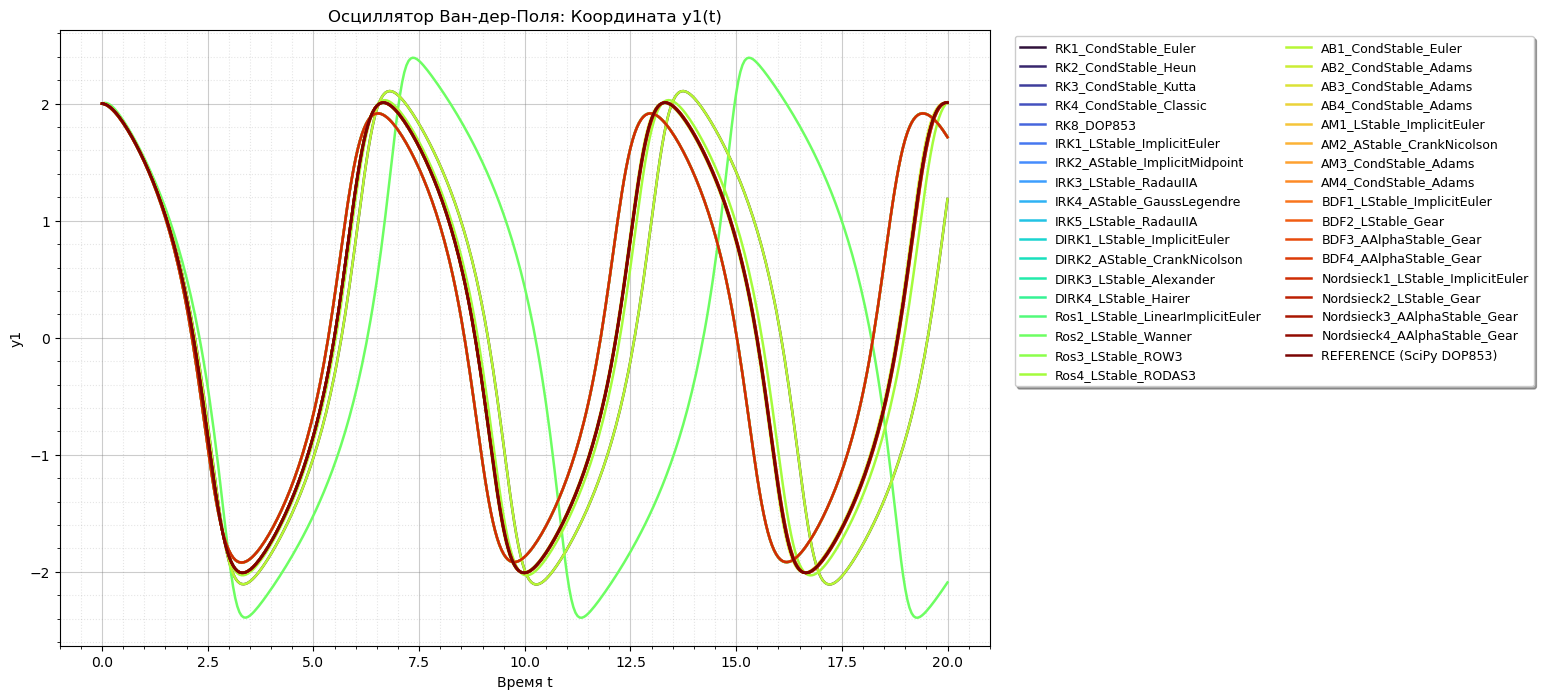

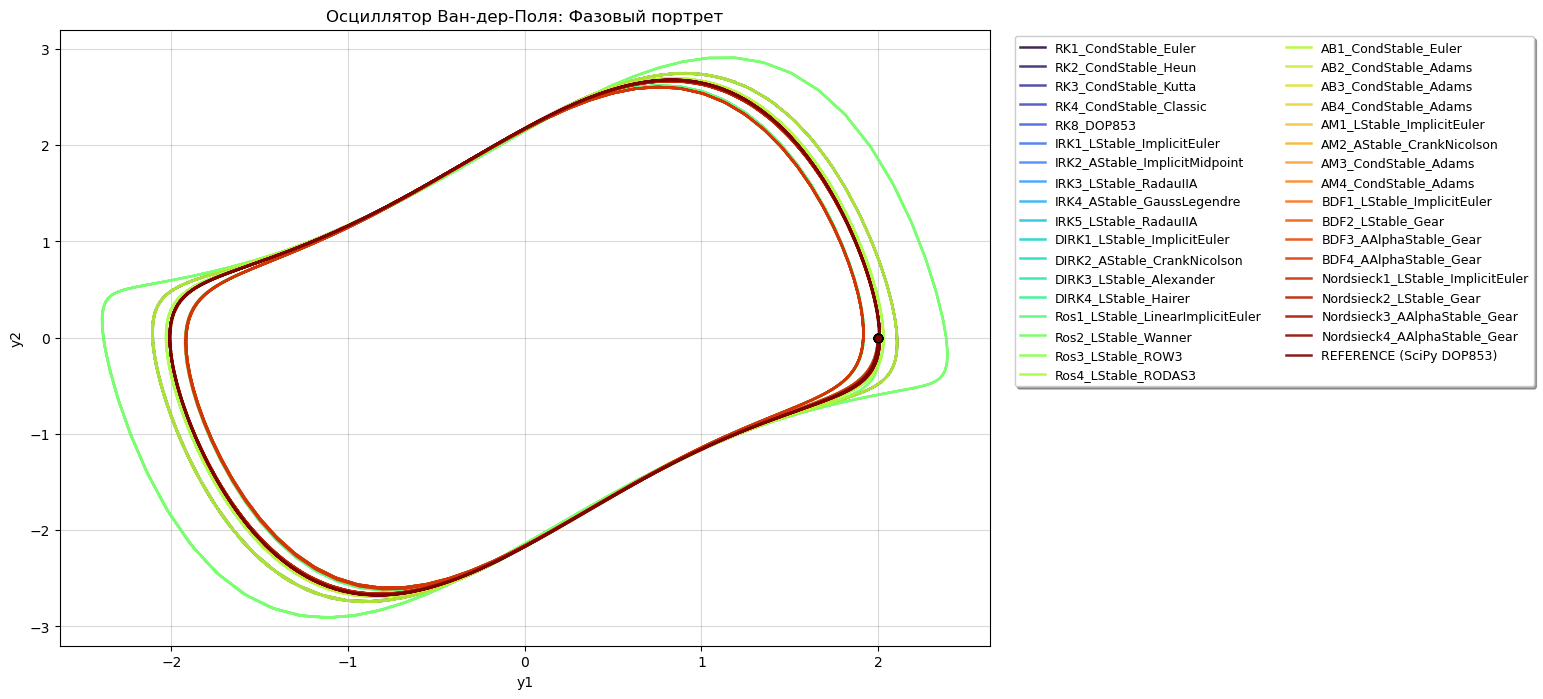

In [65]:
# 1. Базовый прогон (h=0.05)
run_base_comparison(vdp_problem, h=0.05)


--- Исследование сходимости: Осциллятор Ван-дер-Поля ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    2.8s remaining:    2.5s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    3.7s remaining:    1.3s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:    4.6s remaining:    0.2s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:    5.5s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    1.3s remaining:    1.1s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    2.0s remaining:    0.6s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:    2.4s remaining:    0.1s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:    2.7s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    0.6s remaining:    0.6s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    0.9

[Ros2_LStable_Wanner] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged


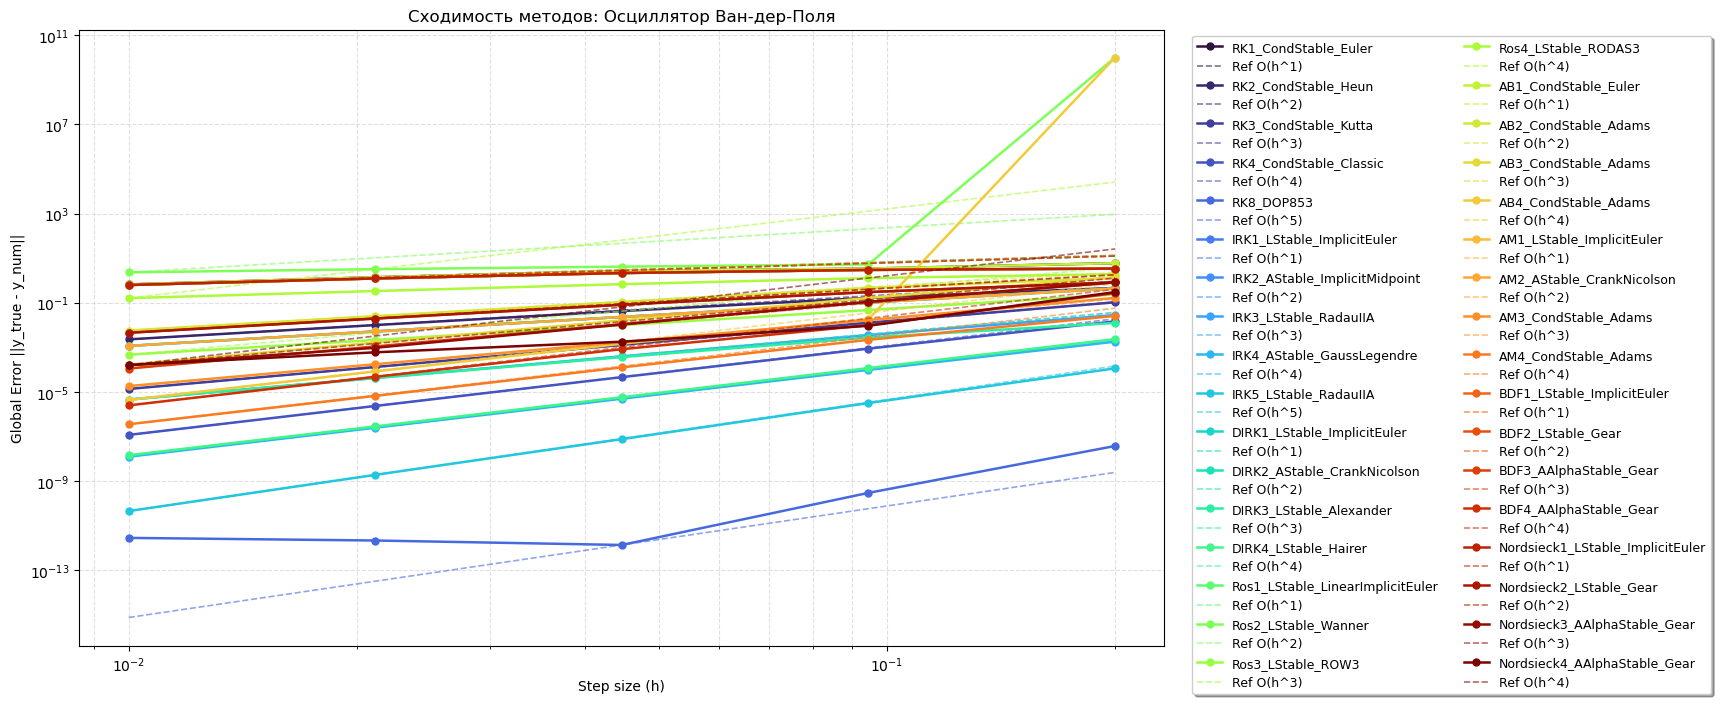

In [69]:
# 2. Сходимость O(h^p)
# На сходимости берем интервал короче, чтобы избежать эффекта накопления фазового сдвига

run_convergence_study(vdp_problem, h_values=np.logspace(np.log10(0.01), np.log10(0.2), 5))


--- Перебор параметра 'e' для метода RK8_DOP853: Осциллятор Ван-дер-Поля ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  20 | elapsed:    1.3s remaining:   12.1s
[Parallel(n_jobs=12)]: Done   7 out of  20 | elapsed:    1.4s remaining:    2.7s
[Parallel(n_jobs=12)]: Done  12 out of  20 | elapsed:    2.1s remaining:    1.4s
[Parallel(n_jobs=12)]: Done  17 out of  20 | elapsed:    2.8s remaining:    0.4s
[Parallel(n_jobs=12)]: Done  20 out of  20 | elapsed:    2.9s finished


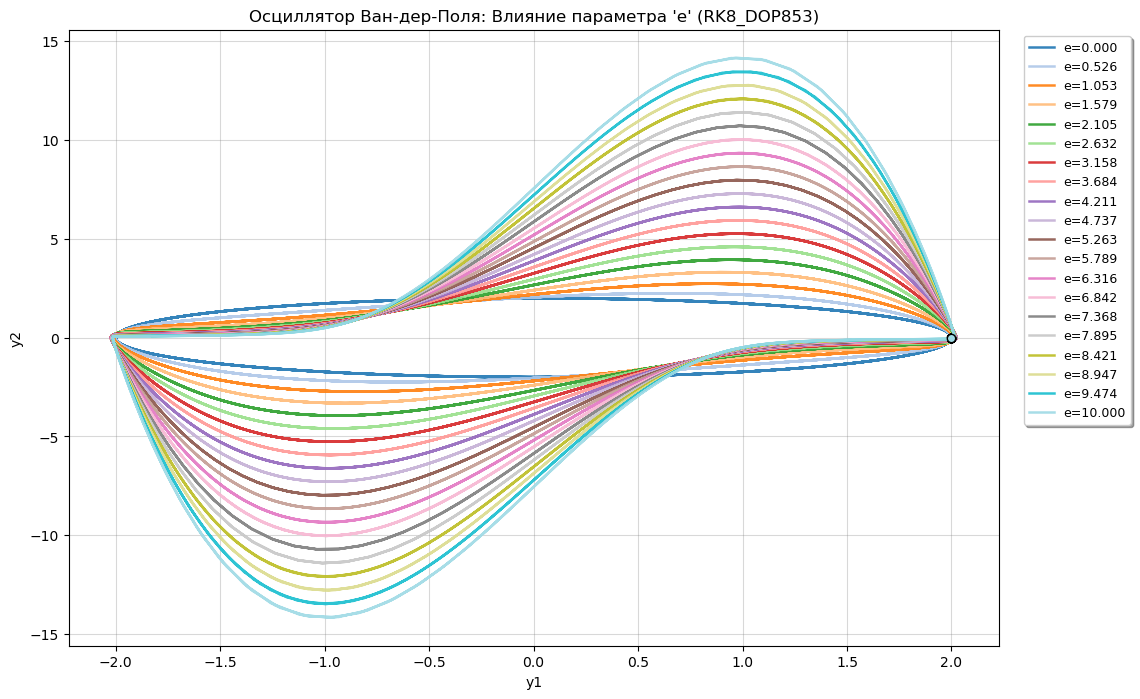

In [123]:
# 3. Варьирование параметра нелинейности 'e' (сформирует 3 фазовых портрета)
run_parameter_sweep_single_method(
    problem=vdp_problem, 
    method_name="RK8_DOP853",
    param_name='e', 
    param_values=np.linspace(0, 10, 20), 
    h=0.01
)

# 2. Уравнение Бонгоффера–Ван-дер-Поля (Жесткая задача)

### 2.1 Постановка физической задачи
Система уравнений Бонгоффера–Ван-дер-Поля (в биофизике известная как **модель Фицхью — Нагумо**) является базовой физиологической моделью возбудимости клеточных мембран (нейронов и клеток миокарда).

Физический смысл переменных:
* **$y_1$ (мембранный потенциал):** Описывает напряжение на мембране клетки. Кубическая нелинейность моделирует быстрый автокаталитический входящий ток ионов натрия, который вызывает резкий всплеск потенциала (спайк или потенциал действия).
* **$y_2$ (переменная восстановления):** Описывает более медленные процессы реполяризации, такие как открытие калиевых каналов, возвращающих систему в состояние покоя.

Наличие большого параметра $a = 10^3$ (или $10^6$) физически отражает **разделение временных масштабов**. Процесс деполяризации (скачок $y_1$) происходит в тысячи раз быстрее, чем процесс восстановления ($y_2$). Именно это многомасштабное поведение является физической причиной возникновения математической жесткости.

### 2.2 Постановка математической задачи
Система описывается двумя ОДУ первого порядка:
$$
\begin{cases}
y_1' = a \left( y_1 - \frac{y_1^3}{3} + y_2 \right) \\
y_2' = -y_1 - b y_2 + c
\end{cases}
$$

**Якобиан системы** $J = \frac{\partial \mathbf{f}}{\partial \mathbf{y}}$:
$$
J = \begin{pmatrix}
a(1 - y_1^2) & a \\
-1 & -b
\end{pmatrix}
$$
Система автономна, поэтому $\frac{\partial \mathbf{f}}{\partial t} = \mathbf{0}$.

**Оценка жесткости:**
Рассмотрим матрицу Якоби в начальной точке $\mathbf{y}(0) = (2, 0)^T$ при параметрах $a = 10^3, b = 0.2$:
$$
J = \begin{pmatrix}
-3000 & 1000 \\
-1 & -0.2
\end{pmatrix}
$$
След матрицы $\text{Tr}(J) = -3000.2$, определитель $\det(J) = 1600$.
Собственные значения $\lambda_{1,2}$ находим из характеристического уравнения:
$$\lambda_1 \approx -3000, \quad \lambda_2 \approx -0.533$$
Отношение наибольшего по модулю собственного значения к наименьшему (число жесткости или stiffness ratio) составляет **$S \approx 5.6 \times 10^3$**.
Для устойчивости любого явного метода необходимо, чтобы шаг интегрирования лежал в области абсолютной устойчивости, грубо $|h \lambda_{max}| < 2$. Отсюда ограничение на шаг для явных схем: **$h < \frac{2}{3000} \approx 0.0006$**. 

Мы намеренно выберем шаг $h = 0.01$, при котором **все явные методы гарантированно разойдутся**. Неявные L-устойчивые методы, напротив, смогут успешно проинтегрировать систему.

**Начальные условия и параметры интегрирования:**
* Интервал: $t \in [0, 5]$
* Вектор начальных условий: $y_1(0) = 2.0, \quad y_2(0) = 0.0$
* Параметры: $a = 10^3$, $b = 0.2$, ток $c \in (0, 1)$

In [70]:
def fhn_rhs(t: float, y_vec: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    y1, y2 = y_vec[0], y_vec[1]
    return np.array([
        a * (y1 - (y1**3) / 3.0 + y2),
        -y1 - b * y2 + c
    ], dtype=np.float64)

def fhn_jac(t: float, y_vec: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    y1, y2 = y_vec[0], y_vec[1]
    return np.array([
        [a * (1.0 - y1**2), a],
        [-1.0, -b]
    ], dtype=np.float64)

def fhn_dfdt(t: float, y_vec: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    return np.zeros_like(y_vec, dtype=np.float64)

fhn_problem = ODEProblem(
    name="Фицхью-Нагумо",
    rhs=fhn_rhs,
    jac=fhn_jac,
    dfdt=fhn_dfdt,
    t_span=(0.0, 5.0),
    y0=np.array([2.0, 0.0], dtype=np.float64),
    params={'a': 1000.0, 'b': 0.2, 'c': 0.2},
    ref_method='Radau'  # Жесткая задача -> используем жесткий метод для эталона
)



--- Базовое сравнение: Фицхью-Нагумо (h = 0.0005) ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:   13.2s remaining:   11.7s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:   18.0s remaining:    6.4s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:   21.9s remaining:    1.3s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:   27.5s finished


[Ros2_LStable_Wanner] Ошибка: Diverged
[AB3_CondStable_Adams] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged


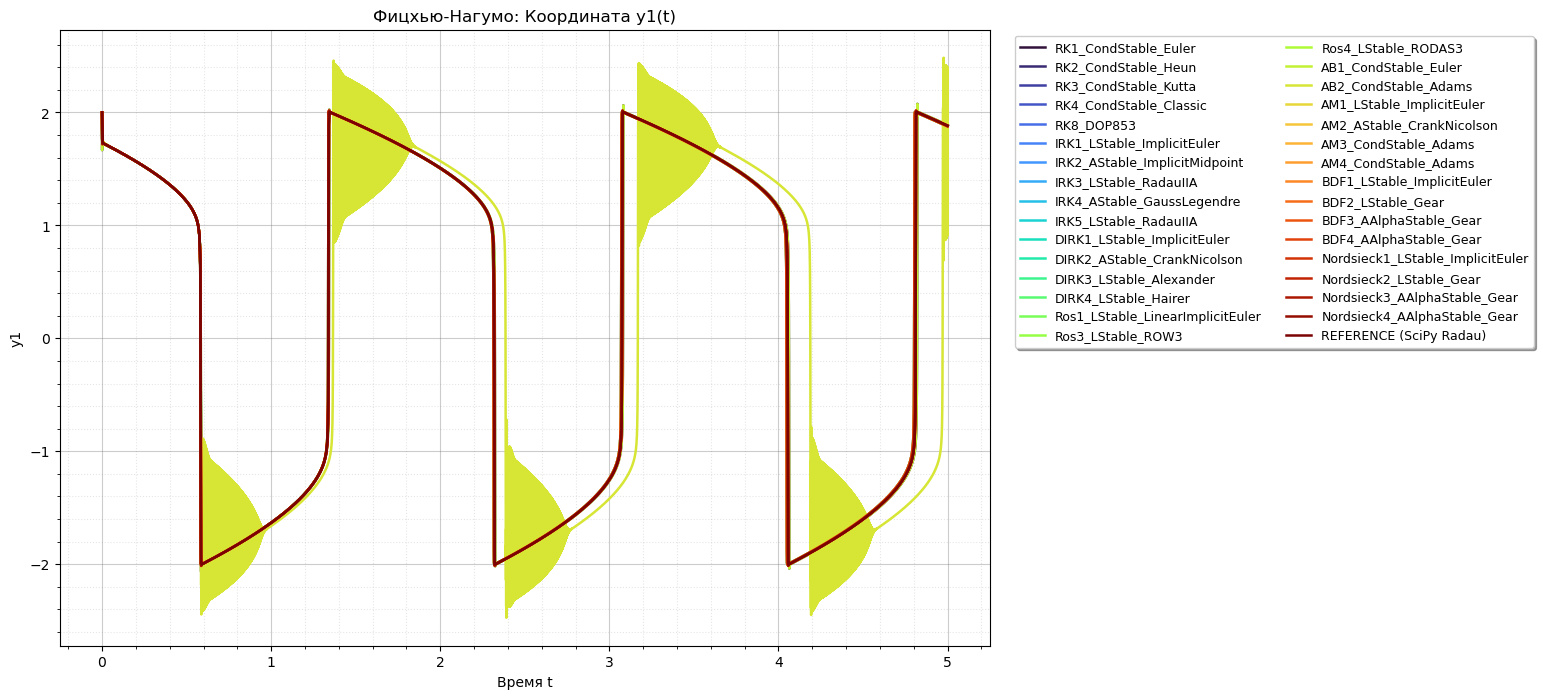

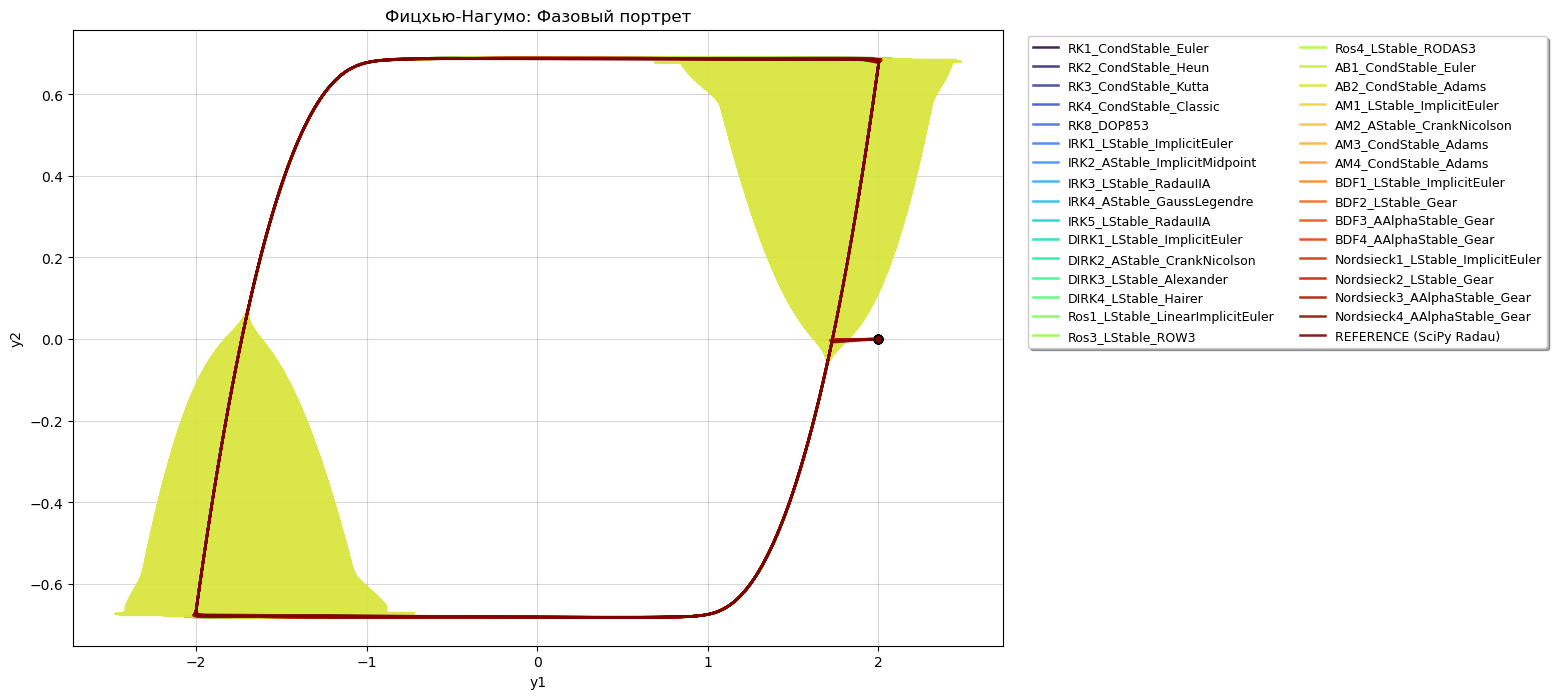

In [ ]:
# 1. Базовый прогон: h=0.001
# Мы ожидаем, что явные методы развалятся (в консоли будут сообщения "Diverged")

run_base_comparison(fhn_problem, h=0.0005) 


--- Исследование сходимости: Фицхью-Нагумо ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:   12.1s remaining:   10.7s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:   17.0s remaining:    6.1s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:   21.7s remaining:    1.3s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:   26.6s finished


[Ros2_LStable_Wanner] Ошибка: Diverged
[AB3_CondStable_Adams] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    3.7s remaining:    3.3s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    6.0s remaining:    2.1s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:    6.9s remaining:    0.3s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:    9.1s finished


[RK1_CondStable_Euler] Ошибка: Diverged
[RK2_CondStable_Heun] Ошибка: Diverged
[RK3_CondStable_Kutta] Ошибка: Diverged
[Ros2_LStable_Wanner] Ошибка: Diverged
[Ros3_LStable_ROW3] Ошибка: Diverged
[AB1_CondStable_Euler] Ошибка: Diverged
[AB2_CondStable_Adams] Ошибка: Diverged
[AB3_CondStable_Adams] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged


...

[RK1_CondStable_Euler] Ошибка: Diverged
[RK2_CondStable_Heun] Ошибка: Diverged
[RK3_CondStable_Kutta] Ошибка: Diverged
[RK4_CondStable_Classic] Ошибка: Diverged
[RK8_DOP853] Ошибка: Diverged
[Ros2_LStable_Wanner] Ошибка: Diverged
[Ros3_LStable_ROW3] Ошибка: Diverged
[Ros4_LStable_RODAS3] Ошибка: Diverged
[AB1_CondStable_Euler] Ошибка: Diverged
[AB2_CondStable_Adams] Ошибка: Diverged
[AB3_CondStable_Adams] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged
[AM3_CondStable_Adams] Ошибка: Newton diverged (NaN/Inf) at iteration 3
[AM4_CondStable_Adams] Ошибка: Newton diverged (NaN/Inf) at iteration 3


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    1.0s remaining:    0.9s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    1.6s remaining:    0.5s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:    1.9s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:    2.6s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


[RK1_CondStable_Euler] Ошибка: Diverged
[RK2_CondStable_Heun] Ошибка: Diverged
[RK3_CondStable_Kutta] Ошибка: Diverged
[RK4_CondStable_Classic] Ошибка: Diverged
[RK8_DOP853] Ошибка: Diverged
[Ros2_LStable_Wanner] Ошибка: Diverged
[Ros3_LStable_ROW3] Ошибка: Diverged
[AB1_CondStable_Euler] Ошибка: Diverged
[AB2_CondStable_Adams] Ошибка: Diverged
[AB3_CondStable_Adams] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged
[AM3_CondStable_Adams] Ошибка: Diverged
[AM4_CondStable_Adams] Ошибка: Diverged


[Parallel(n_jobs=12)]: Done  18 out of  34 | elapsed:    0.6s remaining:    0.5s
[Parallel(n_jobs=12)]: Done  25 out of  34 | elapsed:    0.7s remaining:    0.2s
[Parallel(n_jobs=12)]: Done  32 out of  34 | elapsed:    0.9s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  34 out of  34 | elapsed:    1.0s finished


[RK1_CondStable_Euler] Ошибка: Diverged
[RK2_CondStable_Heun] Ошибка: Diverged
[RK3_CondStable_Kutta] Ошибка: Diverged
[RK4_CondStable_Classic] Ошибка: Diverged
[RK8_DOP853] Ошибка: Diverged
[Ros2_LStable_Wanner] Ошибка: Diverged
[Ros3_LStable_ROW3] Ошибка: Diverged
[AB1_CondStable_Euler] Ошибка: Diverged
[AB2_CondStable_Adams] Ошибка: Diverged
[AB3_CondStable_Adams] Ошибка: Diverged
[AB4_CondStable_Adams] Ошибка: Diverged
[AM4_CondStable_Adams] Ошибка: Diverged


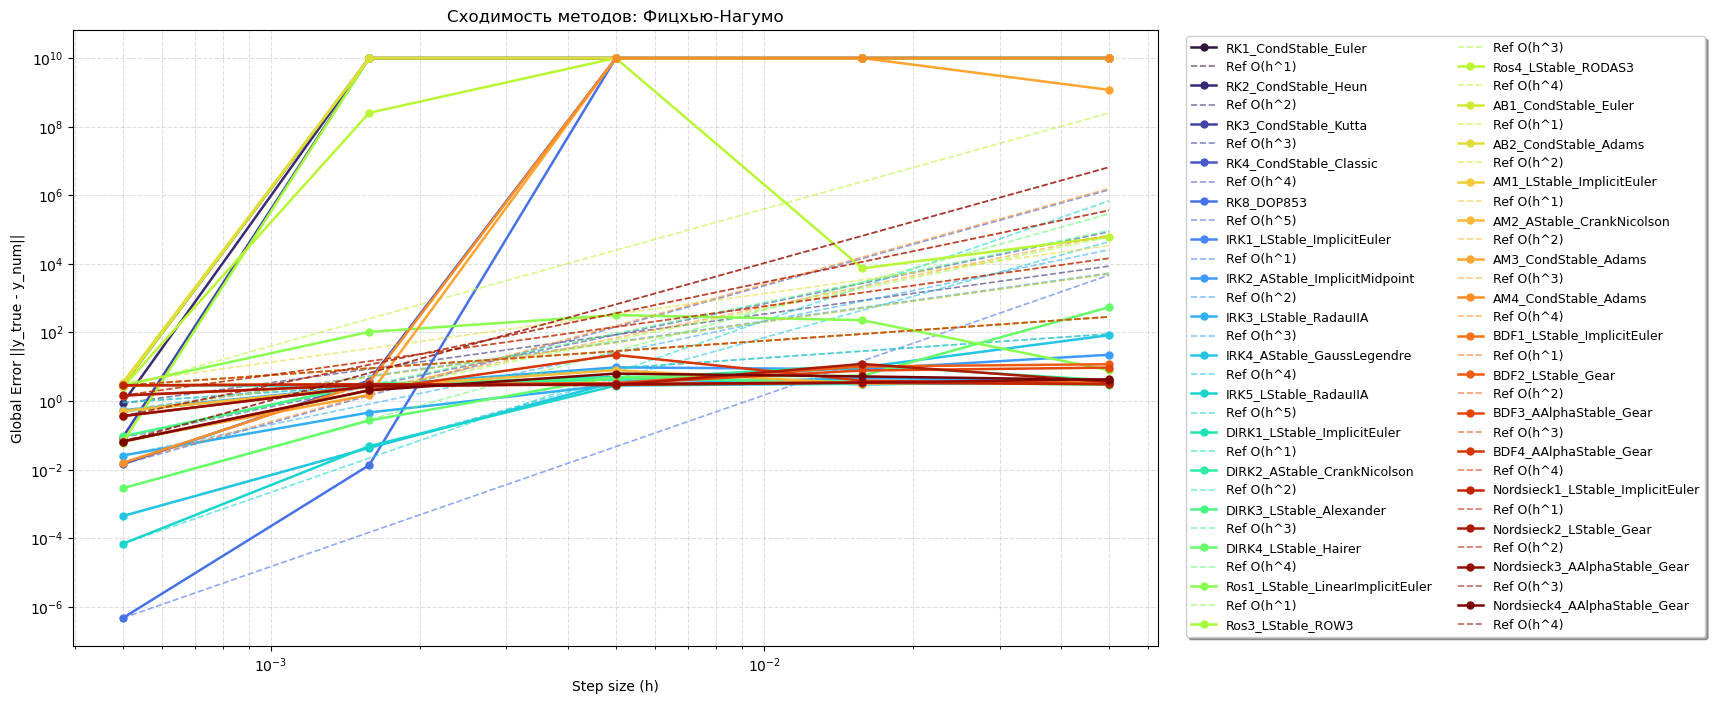

In [73]:
# 2. Сходимость

run_convergence_study(
    problem=fhn_problem, 
    h_values=np.logspace(np.log10(0.0005), np.log10(0.05), 5)
)


--- Перебор параметра 'c' для метода RK8_DOP853: Фицхью-Нагумо ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  20 | elapsed:    1.3s remaining:   12.7s
[Parallel(n_jobs=12)]: Done   7 out of  20 | elapsed:    1.5s remaining:    3.0s
[Parallel(n_jobs=12)]: Done  12 out of  20 | elapsed:    2.3s remaining:    1.5s
[Parallel(n_jobs=12)]: Done  17 out of  20 | elapsed:    2.8s remaining:    0.4s
[Parallel(n_jobs=12)]: Done  20 out of  20 | elapsed:    2.9s finished


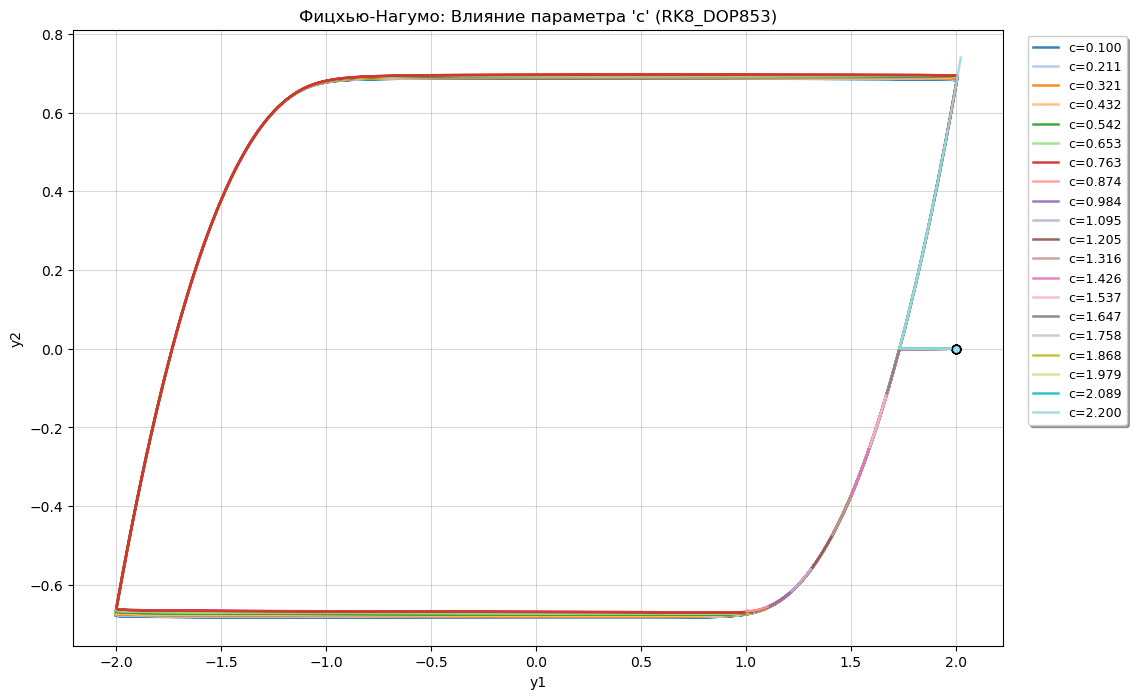

In [ ]:
# 3. Варьирование внешнего тока 'c'

run_parameter_sweep_single_method(
    problem=fhn_problem, 
    method_name="RK8_DOP853",
    param_name='c', 
    param_values=np.linspace(0.1, 2.2, 20), 
    h=0.001
)


--- Перебор параметра 'b' для метода RK8_DOP853: Фицхью-Нагумо ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  14 out of  30 | elapsed:    3.2s remaining:    3.6s
[Parallel(n_jobs=12)]: Done  21 out of  30 | elapsed:    3.6s remaining:    1.5s
[Parallel(n_jobs=12)]: Done  28 out of  30 | elapsed:    4.4s remaining:    0.2s
[Parallel(n_jobs=12)]: Done  30 out of  30 | elapsed:    4.5s finished


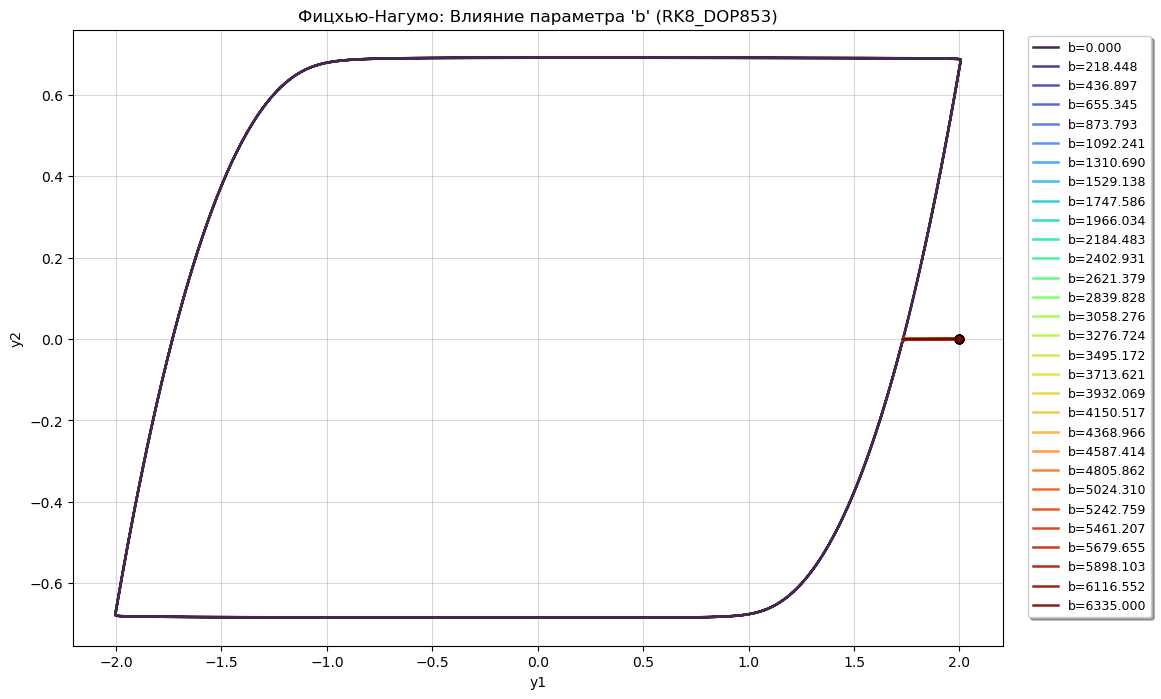

In [151]:
run_parameter_sweep_single_method(
    problem=fhn_problem, 
    method_name="RK8_DOP853",
    param_name='b', 
    param_values=np.linspace(0, 6335, 30),
    h=0.001
)


--- Перебор параметра 'a' для метода RK8_DOP853: Фицхью-Нагумо ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  14 out of  30 | elapsed:    2.6s remaining:    2.9s
[Parallel(n_jobs=12)]: Done  21 out of  30 | elapsed:    3.2s remaining:    1.3s
[Parallel(n_jobs=12)]: Done  28 out of  30 | elapsed:    3.7s remaining:    0.2s
[Parallel(n_jobs=12)]: Done  30 out of  30 | elapsed:    3.8s finished


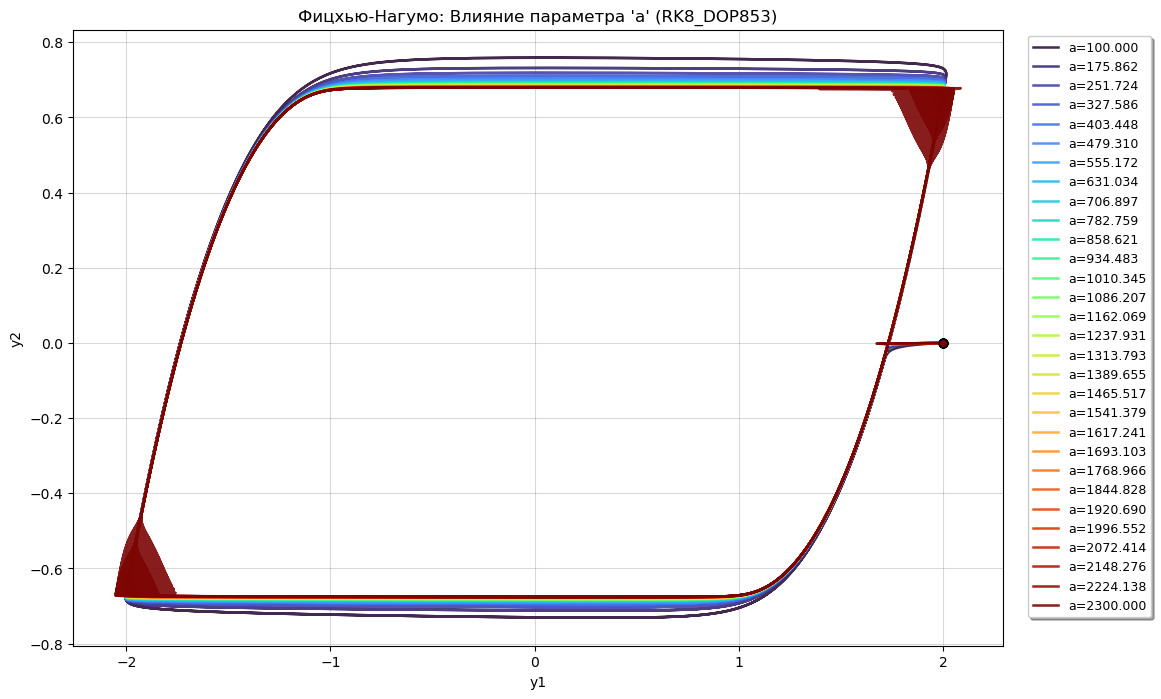

In [156]:
run_parameter_sweep_single_method(
    problem=fhn_problem, 
    method_name="RK8_DOP853",
    param_name='a', 
    param_values=np.linspace(100, 2300, 30),
    h=0.001
)

# 3. Орбита Аренсторфа (Ограниченная задача трех тел)

### 3.1 Постановка физической задачи
Орбита Аренсторфа — это частный случай плоской ограниченной круговой задачи трех тел. Физически она моделирует полет легкого космического аппарата (например, корабля "Аполлон") в гравитационном поле двух массивных тел, которые вращаются вокруг своего общего центра масс (Земли и Луны). 

"Ограниченность" задачи означает, что масса третьего тела (корабля) считается пренебрежимо малой и не влияет на движение Земли и Луны. Уравнения записываются во вращающейся системе координат, которая синхронизирована с вращением массивных тел (поэтому Земля и Луна покоятся на оси абсцисс). Эта задача знаменита своей колоссальной чувствительностью к начальным условиям и численным погрешностям: малейшая ошибка интегратора приводит к тому, что корабль либо врезается в Луну, либо улетает в открытый космос, разрушая замкнутую траекторию.

### 3.2 Постановка математической задачи
Пусть $\mu = 0.012277471$ — отношение массы Луны к суммарной массе системы, а $\hat{\mu} = 1 - \mu$ — безразмерная масса Земли. Вектор состояния $\mathbf{y} = (y_1, y_2, y_3, y_4)^T$, где $(y_1, y_2)$ — координаты корабля, $(y_3, y_4)$ — его скорости.

Система ОДУ имеет вид:
$$
\begin{cases}
y_1' = y_3 \\
y_2' = y_4 \\
y_3' = y_1 + 2y_4 - \hat{\mu}\frac{y_1 + \mu}{D_1} - \mu\frac{y_1 - \hat{\mu}}{D_2} \\
y_4' = y_2 - 2y_3 - \hat{\mu}\frac{y_2}{D_1} - \mu\frac{y_2}{D_2}
\end{cases}
$$
где кубы расстояний до центров масс вычисляются как:
$D_1 = \left((y_1 + \mu)^2 + y_2^2\right)^{3/2}$ (расстояние до Земли),
$D_2 = \left((y_1 - \hat{\mu})^2 + y_2^2\right)^{3/2}$ (расстояние до Луны).

**Якобиан системы** $J = \frac{\partial \mathbf{f}}{\partial \mathbf{y}}$:
Матрица $4 \times 4$, где большинство нелинейностей сосредоточено в нижнем левом блоке $2 \times 2$. Например:
$\frac{\partial y_3'}{\partial y_1} = 1 - \hat{\mu} \left( \frac{1}{D_1} - \frac{3(y_1+\mu)^2}{D_1^{5/3}} \right) - \mu \left( \frac{1}{D_2} - \frac{3(y_1-\hat{\mu})^2}{D_2^{5/3}} \right)$
*(Полная аналитическая форма якобиана громоздка, но математически строго реализована в программном коде).*
Частная производная $\frac{\partial \mathbf{f}}{\partial t} = \mathbf{0}$.

**Оценка жесткости:**
Задача **не является классически жесткой** в глобальном смысле (собственные значения лежат вблизи мнимой оси), однако она становится сингулярной в моменты тесных сближений с Луной или Землей (когда $D_1 \to 0$ или $D_2 \to 0$). Главная сложность здесь — требование экстремальной точности. Методы низких порядков (включая неявные) вносят сильную численную диссипацию энергии, из-за чего орбита быстро сжимается и искажается.

**Начальные условия (для точного замыкания орбиты):**
* Интервал (один полный период): $t \in [0, 17.06521656015796]$
* $y_1(0) = 0.994$, $y_2(0) = 0.0$
* $y_3(0) = 0.0$, $y_4(0) = -2.0015851063790825$

In [83]:
def arenstorf_rhs(t: float, y_vec: np.ndarray, mu: float) -> np.ndarray:
    y1, y2, y3, y4 = y_vec[0], y_vec[1], y_vec[2], y_vec[3]
    mu_hat = 1.0 - mu
    
    r1_sq = (y1 + mu)**2 + y2**2
    r2_sq = (y1 - mu_hat)**2 + y2**2
    d1 = r1_sq * np.sqrt(r1_sq)
    d2 = r2_sq * np.sqrt(r2_sq)
    
    dy1 = y3
    dy2 = y4
    dy3 = y1 + 2.0 * y4 - mu_hat * (y1 + mu) / d1 - mu * (y1 - mu_hat) / d2
    dy4 = y2 - 2.0 * y3 - mu_hat * y2 / d1 - mu * y2 / d2
    
    return np.array([dy1, dy2, dy3, dy4], dtype=np.float64)

def arenstorf_jac(t: float, y_vec: np.ndarray, mu: float) -> np.ndarray:
    y1, y2 = y_vec[0], y_vec[1]
    mu_hat = 1.0 - mu
    
    r1_sq = (y1 + mu)**2 + y2**2
    r2_sq = (y1 - mu_hat)**2 + y2**2
    d1 = r1_sq * np.sqrt(r1_sq)
    d2 = r2_sq * np.sqrt(r2_sq)
    r1_5 = r1_sq**2 * np.sqrt(r1_sq)
    r2_5 = r2_sq**2 * np.sqrt(r2_sq)
    
    dy3_dy1 = 1.0 - mu_hat * (1.0/d1 - 3.0*(y1 + mu)**2/r1_5) - mu * (1.0/d2 - 3.0*(y1 - mu_hat)**2/r2_5)
    dy3_dy2 = mu_hat * 3.0 * (y1 + mu) * y2 / r1_5 + mu * 3.0 * (y1 - mu_hat) * y2 / r2_5
    dy4_dy1 = dy3_dy2 
    dy4_dy2 = 1.0 - mu_hat * (1.0/d1 - 3.0*y2**2/r1_5) - mu * (1.0/d2 - 3.0*y2**2/r2_5)
    
    return np.array([
        [0.0,     0.0,     1.0,  0.0],
        [0.0,     0.0,     0.0,  1.0],
        [dy3_dy1, dy3_dy2, 0.0,  2.0],
        [dy4_dy1, dy4_dy2, -2.0, 0.0]
    ], dtype=np.float64)

def arenstorf_dfdt(t: float, y_vec: np.ndarray, mu: float) -> np.ndarray:
    return np.zeros_like(y_vec, dtype=np.float64)

arenstorf_problem = ODEProblem(
    name="Орбита Аренсторфа",
    rhs=arenstorf_rhs,
    jac=arenstorf_jac,
    dfdt=arenstorf_dfdt,
    t_span=(0.0, 17.06521656015796),
    y0=np.array([0.994, 0.0, 0.0, -2.0015851063790825], dtype=np.float64),
    params={'mu': 0.012277471},
    ref_method='DOP853',
    error_dims=slice(0, 2)  # Считаем ошибку ТОЛЬКО по координатам X и Y
)

In [84]:
# Период орбиты Аренсторфа
period = 17.06521656015796


--- Базовое сравнение: Орбита Аренсторфа (h = 0.1) ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:    0.2s remaining:    0.4s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:    0.6s finished


[DIRK4_LStable_Hairer] Пропущен: Траектория ушла в бесконечность
[BDF4_AAlphaStable_Gear] Пропущен: Траектория ушла в бесконечность


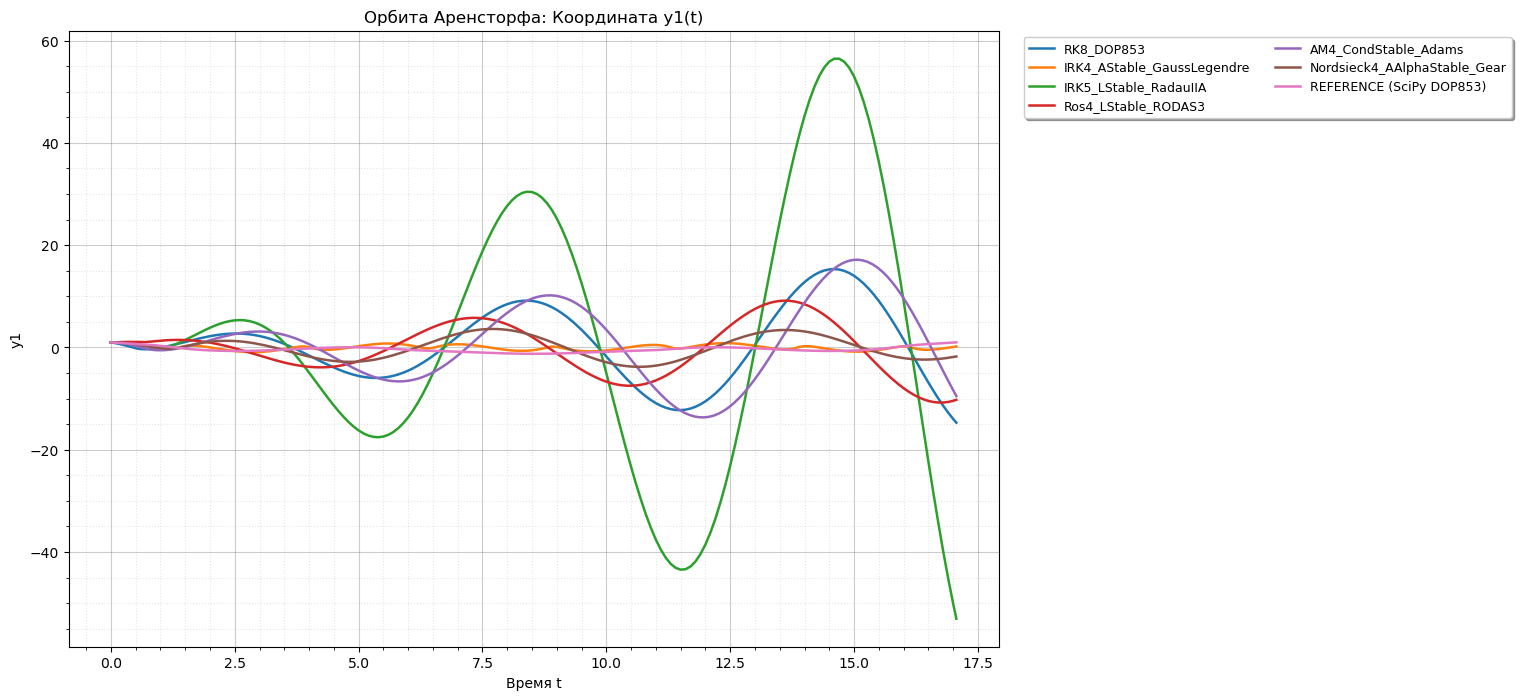

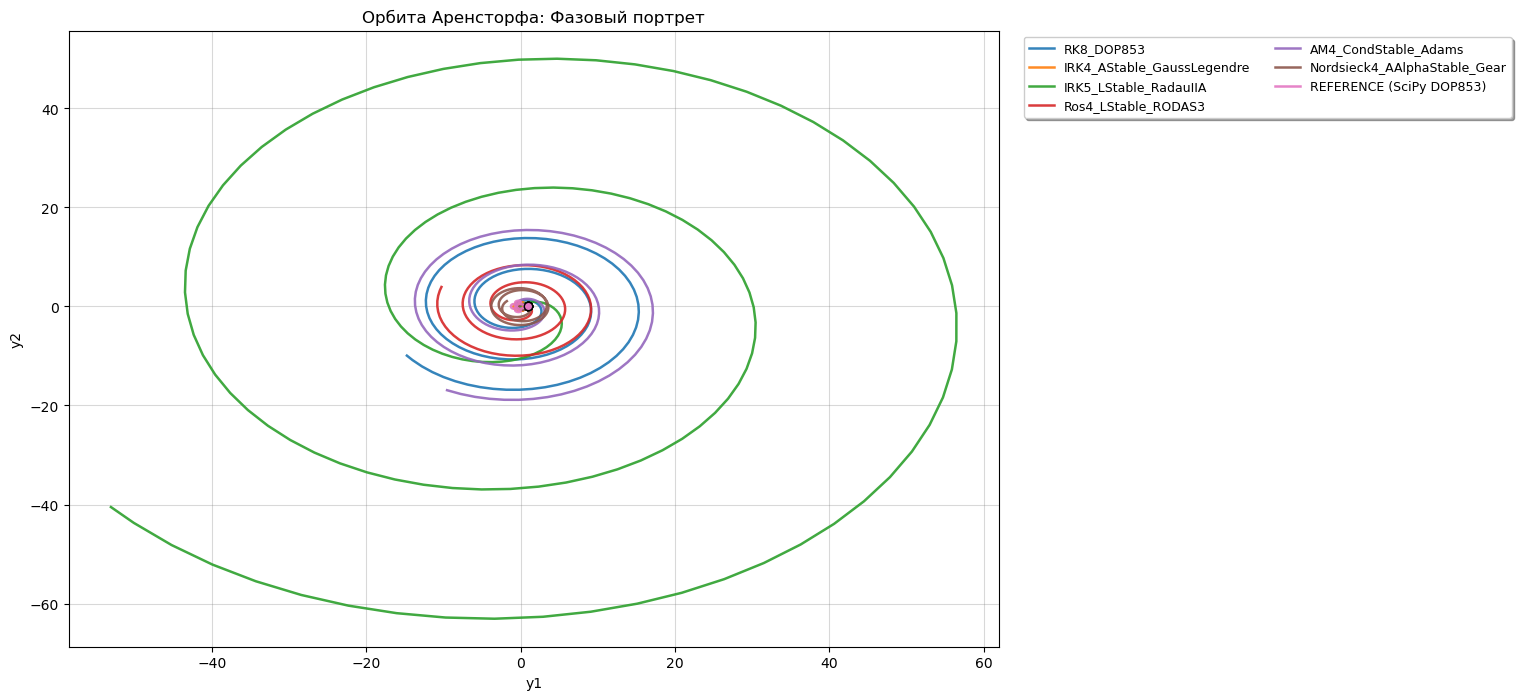


--- Базовое сравнение: Орбита Аренсторфа (h = 0.01) ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:    1.6s remaining:    2.7s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:    1.6s remaining:    0.9s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:    5.2s finished


[Ros4_LStable_RODAS3] Пропущен: Траектория ушла в бесконечность


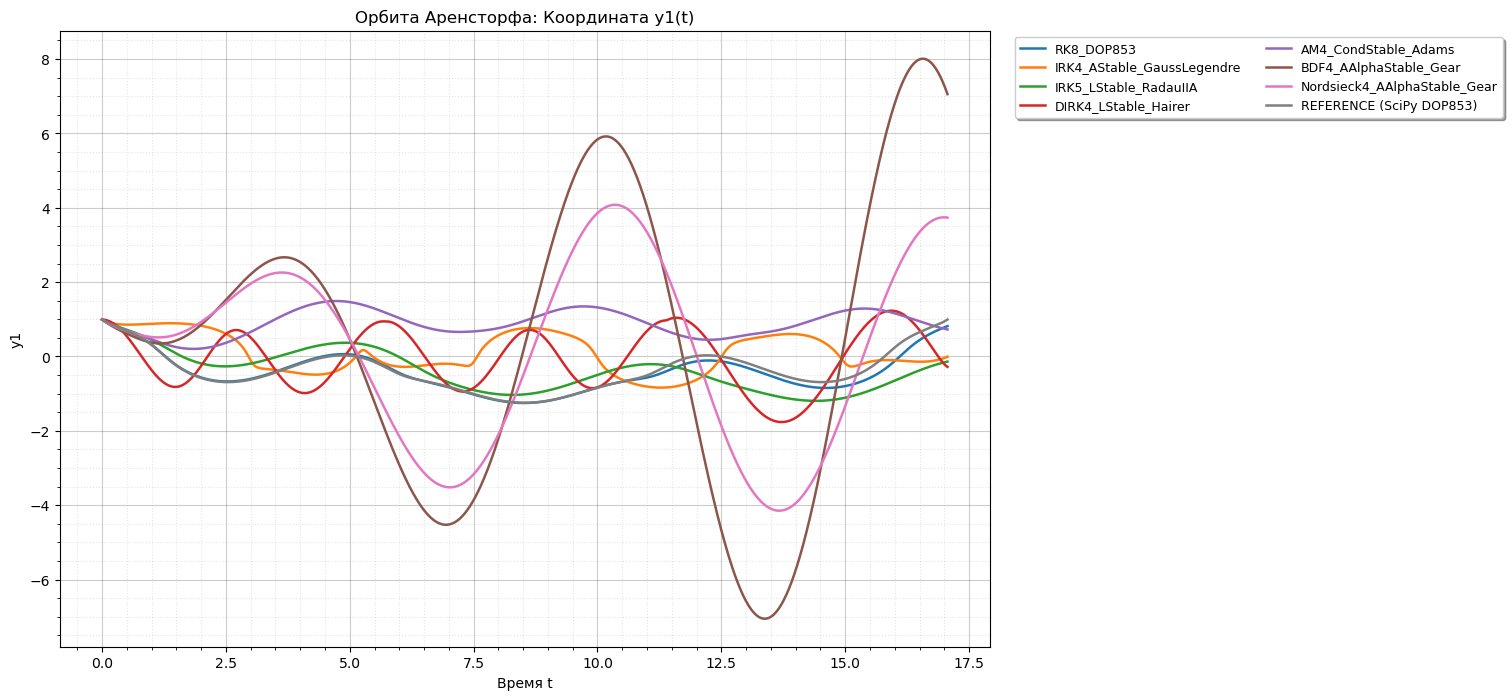

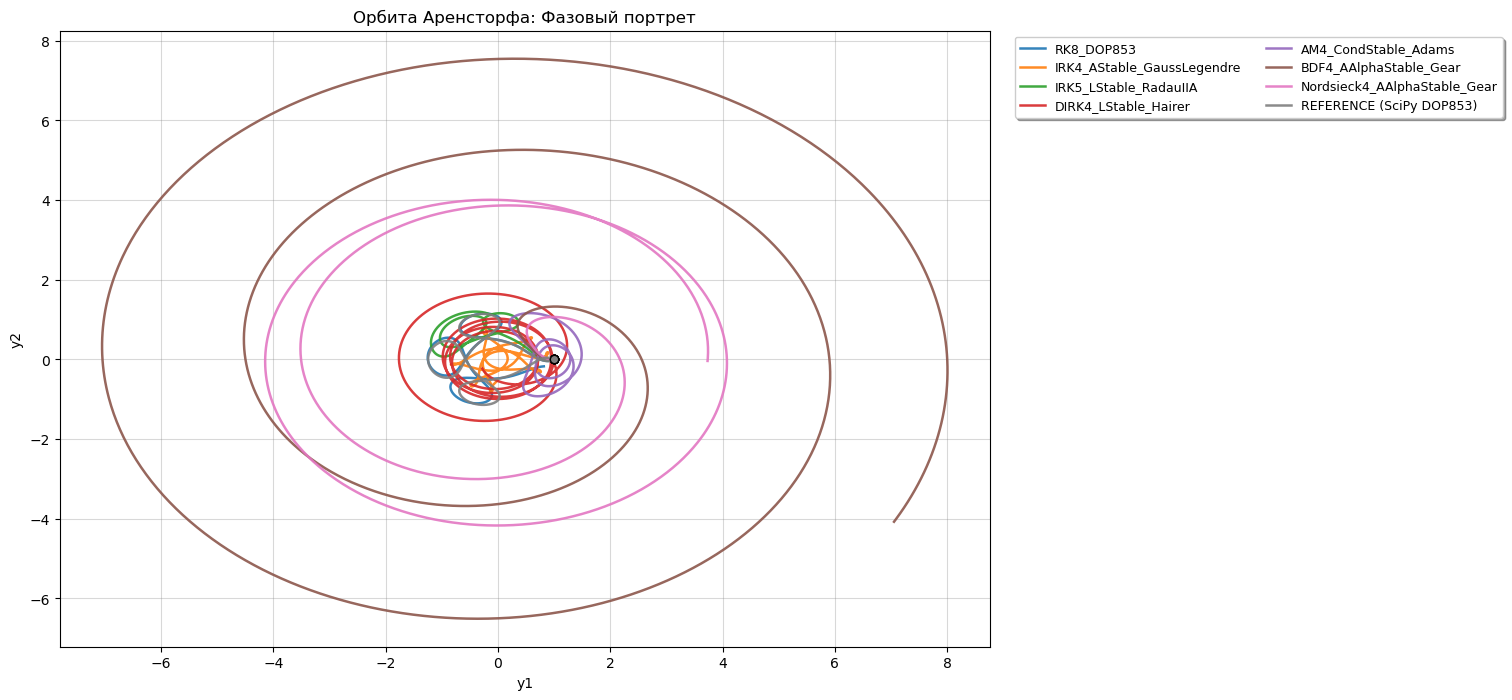

In [92]:
# 1. Базовый прогон (Один полный виток, h=0.0001)
for h_step in [0.1, 0.01]:
    arenstorf_problem.t_span = (0.0, period)
    run_base_comparison(arenstorf_problem, h=h_step)


--- Базовое сравнение: Орбита Аренсторфа (h = 0.0001) ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:  1.4min remaining:  2.4min
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:  2.0min remaining:  1.2min
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:  4.8min finished


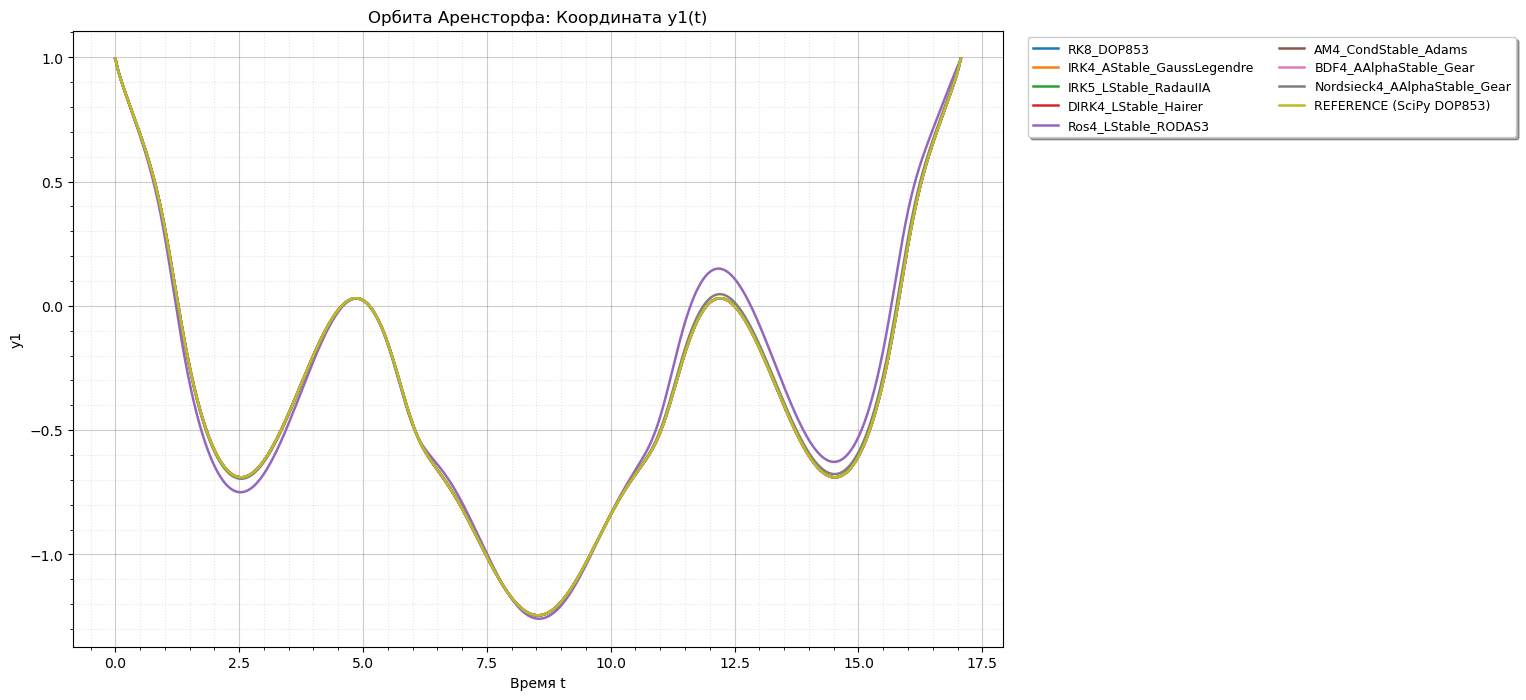

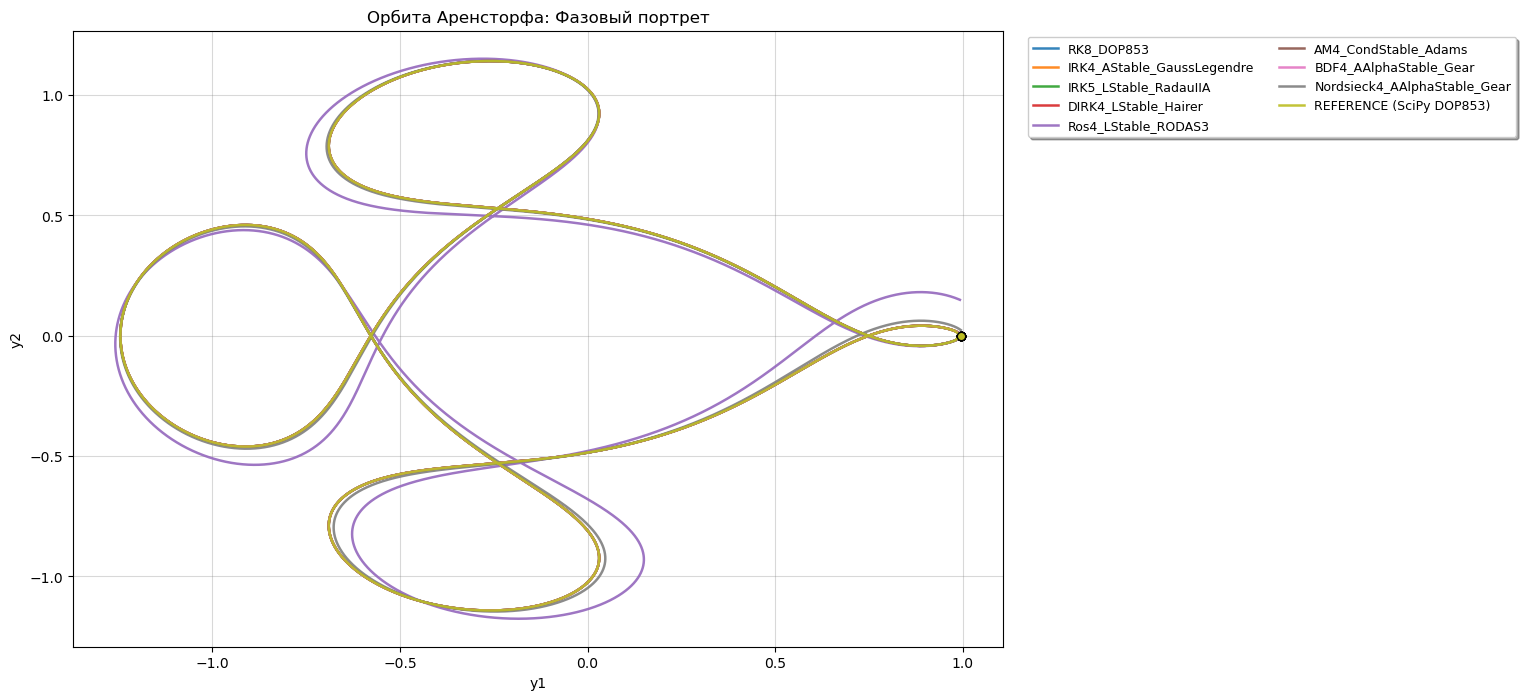

In [ ]:
# 1. Базовый прогон (Один полный виток, h=0.0001)
arenstorf_problem.t_span = (0.0, period)
run_base_comparison(arenstorf_problem, h=0.0001)


--- Исследование сходимости: Орбита Аренсторфа ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:   15.5s remaining:   25.9s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:   23.2s remaining:   13.9s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:  1.0min finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:    7.2s remaining:   12.1s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:   10.2s remaining:    6.1s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:   30.5s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:    3.7s remaining:    6.2s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:    5.4s remaining:    3.2s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:   16.5s finished
[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent wo

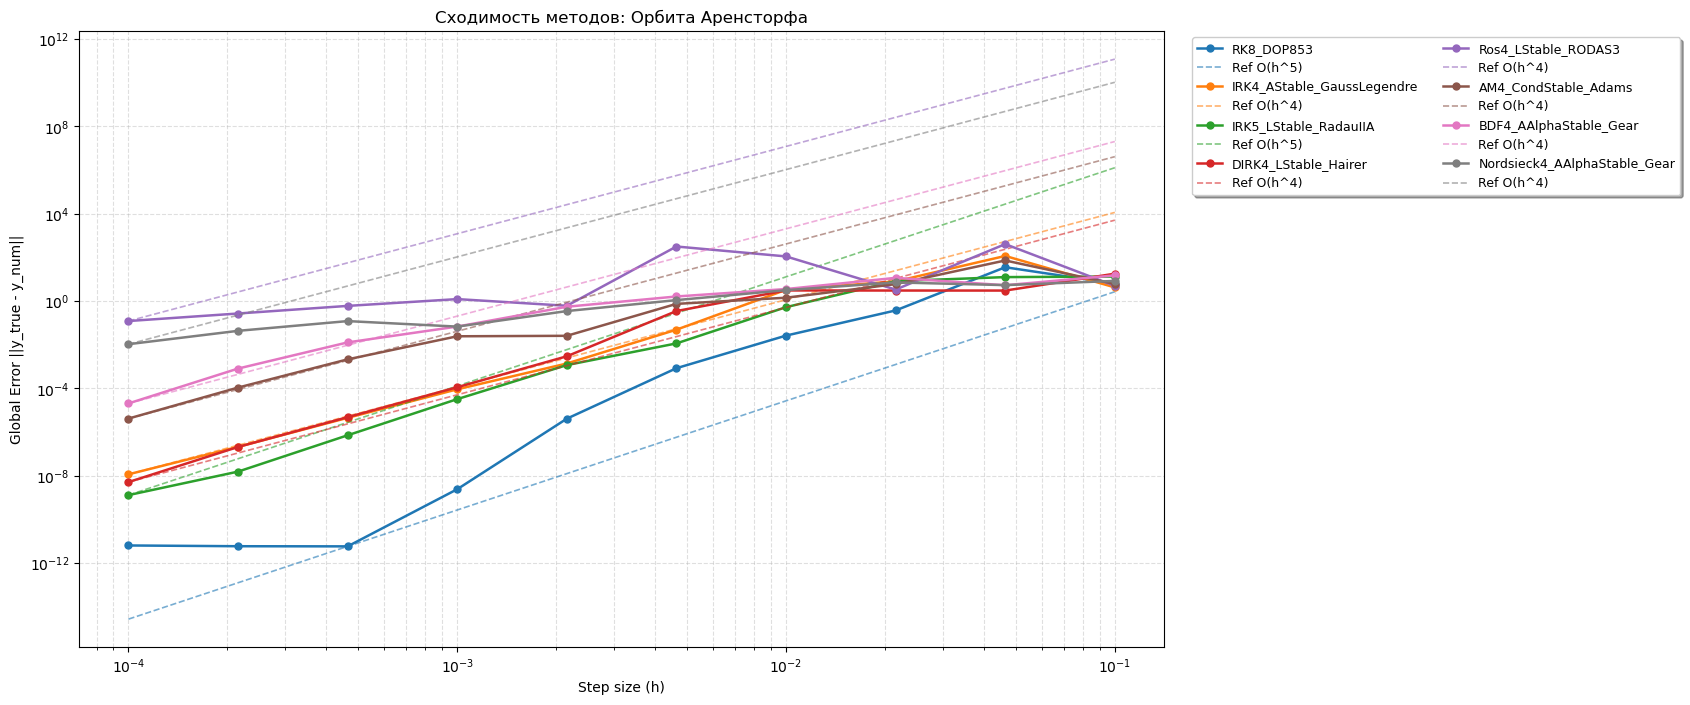

In [93]:
# 2. Сходимость

arenstorf_problem.t_span = (0.0, 3.0)
run_convergence_study(
    problem=arenstorf_problem,
    h_values=np.logspace(np.log10(0.0001), np.log10(0.1), 10)
)


--- Гравитационные возмущения (Варьирование массы Луны) ---

--- Перебор параметра 'mu' для метода RK8_DOP853: Орбита Аренсторфа ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  10 | elapsed:    1.2s remaining:    5.0s
[Parallel(n_jobs=12)]: Done   5 out of  10 | elapsed:    1.3s remaining:    1.3s
[Parallel(n_jobs=12)]: Done   8 out of  10 | elapsed:    1.4s remaining:    0.3s
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    1.4s finished


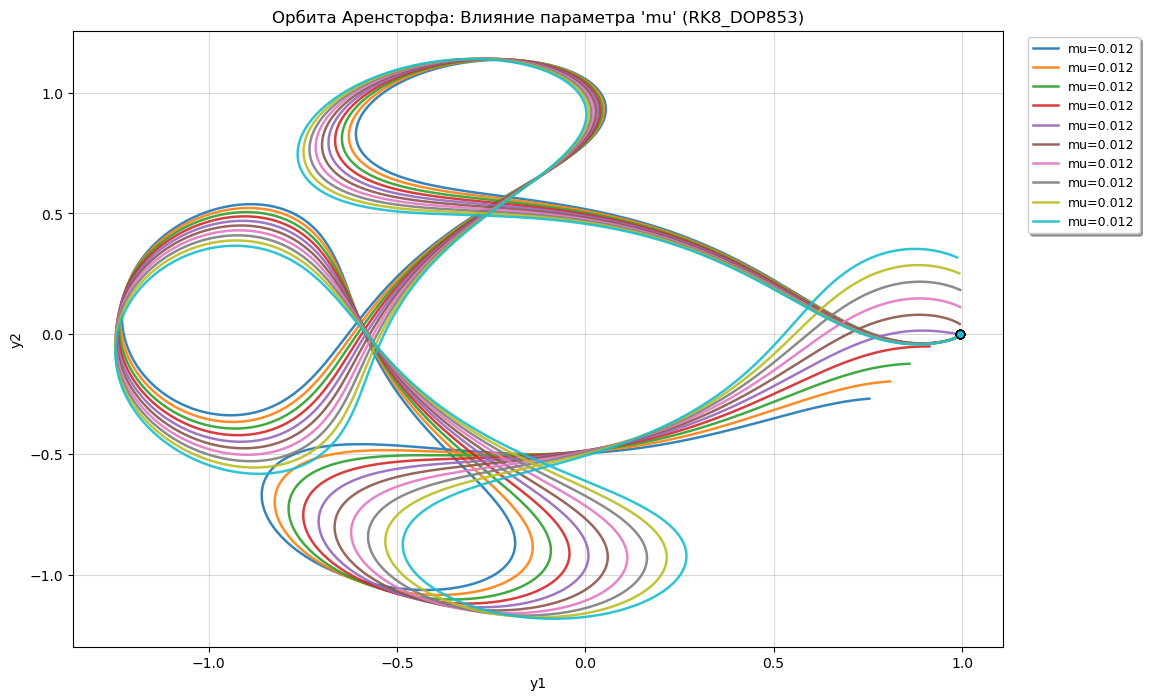

In [164]:
# 3. Изменение физики системы (Варьирование массы Луны, mu)
# Базовое mu = 0.012277. Проверим, что будет, если Луна станет чуть тяжелее или легче.
print("\n--- Гравитационные возмущения (Варьирование массы Луны) ---")
arenstorf_problem.t_span = (0.0, period)

mu_ref = 0.01227747
eps = 0.005

run_parameter_sweep_single_method(
    problem=arenstorf_problem, 
    method_name="RK8_DOP853",
    param_name='mu', 
    param_values=np.linspace(mu_ref - mu_ref * eps, mu_ref + mu_ref * eps, 10),
    h=0.005
)


--- Варьирование начальной скорости V_y ---

--- Перебор начальных условий y0[3] для метода RK8_DOP853: Орбита Аренсторфа ---


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  10 | elapsed:    1.2s remaining:    5.0s
[Parallel(n_jobs=12)]: Done   5 out of  10 | elapsed:    1.3s remaining:    1.3s
[Parallel(n_jobs=12)]: Done   8 out of  10 | elapsed:    1.4s remaining:    0.3s
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed:    1.4s finished


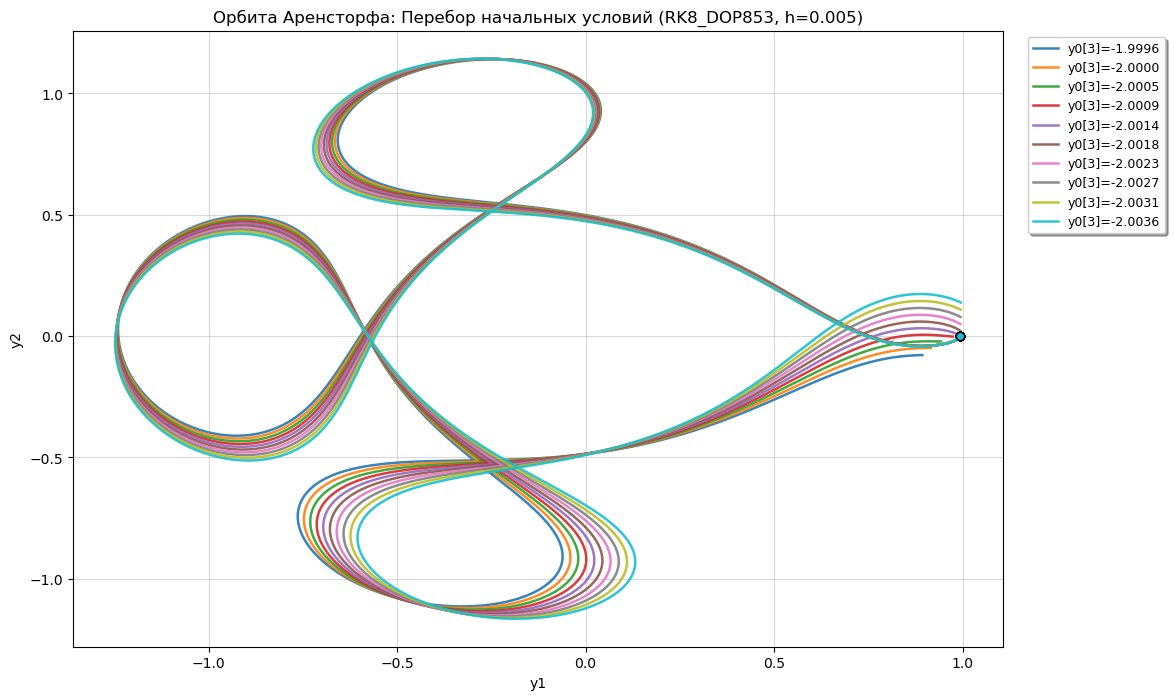

In [165]:
# 4. Чувствительность к начальным условиям
# Варьируем индекс 3 (начальная скорость по оси Y). 
# Базовая скорость: -2.001585. Добавим к ней сдвиги через linspace.
print("\n--- Варьирование начальной скорости V_y ---")
base_vy = arenstorf_problem.y0[3]

eps = 0.001

vy_values = base_vy + np.linspace(-base_vy * eps, base_vy * eps, 10)

run_initial_condition_sweep_single_method(
    problem=arenstorf_problem,
    method_name="RK8_DOP853",
    ic_index=3,            # Индекс скорости Y в векторе y0
    ic_values=vy_values,
    h=0.005
)